In [2]:
# ============================================================
# CELL 1 — ENVIRONMENT AND GPU CHECK
# ============================================================

import sys
import platform
import torch

print("=" * 70)
print("ENVIRONMENT CHECK")
print("=" * 70)

print(f"Python version : {sys.version}")
print(f"OS             : {platform.system()} {platform.release()}")
print(f"PyTorch        : {torch.__version__}")

# ------------------------------------------------------------
# GPU CHECK
# ------------------------------------------------------------

GPU_AVAILABLE = torch.cuda.is_available()

print("\n" + "=" * 70)
print("GPU CHECK")
print("=" * 70)

if GPU_AVAILABLE:
    DEVICE = torch.device("cuda")

    print("✓ CUDA GPU detected!")
    print(f"GPU name       : {torch.cuda.get_device_name(0)}")
    print(f"CUDA available : {torch.version.cuda}")
    print(f"GPU count      : {torch.cuda.device_count()}")

    # GPU memory
    total_memory = torch.cuda.get_device_properties(0).total_memory
    total_memory_gb = total_memory / (1024 ** 3)

    print(f"GPU memory     : {total_memory_gb:.2f} GB")

    # Reset CUDA memory statistics
    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()

else:
    DEVICE = torch.device("cpu")

    print("⚠ CUDA GPU was NOT detected.")
    print("The notebook will use CPU.")
    print("If you have an NVIDIA GPU, we can fix the CUDA/PyTorch setup.")

print("\n" + "=" * 70)
print("SELECTED DEVICE")
print("=" * 70)

print(f"DEVICE = {DEVICE}")

ENVIRONMENT CHECK
Python version : 3.14.6 (tags/v3.14.6:c63aec6, Jun 10 2026, 10:26:10) [MSC v.1944 64 bit (AMD64)]
OS             : Windows 11
PyTorch        : 2.13.0+cu132

GPU CHECK
✓ CUDA GPU detected!
GPU name       : NVIDIA GeForce RTX 4050 Laptop GPU
CUDA available : 13.2
GPU count      : 1
GPU memory     : 6.00 GB

SELECTED DEVICE
DEVICE = cuda


In [3]:
# ============================================================
# CELL 2 — AUTOMATIC DATASET DISCOVERY
# ============================================================

from pathlib import Path
from collections import Counter
import pandas as pd
import numpy as np
from PIL import Image

# ------------------------------------------------------------
# DATASET LOCATION
# ------------------------------------------------------------

DATASET_ROOT = Path(r"C:\Users\cscpr\Downloads\random 1")

print("=" * 70)
print("DATASET DISCOVERY")
print("=" * 70)

print(f"\nSearching inside:")
print(DATASET_ROOT)

# ------------------------------------------------------------
# CHECK PATH
# ------------------------------------------------------------

if not DATASET_ROOT.exists():
    raise FileNotFoundError(
        f"\nDataset path was not found:\n{DATASET_ROOT}"
    )

if not DATASET_ROOT.is_dir():
    raise NotADirectoryError(
        f"\nThe specified path is not a folder:\n{DATASET_ROOT}"
    )

print("\n✓ Dataset root exists.")

# ------------------------------------------------------------
# IMAGE EXTENSIONS
# ------------------------------------------------------------

IMAGE_EXTENSIONS = {
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".tif",
    ".tiff",
    ".webp"
}

# ------------------------------------------------------------
# FIND ALL IMAGES
# ------------------------------------------------------------

print("\nSearching recursively for image files...")

all_image_files = []

for path in DATASET_ROOT.rglob("*"):
    if path.is_file() and path.suffix.lower() in IMAGE_EXTENSIONS:
        all_image_files.append(path)

all_image_files = sorted(all_image_files)

print(f"✓ Images found: {len(all_image_files):,}")

# ------------------------------------------------------------
# SHOW TOP-LEVEL CONTENTS
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("TOP-LEVEL CONTENTS")
print("=" * 70)

top_level_items = sorted(
    DATASET_ROOT.iterdir(),
    key=lambda x: x.name.lower()
)

for item in top_level_items:

    if item.is_dir():
        print(f"[FOLDER] {item.name}")

    else:
        size_mb = item.stat().st_size / (1024 * 1024)
        print(f"[FILE]   {item.name} ({size_mb:.2f} MB)")

# ------------------------------------------------------------
# FIND DIRECT IMAGE-CONTAINING FOLDERS
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("SEARCHING FOR CLASS FOLDERS")
print("=" * 70)

class_directories = []

for directory in DATASET_ROOT.rglob("*"):

    if not directory.is_dir():
        continue

    direct_images = [
        file
        for file in directory.iterdir()
        if file.is_file()
        and file.suffix.lower() in IMAGE_EXTENSIONS
    ]

    if len(direct_images) > 0:
        class_directories.append(directory)

class_directories = sorted(
    class_directories,
    key=lambda x: str(x).lower()
)

print(
    f"\n✓ Folders containing images: "
    f"{len(class_directories)}"
)

# ------------------------------------------------------------
# DISPLAY CLASS FOLDERS
# ------------------------------------------------------------

for i, class_dir in enumerate(class_directories, start=1):

    image_count = sum(
        1
        for file in class_dir.iterdir()
        if file.is_file()
        and file.suffix.lower() in IMAGE_EXTENSIONS
    )

    print(
        f"{i:3d}. "
        f"{class_dir.name:<50} "
        f"{image_count:>7,} images"
    )

# ------------------------------------------------------------
# BUILD DATAFRAME
# ------------------------------------------------------------

records = []

for class_dir in class_directories:

    image_files = [
        file
        for file in class_dir.iterdir()
        if file.is_file()
        and file.suffix.lower() in IMAGE_EXTENSIONS
    ]

    for image_file in image_files:

        records.append({
            "image_path": str(image_file),
            "class_name": class_dir.name,
            "class_directory": str(class_dir)
        })

dataset_df = pd.DataFrame(records)

# ------------------------------------------------------------
# DATASET SUMMARY
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("DATASET SUMMARY")
print("=" * 70)

print(f"\nTotal images : {len(dataset_df):,}")
print(f"Total classes: {dataset_df['class_name'].nunique()}")

print("\nImages per class:")

class_counts = (
    dataset_df["class_name"]
    .value_counts()
    .sort_index()
)

display(
    class_counts
    .rename("image_count")
    .to_frame()
)

# ------------------------------------------------------------
# CHECK DUPLICATE FILE PATHS
# ------------------------------------------------------------

duplicate_paths = dataset_df["image_path"].duplicated().sum()

print("\nDuplicate file paths:", duplicate_paths)

# ------------------------------------------------------------
# CHECK IMAGE INTEGRITY
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("IMAGE INTEGRITY CHECK")
print("=" * 70)

valid_count = 0
corrupted_files = []

for i, image_path in enumerate(dataset_df["image_path"]):

    try:

        with Image.open(image_path) as image:
            image.verify()

        valid_count += 1

    except Exception as error:

        corrupted_files.append({
            "image_path": image_path,
            "error": str(error)
        })

    if (i + 1) % 1000 == 0 or (i + 1) == len(dataset_df):

        print(
            f"Checked "
            f"{i + 1:,}/{len(dataset_df):,}",
            end="\r"
        )

print("\n")

print(f"Valid images     : {valid_count:,}")
print(f"Corrupted images : {len(corrupted_files):,}")

# ------------------------------------------------------------
# DISPLAY CORRUPTED FILES IF ANY
# ------------------------------------------------------------

if len(corrupted_files) > 0:

    print("\nCorrupted/unreadable images:")

    corrupted_df = pd.DataFrame(corrupted_files)

    display(corrupted_df.head(20))

else:

    corrupted_df = pd.DataFrame(
        columns=["image_path", "error"]
    )

    print("✓ No corrupted images detected.")

# ------------------------------------------------------------
# IMAGE DIMENSION SAMPLE
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("IMAGE DIMENSION CHECK")
print("=" * 70)

dimension_records = []

# Check at most 1000 images here.
# We will use transforms later for model input.

dimension_sample = dataset_df.sample(
    n=min(1000, len(dataset_df)),
    random_state=42
)

for image_path in dimension_sample["image_path"]:

    try:

        with Image.open(image_path) as image:

            width, height = image.size

            dimension_records.append({
                "width": width,
                "height": height,
                "mode": image.mode
            })

    except Exception:
        pass

dimension_df = pd.DataFrame(dimension_records)

if not dimension_df.empty:

    print(
        f"Dimensions inspected: "
        f"{len(dimension_df):,} images"
    )

    print("\nMost common dimensions:")

    dimension_counts = (
        dimension_df
        .groupby(["width", "height"])
        .size()
        .sort_values(ascending=False)
        .head(20)
    )

    display(
        dimension_counts
        .rename("count")
        .to_frame()
    )

    print("\nImage modes:")

    display(
        dimension_df["mode"]
        .value_counts()
        .rename("count")
        .to_frame()
    )

# ------------------------------------------------------------
# IMAGE EXTENSION DISTRIBUTION
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("IMAGE FORMAT DISTRIBUTION")
print("=" * 70)

extension_counts = (
    dataset_df["image_path"]
    .apply(lambda x: Path(x).suffix.lower())
    .value_counts()
)

display(
    extension_counts
    .rename("count")
    .to_frame()
)

# ------------------------------------------------------------
# SAVE DATAFRAME IN MEMORY
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("DATASET DISCOVERY COMPLETE")
print("=" * 70)

print("\nThe dataset dataframe is stored as:")
print("dataset_df")

print("\nImportant variables created:")
print("  DATASET_ROOT")
print("  dataset_df")
print("  class_directories")
print("  class_counts")
print("  corrupted_df")
print("  dimension_df")

print("\n✓ Ready for the next cell.")

DATASET DISCOVERY

Searching inside:
C:\Users\cscpr\Downloads\random 1

✓ Dataset root exists.

Searching recursively for image files...
✓ Images found: 162,916

TOP-LEVEL CONTENTS
[FILE]   code.ipynb (6.03 MB)
[FOLDER] plantvillage dataset
[FILE]   PlantVillage Dataset.zip (2087.96 MB)

SEARCHING FOR CLASS FOLDERS

✓ Folders containing images: 114
  1. Apple___Apple_scab                                     630 images
  2. Apple___Black_rot                                      621 images
  3. Apple___Cedar_apple_rust                               275 images
  4. Apple___healthy                                      1,645 images
  5. Blueberry___healthy                                  1,502 images
  6. Cherry_(including_sour)___healthy                      854 images
  7. Cherry_(including_sour)___Powdery_mildew             1,052 images
  8. Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot     513 images
  9. Corn_(maize)___Common_rust_                          1,192 images
 10. Corn_

,image_count
class_name,
Apple___Apple_scab,1890
Apple___Black_rot,1863
Apple___Cedar_apple_rust,825
Apple___healthy,4935
Blueberry___healthy,4506
Cherry_(including_sour)___Powdery_mildew,3156
Cherry_(including_sour)___healthy,2562
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot,1539
Corn_(maize)___Common_rust_,3576



Duplicate file paths: 0

IMAGE INTEGRITY CHECK
Checked 162,916/162,916

Valid images     : 162,916
Corrupted images : 0
✓ No corrupted images detected.

IMAGE DIMENSION CHECK
Dimensions inspected: 1,000 images

Most common dimensions:


,,count
width,height,
256,256,1000



Image modes:


,count
mode,
RGB,1000



IMAGE FORMAT DISTRIBUTION


,count
image_path,
.jpg,162912
.png,2
.jpeg,2



DATASET DISCOVERY COMPLETE

The dataset dataframe is stored as:
dataset_df

Important variables created:
  DATASET_ROOT
  dataset_df
  class_directories
  class_counts
  corrupted_df
  dimension_df

✓ Ready for the next cell.


In [3]:
# ============================================================
# CELL 3 — IDENTIFY DATASET COPIES / DUPLICATE STRUCTURES
# ============================================================

from pathlib import Path
from collections import defaultdict
import pandas as pd

print("=" * 70)
print("IDENTIFYING DATASET COPIES")
print("=" * 70)

# ------------------------------------------------------------
# Find every directory that contains the 38-class structure
# ------------------------------------------------------------

# Expected PlantVillage-style class folders
EXPECTED_CLASS_PATTERN = "___"

# Get directories containing images
image_folders = []

for directory in DATASET_ROOT.rglob("*"):

    if not directory.is_dir():
        continue

    direct_images = [
        f for f in directory.iterdir()
        if f.is_file()
        and f.suffix.lower() in IMAGE_EXTENSIONS
    ]

    if direct_images:
        image_folders.append(directory)

# ------------------------------------------------------------
# Group class folders by their parent directory
# ------------------------------------------------------------

parent_groups = defaultdict(list)

for folder in image_folders:

    parent_groups[folder.parent].append(folder)

print("\nPossible dataset roots:\n")

dataset_root_candidates = []

for parent, folders in sorted(
    parent_groups.items(),
    key=lambda x: str(x[0]).lower()
):

    # PlantVillage has many class folders under one root.
    if len(folders) >= 30:

        dataset_root_candidates.append(parent)

        print("-" * 70)
        print(f"ROOT: {parent}")
        print(f"Class folders found: {len(folders)}")

        # Count images
        total_images = 0

        for folder in folders:

            total_images += sum(
                1
                for f in folder.iterdir()
                if f.is_file()
                and f.suffix.lower() in IMAGE_EXTENSIONS
            )

        print(f"Images under root: {total_images:,}")

# ------------------------------------------------------------
# Detailed candidate comparison
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("DATASET ROOT CANDIDATE SUMMARY")
print("=" * 70)

candidate_records = []

for root in dataset_root_candidates:

    folders = parent_groups[root]

    class_names = sorted(
        folder.name
        for folder in folders
    )

    image_count = 0

    for folder in folders:

        image_count += sum(
            1
            for f in folder.iterdir()
            if f.is_file()
            and f.suffix.lower() in IMAGE_EXTENSIONS
        )

    candidate_records.append({
        "dataset_root": str(root),
        "number_of_classes": len(class_names),
        "number_of_images": image_count,
        "first_class": class_names[0] if class_names else "",
        "last_class": class_names[-1] if class_names else ""
    })

candidate_df = pd.DataFrame(candidate_records)

display(candidate_df)

# ------------------------------------------------------------
# Determine the most likely dataset root
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("RECOMMENDATION")
print("=" * 70)

if len(candidate_df) == 0:

    print("⚠ No dataset root with 30+ class folders was found.")
    print("We need to inspect the directory structure manually.")

else:

    # Sort by image count
    candidate_df_sorted = candidate_df.sort_values(
        "number_of_images",
        ascending=False
    ).reset_index(drop=True)

    print("\nThe detected dataset roots are listed above.")

    print(
        "\nIMPORTANT: We will NOT automatically combine these copies."
    )

    print(
        "\nThe next step is to compare their actual image files "
        "and select one clean dataset copy."
    )

# ------------------------------------------------------------
# Show exact paths
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("EXACT DATASET ROOT PATHS")
print("=" * 70)

for i, root in enumerate(dataset_root_candidates, start=1):
    print(f"{i}. {root}")

IDENTIFYING DATASET COPIES

Possible dataset roots:

----------------------------------------------------------------------
ROOT: C:\Users\cscpr\Downloads\random 1\plantvillage dataset\color
Class folders found: 38
Images under root: 54,305
----------------------------------------------------------------------
ROOT: C:\Users\cscpr\Downloads\random 1\plantvillage dataset\grayscale
Class folders found: 38
Images under root: 54,305
----------------------------------------------------------------------
ROOT: C:\Users\cscpr\Downloads\random 1\plantvillage dataset\segmented
Class folders found: 38
Images under root: 54,306

DATASET ROOT CANDIDATE SUMMARY


,dataset_root,number_of_classes,number_of_images,first_class,last_class
0,C:\Users\cscpr\Downloads\random 1\plantvillage...,38,54305,Apple___Apple_scab,Tomato___healthy
1,C:\Users\cscpr\Downloads\random 1\plantvillage...,38,54305,Apple___Apple_scab,Tomato___healthy
2,C:\Users\cscpr\Downloads\random 1\plantvillage...,38,54306,Apple___Apple_scab,Tomato___healthy



RECOMMENDATION

The detected dataset roots are listed above.

IMPORTANT: We will NOT automatically combine these copies.

The next step is to compare their actual image files and select one clean dataset copy.

EXACT DATASET ROOT PATHS
1. C:\Users\cscpr\Downloads\random 1\plantvillage dataset\color
2. C:\Users\cscpr\Downloads\random 1\plantvillage dataset\grayscale
3. C:\Users\cscpr\Downloads\random 1\plantvillage dataset\segmented


In [6]:
# ============================================================
# CELL 4 — SELECT THE PRIMARY COLOR DATASET
# ============================================================

from pathlib import Path
import pandas as pd
import numpy as np
from PIL import Image

print("=" * 70)
print("SELECTING PRIMARY DATASET")
print("=" * 70)

# ------------------------------------------------------------
# PRIMARY DATASET
# ------------------------------------------------------------

COLOR_DATASET_ROOT = Path(
    r"C:\Users\cscpr\Downloads\random 1\plantvillage dataset\color"
)

print("\nSelected dataset:")
print(COLOR_DATASET_ROOT)

# ------------------------------------------------------------
# VERIFY PATH
# ------------------------------------------------------------

if not COLOR_DATASET_ROOT.exists():
    raise FileNotFoundError(
        f"\nColor dataset was not found:\n{COLOR_DATASET_ROOT}"
    )

if not COLOR_DATASET_ROOT.is_dir():
    raise NotADirectoryError(
        f"\nColor dataset is not a directory:\n{COLOR_DATASET_ROOT}"
    )

print("\n✓ Color dataset exists.")

# ------------------------------------------------------------
# FIND CLASS FOLDERS
# ------------------------------------------------------------

IMAGE_EXTENSIONS = {
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".tif",
    ".tiff",
    ".webp"
}

class_directories = []

for directory in COLOR_DATASET_ROOT.iterdir():

    if not directory.is_dir():
        continue

    image_files = [
        file
        for file in directory.iterdir()
        if file.is_file()
        and file.suffix.lower() in IMAGE_EXTENSIONS
    ]

    if len(image_files) > 0:
        class_directories.append(directory)

class_directories = sorted(
    class_directories,
    key=lambda x: x.name.lower()
)

# ------------------------------------------------------------
# PRINT CLASS INFORMATION
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("CLASS STRUCTURE")
print("=" * 70)

print(
    f"\nNumber of class folders: "
    f"{len(class_directories)}"
)

class_records = []

for class_dir in class_directories:

    image_files = [
        file
        for file in class_dir.iterdir()
        if file.is_file()
        and file.suffix.lower() in IMAGE_EXTENSIONS
    ]

    class_records.append({
        "class_name": class_dir.name,
        "image_count": len(image_files),
        "class_path": str(class_dir)
    })

color_class_df = pd.DataFrame(class_records)

color_class_df = color_class_df.sort_values(
    "class_name"
).reset_index(drop=True)

display(
    color_class_df[
        ["class_name", "image_count"]
    ]
)

# ------------------------------------------------------------
# DATASET TOTALS
# ------------------------------------------------------------

total_color_images = color_class_df["image_count"].sum()

print("\n" + "=" * 70)
print("COLOR DATASET SUMMARY")
print("=" * 70)

print(f"\nClasses      : {len(color_class_df)}")
print(f"Total images : {total_color_images:,}")

print(
    f"Average/class: "
    f"{color_class_df['image_count'].mean():.2f}"
)

print(
    f"Minimum/class: "
    f"{color_class_df['image_count'].min():,}"
)

print(
    f"Maximum/class: "
    f"{color_class_df['image_count'].max():,}"
)

# ------------------------------------------------------------
# CHECK THAT CLASS NAMES MATCH EXPECTED PLANTVILLAGE FORMAT
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("CLASS-NAME CHECK")
print("=" * 70)

classes_without_separator = [
    name
    for name in color_class_df["class_name"]
    if "___" not in name
]

if classes_without_separator:

    print(
        "\n⚠ These classes do not contain the expected "
        "'___' separator:"
    )

    for name in classes_without_separator:
        print(f"  {name}")

else:

    print(
        "\n✓ All class names contain the expected "
        "'___' separator."
    )

# ------------------------------------------------------------
# BUILD CLEAN IMAGE DATAFRAME
# ------------------------------------------------------------

records = []

for class_dir in class_directories:

    class_name = class_dir.name

    image_files = [
        file
        for file in class_dir.iterdir()
        if file.is_file()
        and file.suffix.lower() in IMAGE_EXTENSIONS
    ]

    for image_file in image_files:

        records.append({
            "image_path": str(image_file),
            "class_name": class_name
        })

color_dataset_df = pd.DataFrame(records)

# ------------------------------------------------------------
# CLASS INDEX
# ------------------------------------------------------------

class_names = sorted(
    color_dataset_df["class_name"].unique()
)

class_to_index = {
    class_name: index
    for index, class_name in enumerate(class_names)
}

index_to_class = {
    index: class_name
    for class_name, index in class_to_index.items()
}

color_dataset_df["class_index"] = (
    color_dataset_df["class_name"]
    .map(class_to_index)
)

# ------------------------------------------------------------
# FINAL CHECK
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("FINAL DATAFRAME CHECK")
print("=" * 70)

print(f"\nRows          : {len(color_dataset_df):,}")
print(f"Classes       : {len(class_names)}")
print(f"Class indices : {color_dataset_df['class_index'].min()} "
      f"to {color_dataset_df['class_index'].max()}")

print("\nFirst 10 records:")

display(
    color_dataset_df.head(10)
)

# ------------------------------------------------------------
# STORE PRIMARY DATASET VARIABLES
# ------------------------------------------------------------

PRIMARY_DATASET_ROOT = COLOR_DATASET_ROOT
DATASET_DF = color_dataset_df

print("\n" + "=" * 70)
print("PRIMARY DATASET READY")
print("=" * 70)

print(
    "\n✓ We will use COLOR images only."
)

print(
    "✓ Grayscale and segmented copies will NOT be mixed "
    "into the training data."
)

print(
    "\nPrimary dataset variable:"
)

print("  DATASET_DF")

print("\nPrimary path:")

print(PRIMARY_DATASET_ROOT)

SELECTING PRIMARY DATASET

Selected dataset:
C:\Users\cscpr\Downloads\random 1\plantvillage dataset\color

✓ Color dataset exists.

CLASS STRUCTURE

Number of class folders: 38


,class_name,image_count
0,Apple___Apple_scab,630
1,Apple___Black_rot,621
2,Apple___Cedar_apple_rust,275
3,Apple___healthy,1645
4,Blueberry___healthy,1502
5,Cherry_(including_sour)___Powdery_mildew,1052
6,Cherry_(including_sour)___healthy,854
7,Corn_(maize)___Cercospora_leaf_spot Gray_leaf_...,513
8,Corn_(maize)___Common_rust_,1192
9,Corn_(maize)___Northern_Leaf_Blight,985



COLOR DATASET SUMMARY

Classes      : 38
Total images : 54,305
Average/class: 1429.08
Minimum/class: 152
Maximum/class: 5,507

CLASS-NAME CHECK

✓ All class names contain the expected '___' separator.

FINAL DATAFRAME CHECK

Rows          : 54,305
Classes       : 38
Class indices : 0 to 37

First 10 records:


,image_path,class_name,class_index
0,C:\Users\cscpr\Downloads\random 1\plantvillage...,Apple___Apple_scab,0
1,C:\Users\cscpr\Downloads\random 1\plantvillage...,Apple___Apple_scab,0
2,C:\Users\cscpr\Downloads\random 1\plantvillage...,Apple___Apple_scab,0
3,C:\Users\cscpr\Downloads\random 1\plantvillage...,Apple___Apple_scab,0
4,C:\Users\cscpr\Downloads\random 1\plantvillage...,Apple___Apple_scab,0
5,C:\Users\cscpr\Downloads\random 1\plantvillage...,Apple___Apple_scab,0
6,C:\Users\cscpr\Downloads\random 1\plantvillage...,Apple___Apple_scab,0
7,C:\Users\cscpr\Downloads\random 1\plantvillage...,Apple___Apple_scab,0
8,C:\Users\cscpr\Downloads\random 1\plantvillage...,Apple___Apple_scab,0
9,C:\Users\cscpr\Downloads\random 1\plantvillage...,Apple___Apple_scab,0



PRIMARY DATASET READY

✓ We will use COLOR images only.
✓ Grayscale and segmented copies will NOT be mixed into the training data.

Primary dataset variable:
  DATASET_DF

Primary path:
C:\Users\cscpr\Downloads\random 1\plantvillage dataset\color


DATASET VISUAL ANALYSIS

Total images : 54,305
Total classes: 38

CLASS DISTRIBUTION


,image_count
class_name,
Orange___Haunglongbing_(Citrus_greening),5507
Tomato___Tomato_Yellow_Leaf_Curl_Virus,5357
Soybean___healthy,5090
Peach___Bacterial_spot,2297
Tomato___Bacterial_spot,2127
Tomato___Late_blight,1909
Squash___Powdery_mildew,1835
Tomato___Septoria_leaf_spot,1771
Tomato___Spider_mites Two-spotted_spider_mite,1676


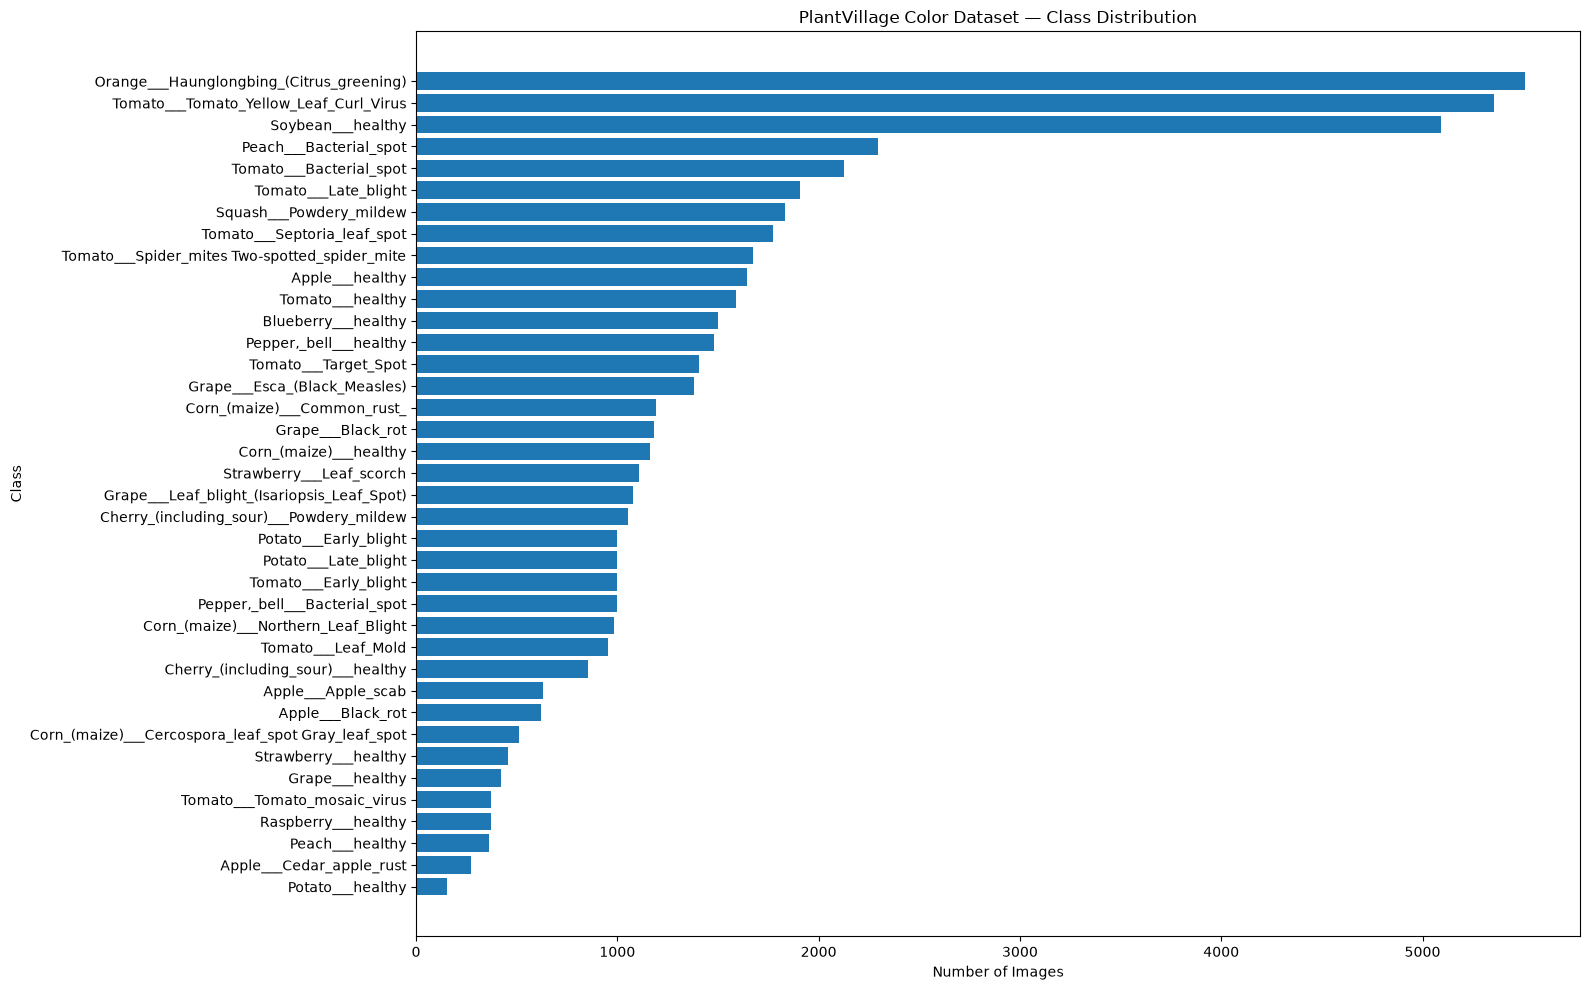


CLASS IMBALANCE STATISTICS

Maximum class size : 5,507
Minimum class size : 152
Mean class size    : 1,429.08
Median class size  : 1,092.50
Max/Min ratio      : 36.23x

SMALLEST CLASSES


,image_count
class_name,
Potato___healthy,152
Apple___Cedar_apple_rust,275
Peach___healthy,360
Raspberry___healthy,371
Tomato___Tomato_mosaic_virus,373
Grape___healthy,423
Strawberry___healthy,456
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot,513
Apple___Black_rot,621



LARGEST CLASSES


,image_count
class_name,
Orange___Haunglongbing_(Citrus_greening),5507
Tomato___Tomato_Yellow_Leaf_Curl_Virus,5357
Soybean___healthy,5090
Peach___Bacterial_spot,2297
Tomato___Bacterial_spot,2127
Tomato___Late_blight,1909
Squash___Powdery_mildew,1835
Tomato___Septoria_leaf_spot,1771
Tomato___Spider_mites Two-spotted_spider_mite,1676



ONE SAMPLE IMAGE PER CLASS


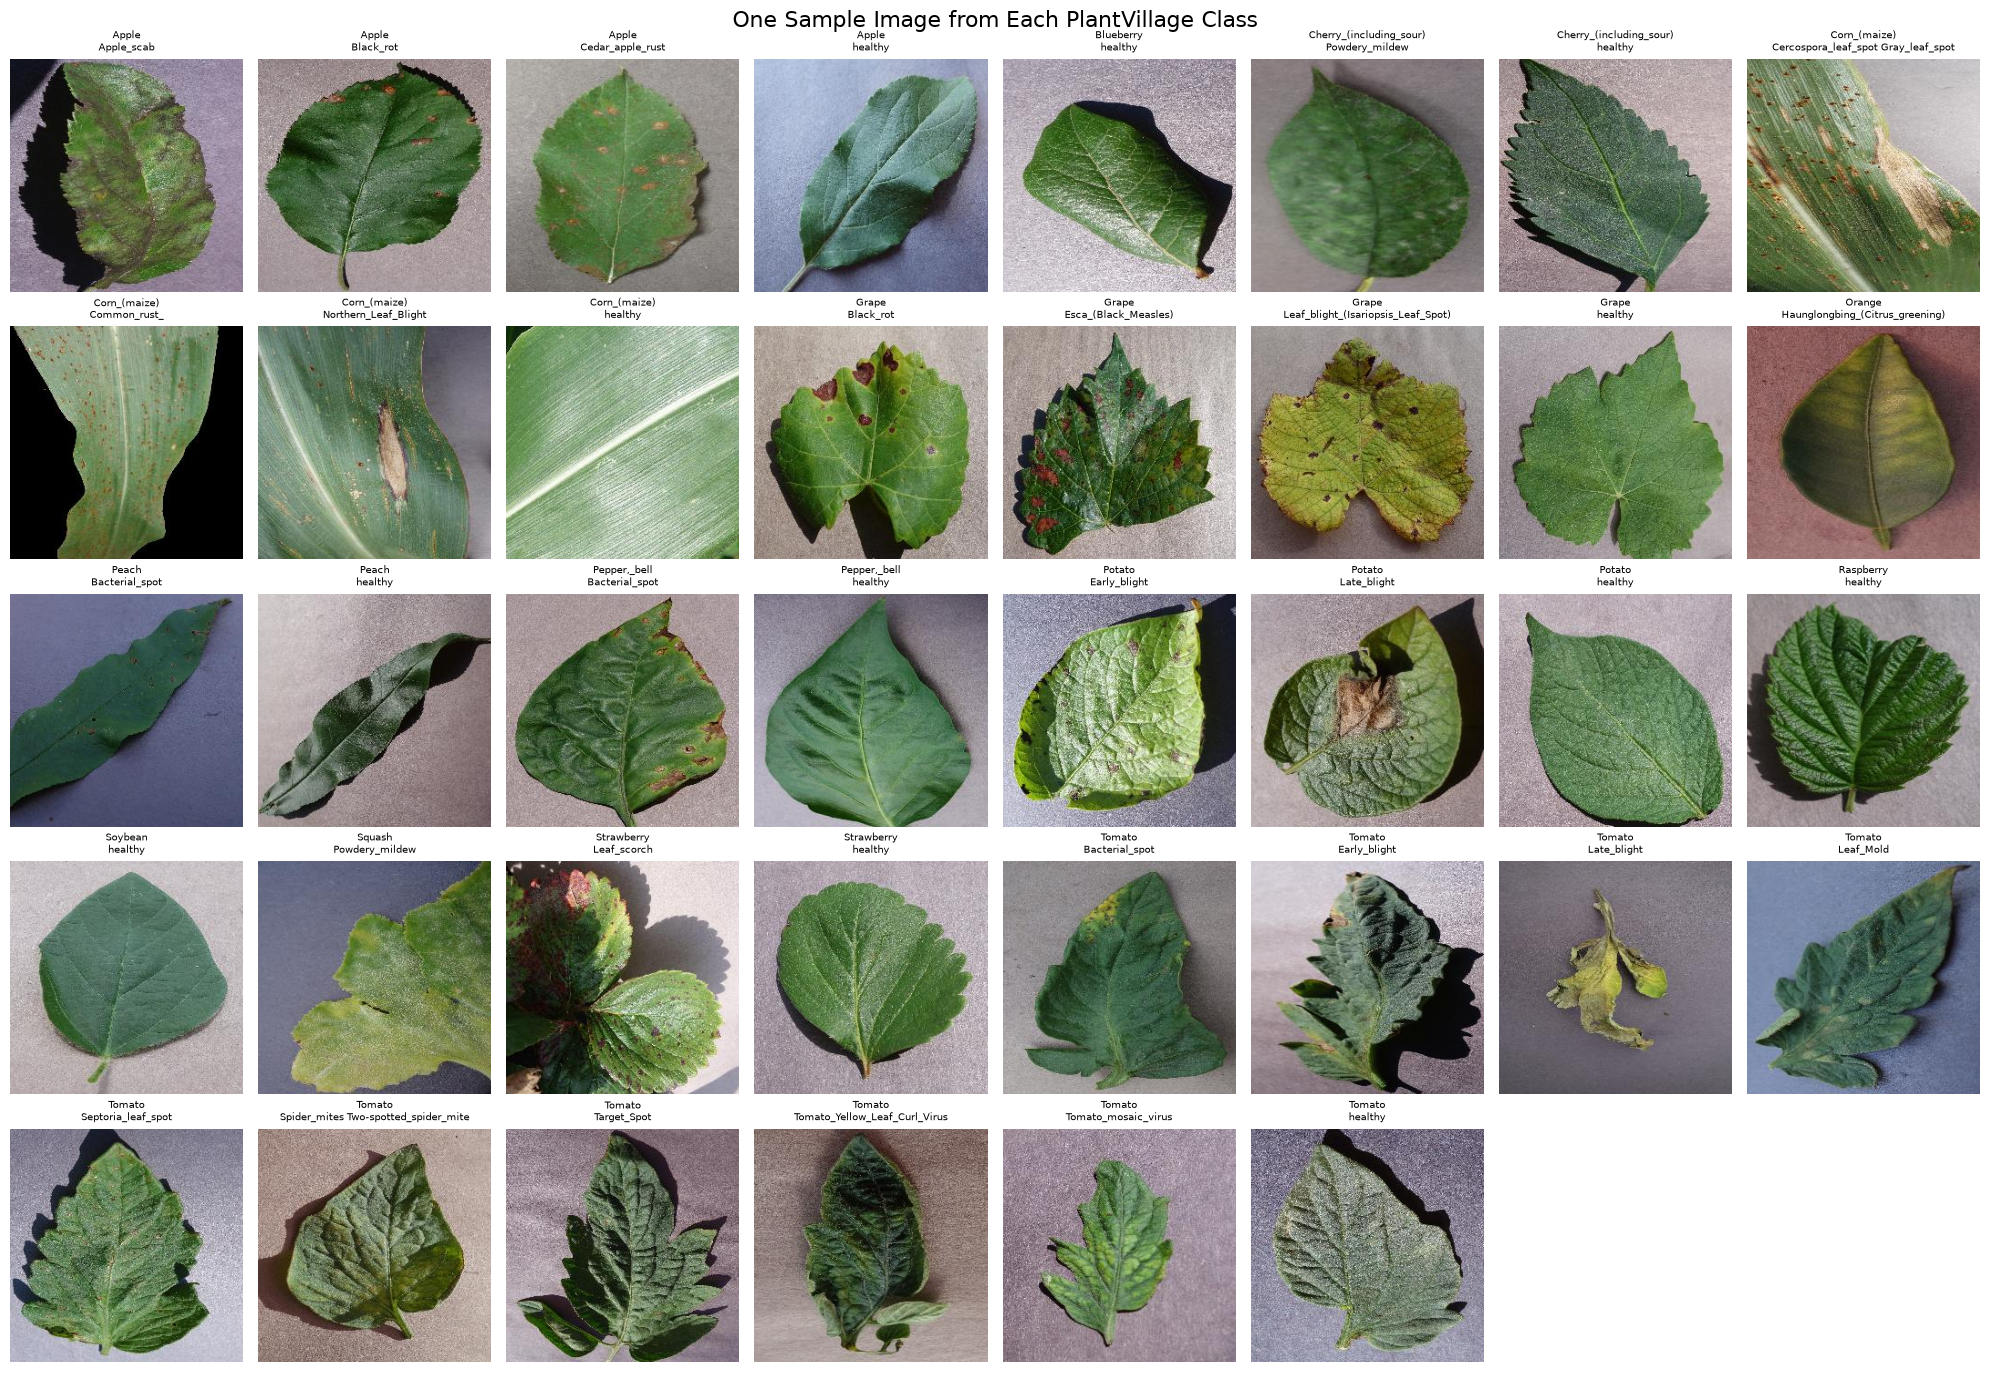


OBSERVATION

The selected color dataset contains 54,305 images
distributed across 38 classes.

The largest class contains 5,507 images,
while the smallest class contains 152 images.

The maximum-to-minimum class ratio is approximately
36.23x.

We will NOT blindly balance the dataset by duplicating images.
The train/validation/test split will be stratified, and the
training strategy can account for class imbalance where
appropriate.

✓ Cell 5 complete.


In [7]:
# ============================================================
# CELL 5 — DATASET VISUAL ANALYSIS
# ============================================================

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image

print("=" * 70)
print("DATASET VISUAL ANALYSIS")
print("=" * 70)

# ------------------------------------------------------------
# 1. VERIFY DATAFRAME
# ------------------------------------------------------------

DATASET_DF = color_dataset_df

if "DATASET_DF" not in globals():
    raise RuntimeError(
        "DATASET_DF was not created. "
        "Please run Cell 4 first."
    )

print(f"\nTotal images : {len(DATASET_DF):,}")
print(
    f"Total classes: "
    f"{DATASET_DF['class_name'].nunique()}"
)

# ------------------------------------------------------------
# 2. CLASS DISTRIBUTION TABLE
# ------------------------------------------------------------

class_distribution = (
    DATASET_DF["class_name"]
    .value_counts()
    .sort_values(ascending=False)
)

class_distribution_df = (
    class_distribution
    .rename("image_count")
    .to_frame()
)

print("\n" + "=" * 70)
print("CLASS DISTRIBUTION")
print("=" * 70)

display(class_distribution_df)

# ------------------------------------------------------------
# 3. CLASS DISTRIBUTION BAR CHART
# ------------------------------------------------------------

plt.figure(figsize=(16, 10))

plt.barh(
    class_distribution.index[::-1],
    class_distribution.values[::-1]
)

plt.xlabel("Number of Images")
plt.ylabel("Class")
plt.title("PlantVillage Color Dataset — Class Distribution")

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 4. IMBALANCE STATISTICS
# ------------------------------------------------------------

maximum_count = class_distribution.max()
minimum_count = class_distribution.min()
mean_count = class_distribution.mean()
median_count = class_distribution.median()

imbalance_ratio = maximum_count / minimum_count

print("\n" + "=" * 70)
print("CLASS IMBALANCE STATISTICS")
print("=" * 70)

print(f"\nMaximum class size : {maximum_count:,}")
print(f"Minimum class size : {minimum_count:,}")
print(f"Mean class size    : {mean_count:,.2f}")
print(f"Median class size  : {median_count:,.2f}")
print(f"Max/Min ratio      : {imbalance_ratio:.2f}x")

# ------------------------------------------------------------
# 5. SMALLEST CLASSES
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("SMALLEST CLASSES")
print("=" * 70)

display(
    class_distribution
    .sort_values()
    .head(10)
    .rename("image_count")
    .to_frame()
)

# ------------------------------------------------------------
# 6. LARGEST CLASSES
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("LARGEST CLASSES")
print("=" * 70)

display(
    class_distribution
    .sort_values(ascending=False)
    .head(10)
    .rename("image_count")
    .to_frame()
)

# ------------------------------------------------------------
# 7. SAMPLE ONE IMAGE FROM EACH OF 38 CLASSES
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("ONE SAMPLE IMAGE PER CLASS")
print("=" * 70)

unique_classes = sorted(
    DATASET_DF["class_name"].unique()
)

sample_records = []

for class_name in unique_classes:

    class_rows = DATASET_DF[
        DATASET_DF["class_name"] == class_name
    ]

    sample_row = class_rows.sample(
        n=1,
        random_state=42
    ).iloc[0]

    sample_records.append({
        "class_name": class_name,
        "image_path": sample_row["image_path"]
    })

# ------------------------------------------------------------
# Plot samples
# ------------------------------------------------------------

fig, axes = plt.subplots(
    5,
    8,
    figsize=(20, 14)
)

axes = axes.flatten()

for index, record in enumerate(sample_records):

    image_path = record["image_path"]
    class_name = record["class_name"]

    try:

        image = Image.open(image_path).convert("RGB")

        axes[index].imshow(image)
        axes[index].axis("off")

        # Make title readable
        display_name = class_name.replace("___", "\n")

        axes[index].set_title(
            display_name,
            fontsize=7
        )

    except Exception as error:

        axes[index].text(
            0.5,
            0.5,
            "Image error",
            ha="center",
            va="center"
        )

        axes[index].axis("off")

# Turn off unused axes
for index in range(len(sample_records), len(axes)):
    axes[index].axis("off")

plt.suptitle(
    "One Sample Image from Each PlantVillage Class",
    fontsize=16
)

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 8. BASIC DATASET OBSERVATION
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("OBSERVATION")
print("=" * 70)

print(
    f"""
The selected color dataset contains {len(DATASET_DF):,} images
distributed across {len(unique_classes)} classes.

The largest class contains {maximum_count:,} images,
while the smallest class contains {minimum_count:,} images.

The maximum-to-minimum class ratio is approximately
{imbalance_ratio:.2f}x.

We will NOT blindly balance the dataset by duplicating images.
The train/validation/test split will be stratified, and the
training strategy can account for class imbalance where
appropriate.
"""
)

print("✓ Cell 5 complete.")

In [6]:
# ============================================================
# CELL 6 — PARSE PLANTVILLAGE LABELS
# ============================================================

import pandas as pd
import numpy as np

print("=" * 70)
print("LABEL PARSING")
print("=" * 70)

# ------------------------------------------------------------
# 1. VERIFY DATAFRAME
# ------------------------------------------------------------

if "DATASET_DF" not in globals():
    raise RuntimeError(
        "DATASET_DF is not available. "
        "Please run Cells 1–5 first."
    )

# Work on a copy so the original dataframe is preserved.
DATASET_DF = DATASET_DF.copy()

# ------------------------------------------------------------
# 2. PARSE CLASS NAME
# ------------------------------------------------------------

def parse_plantvillage_label(class_name):
    """
    Parse a PlantVillage class name of the form:

        Crop___Disease

    Examples:
        Apple___Apple_scab
        Tomato___Late_blight
        Apple___healthy
    """

    # PlantVillage uses exactly three underscores
    # to separate crop and condition.
    if "___" not in class_name:
        return pd.Series({
            "crop": class_name,
            "condition": "Unknown",
            "health_status": "Unknown",
            "disease": "Unknown"
        })

    crop, condition = class_name.split("___", 1)

    # Clean crop name
    crop = crop.strip()

    # Clean condition
    condition = condition.strip()

    # Healthy classes
    if condition.lower() == "healthy":

        health_status = "Healthy"
        disease = "Healthy"

    else:

        health_status = "Diseased"

        # Convert underscores to spaces for readability.
        disease = condition.replace("_", " ")

        # Remove accidental extra spaces.
        disease = " ".join(disease.split())

    return pd.Series({
        "crop": crop,
        "condition": condition,
        "health_status": health_status,
        "disease": disease
    })


# ------------------------------------------------------------
# 3. APPLY PARSER
# ------------------------------------------------------------

parsed_labels = DATASET_DF["class_name"].apply(
    parse_plantvillage_label
)

DATASET_DF = pd.concat(
    [
        DATASET_DF.reset_index(drop=True),
        parsed_labels.reset_index(drop=True)
    ],
    axis=1
)

# ------------------------------------------------------------
# 4. DISPLAY CLASS-LEVEL LABEL MAPPING
# ------------------------------------------------------------

label_mapping_df = (
    DATASET_DF[
        [
            "class_name",
            "crop",
            "condition",
            "health_status",
            "disease"
        ]
    ]
    .drop_duplicates()
    .sort_values(["crop", "condition"])
    .reset_index(drop=True)
)

print("\n" + "=" * 70)
print("CLASS → CROP / HEALTH / DISEASE MAPPING")
print("=" * 70)

display(label_mapping_df)

# ------------------------------------------------------------
# 5. CHECK NUMBER OF CROPS
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("CROP SUMMARY")
print("=" * 70)

crop_counts = (
    DATASET_DF
    .groupby("crop")
    .agg(
        images=("image_path", "count"),
        classes=("class_name", "nunique")
    )
    .sort_values("images", ascending=False)
)

display(crop_counts)

print(f"\nNumber of unique crops: {DATASET_DF['crop'].nunique()}")

# ------------------------------------------------------------
# 6. HEALTH STATUS DISTRIBUTION
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("HEALTH STATUS DISTRIBUTION")
print("=" * 70)

health_counts = (
    DATASET_DF["health_status"]
    .value_counts()
    .rename("image_count")
    .to_frame()
)

display(health_counts)

# ------------------------------------------------------------
# 7. DISEASE DISTRIBUTION
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("DISEASE / CONDITION DISTRIBUTION")
print("=" * 70)

disease_counts = (
    DATASET_DF["disease"]
    .value_counts()
    .rename("image_count")
    .to_frame()
)

display(disease_counts)

# ------------------------------------------------------------
# 8. CHECK FOR UNKNOWN LABELS
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("LABEL VALIDATION")
print("=" * 70)

unknown_crop_count = (
    DATASET_DF["crop"].eq("Unknown").sum()
)

unknown_health_count = (
    DATASET_DF["health_status"].eq("Unknown").sum()
)

unknown_disease_count = (
    DATASET_DF["disease"].eq("Unknown").sum()
)

print(f"Unknown crops       : {unknown_crop_count}")
print(f"Unknown health      : {unknown_health_count}")
print(f"Unknown diseases    : {unknown_disease_count}")

# ------------------------------------------------------------
# 9. VERIFY HEALTH CLASS COUNTS
# ------------------------------------------------------------

healthy_images = (
    DATASET_DF["health_status"]
    .eq("Healthy")
    .sum()
)

diseased_images = (
    DATASET_DF["health_status"]
    .eq("Diseased")
    .sum()
)

print("\nHealthy images      :", f"{healthy_images:,}")
print("Diseased images     :", f"{diseased_images:,}")
print(
    "Total               :",
    f"{healthy_images + diseased_images:,}"
)

# ------------------------------------------------------------
# 10. DISPLAY EXAMPLES
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("EXAMPLE PARSED LABELS")
print("=" * 70)

example_classes = [
    "Apple___Apple_scab",
    "Apple___healthy",
    "Potato___Early_blight",
    "Potato___healthy",
    "Tomato___Late_blight",
    "Tomato___healthy"
]

examples = label_mapping_df[
    label_mapping_df["class_name"].isin(example_classes)
]

display(examples)

# ------------------------------------------------------------
# 11. FINAL VALIDATION
# ------------------------------------------------------------

assert len(DATASET_DF) == 54305, (
    f"Expected 54,305 images, "
    f"but found {len(DATASET_DF):,}."
)

assert DATASET_DF["class_name"].nunique() == 38, (
    f"Expected 38 classes, "
    f"but found {DATASET_DF['class_name'].nunique()}."
)

assert unknown_crop_count == 0
assert unknown_health_count == 0
assert unknown_disease_count == 0

print("\n" + "=" * 70)
print("LABEL PARSING COMPLETE")
print("=" * 70)

print("\n✓ 54,305 images confirmed")
print("✓ 38 classes confirmed")
print("✓ Crop labels parsed")
print("✓ Health status parsed")
print("✓ Disease labels parsed")
print("✓ No unknown labels detected")

print("\nDATASET_DF now contains:")
print(
    """
    image_path
    class_name
    class_index
    crop
    condition
    health_status
    disease
    """
)

print("\n✓ Ready for the train/validation/test split.")

LABEL PARSING

CLASS → CROP / HEALTH / DISEASE MAPPING


,class_name,crop,condition,health_status,disease
0,Apple___Apple_scab,Apple,Apple_scab,Diseased,Apple scab
1,Apple___Black_rot,Apple,Black_rot,Diseased,Black rot
2,Apple___Cedar_apple_rust,Apple,Cedar_apple_rust,Diseased,Cedar apple rust
3,Apple___healthy,Apple,healthy,Healthy,Healthy
4,Blueberry___healthy,Blueberry,healthy,Healthy,Healthy
5,Cherry_(including_sour)___Powdery_mildew,Cherry_(including_sour),Powdery_mildew,Diseased,Powdery mildew
6,Cherry_(including_sour)___healthy,Cherry_(including_sour),healthy,Healthy,Healthy
7,Corn_(maize)___Cercospora_leaf_spot Gray_leaf_...,Corn_(maize),Cercospora_leaf_spot Gray_leaf_spot,Diseased,Cercospora leaf spot Gray leaf spot
8,Corn_(maize)___Common_rust_,Corn_(maize),Common_rust_,Diseased,Common rust
9,Corn_(maize)___Northern_Leaf_Blight,Corn_(maize),Northern_Leaf_Blight,Diseased,Northern Leaf Blight



CROP SUMMARY


,images,classes
crop,,
Tomato,18160,10
Orange,5507,1
Soybean,5090,1
Grape,4062,4
Corn_(maize),3852,4
Apple,3171,4
Peach,2657,2
"Pepper,_bell",2475,2
Potato,2152,3



Number of unique crops: 14

HEALTH STATUS DISTRIBUTION


...


DISEASE / CONDITION DISTRIBUTION


,image_count
disease,
Healthy,15084
Haunglongbing (Citrus greening),5507
Bacterial spot,5421
Tomato Yellow Leaf Curl Virus,5357
Late blight,2909
Powdery mildew,2887
Early blight,2000
Black rot,1801
Septoria leaf spot,1771



LABEL VALIDATION
Unknown crops       : 0
Unknown health      : 0
Unknown diseases    : 0

Healthy images      : 15,084
Diseased images     : 39,221
Total               : 54,305

EXAMPLE PARSED LABELS


,class_name,crop,condition,health_status,disease
0,Apple___Apple_scab,Apple,Apple_scab,Diseased,Apple scab
3,Apple___healthy,Apple,healthy,Healthy,Healthy
20,Potato___Early_blight,Potato,Early_blight,Diseased,Early blight
22,Potato___healthy,Potato,healthy,Healthy,Healthy
30,Tomato___Late_blight,Tomato,Late_blight,Diseased,Late blight
37,Tomato___healthy,Tomato,healthy,Healthy,Healthy



LABEL PARSING COMPLETE

✓ 54,305 images confirmed
✓ 38 classes confirmed
✓ Crop labels parsed
✓ Health status parsed
✓ Disease labels parsed
✓ No unknown labels detected

DATASET_DF now contains:

    image_path
    class_name
    class_index
    crop
    condition
    health_status
    disease
    

✓ Ready for the train/validation/test split.


In [10]:
# ============================================================
# CELL 7 — DUPLICATE CHECK + STRATIFIED DATA SPLIT
# ============================================================

import hashlib
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

print("=" * 70)
print("DATA SPLIT AND DATA-LEAKAGE CHECK")
print("=" * 70)

# ------------------------------------------------------------
# 1. VERIFY INPUT DATA
# ------------------------------------------------------------

if "DATASET_DF" not in globals():
    raise RuntimeError(
        "DATASET_DF is not available. "
        "Please run Cells 1–6 first."
    )

EXPECTED_IMAGES = 54305
EXPECTED_CLASSES = 38

assert len(DATASET_DF) == EXPECTED_IMAGES, (
    f"Expected {EXPECTED_IMAGES:,} images, "
    f"found {len(DATASET_DF):,}."
)

assert DATASET_DF["class_name"].nunique() == EXPECTED_CLASSES, (
    f"Expected {EXPECTED_CLASSES} classes, "
    f"found {DATASET_DF['class_name'].nunique()}."
)

# ------------------------------------------------------------
# 2. CHECK DUPLICATE PATHS
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("CHECKING DUPLICATE FILE PATHS")
print("=" * 70)

duplicate_path_count = DATASET_DF["image_path"].duplicated().sum()

print(
    f"\nDuplicate file paths: "
    f"{duplicate_path_count:,}"
)

if duplicate_path_count > 0:

    print(
        "\n⚠ Duplicate paths were found."
    )

else:

    print(
        "✓ No duplicate file paths found."
    )

# ------------------------------------------------------------
# 3. SHA-256 HASH FUNCTION
# ------------------------------------------------------------

def calculate_sha256(file_path, chunk_size=1024 * 1024):
    """
    Calculate the SHA-256 hash of an image file.

    The image bytes are hashed rather than the decoded
    image pixels, making this an exact duplicate check.
    """

    sha256 = hashlib.sha256()

    with open(file_path, "rb") as file:

        while True:

            chunk = file.read(chunk_size)

            if not chunk:
                break

            sha256.update(chunk)

    return sha256.hexdigest()


# ------------------------------------------------------------
# 4. EXACT IMAGE DUPLICATE CHECK
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("CHECKING EXACT IMAGE DUPLICATES")
print("=" * 70)

print(
    "\nCalculating SHA-256 hashes for "
    f"{len(DATASET_DF):,} images."
)

print(
    "This can take a few minutes depending on disk speed."
)

hashes = []

for i, image_path in enumerate(DATASET_DF["image_path"]):

    try:

        file_hash = calculate_sha256(image_path)

    except Exception as error:

        raise RuntimeError(
            f"\nCould not read image:\n{image_path}\n"
            f"Error: {error}"
        )

    hashes.append(file_hash)

    if (i + 1) % 1000 == 0 or (i + 1) == len(DATASET_DF):

        print(
            f"Hashed {i + 1:,}/{len(DATASET_DF):,}",
            end="\r"
        )

print("\n")

DATASET_DF["sha256"] = hashes

# ------------------------------------------------------------
# 5. FIND EXACT DUPLICATE IMAGES
# ------------------------------------------------------------

hash_counts = (
    DATASET_DF["sha256"]
    .value_counts()
)

duplicate_hashes = hash_counts[
    hash_counts > 1
]

duplicate_image_count = (
    hash_counts[hash_counts > 1]
    .sub(1)
    .sum()
)

print("\nUnique image files:", f"{DATASET_DF['sha256'].nunique():,}")
print(
    "Duplicate hash groups:",
    f"{len(duplicate_hashes):,}"
)
print(
    "Extra duplicate images:",
    f"{duplicate_image_count:,}"
)

# ------------------------------------------------------------
# 6. DISPLAY DUPLICATE GROUPS IF PRESENT
# ------------------------------------------------------------

if len(duplicate_hashes) > 0:

    print("\n" + "=" * 70)
    print("DUPLICATE IMAGE GROUPS")
    print("=" * 70)

    duplicate_df = DATASET_DF[
        DATASET_DF["sha256"].isin(
            duplicate_hashes.index
        )
    ].copy()

    duplicate_df = duplicate_df.sort_values(
        "sha256"
    )

    display(
        duplicate_df[
            [
                "sha256",
                "image_path",
                "class_name"
            ]
        ].head(50)
    )

    print(
        "\n⚠ Exact duplicate images were found."
    )

    print(
        "We will remove exact duplicate copies before "
        "creating the final split so an identical file "
        "cannot appear in both train and test."
    )

else:

    print(
        "\n✓ No exact duplicate image files detected."
    )

# ------------------------------------------------------------
# 7. REMOVE EXACT DUPLICATES
# ------------------------------------------------------------

before_dedup = len(DATASET_DF)

DATASET_DF = (
    DATASET_DF
    .drop_duplicates(
        subset=["sha256"],
        keep="first"
    )
    .reset_index(drop=True)
)

after_dedup = len(DATASET_DF)

removed_duplicates = before_dedup - after_dedup

print("\n" + "=" * 70)
print("DEDUPLICATION RESULT")
print("=" * 70)

print(f"\nBefore deduplication : {before_dedup:,}")
print(f"After deduplication  : {after_dedup:,}")
print(f"Removed              : {removed_duplicates:,}")

# ------------------------------------------------------------
# 8. CHECK CLASS COUNTS AFTER DEDUPLICATION
# ------------------------------------------------------------

class_counts_after_dedup = (
    DATASET_DF["class_name"]
    .value_counts()
    .sort_index()
)

print("\nMinimum class size after deduplication:",
      class_counts_after_dedup.min())

print("Maximum class size after deduplication:",
      class_counts_after_dedup.max())

# ------------------------------------------------------------
# 9. STRATIFIED TRAIN / TEMP SPLIT
# ------------------------------------------------------------

RANDOM_SEED = 42

print("\n" + "=" * 70)
print("CREATING STRATIFIED SPLITS")
print("=" * 70)

# 70% train
# 30% temporary pool
#
# We later divide the temporary pool equally:
# 15% validation
# 15% test

train_df, temp_df = train_test_split(
    DATASET_DF,
    test_size=0.30,
    random_state=RANDOM_SEED,
    stratify=DATASET_DF["class_name"]
)

# ------------------------------------------------------------
# 10. SPLIT TEMP INTO VALIDATION + TEST
# ------------------------------------------------------------

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=RANDOM_SEED,
    stratify=temp_df["class_name"]
)

# Reset indices
train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

# ------------------------------------------------------------
# 11. SPLIT SIZE SUMMARY
# ------------------------------------------------------------

total = len(train_df) + len(val_df) + len(test_df)

print("\n" + "=" * 70)
print("SPLIT SUMMARY")
print("=" * 70)

print(f"\nTraining   : {len(train_df):,} "
      f"({len(train_df) / total * 100:.2f}%)")

print(f"Validation : {len(val_df):,} "
      f"({len(val_df) / total * 100:.2f}%)")

print(f"Test       : {len(test_df):,} "
      f"({len(test_df) / total * 100:.2f}%)")

print(f"Total      : {total:,}")

# ------------------------------------------------------------
# 12. VERIFY NO PATH OVERLAP
# ------------------------------------------------------------

train_paths = set(train_df["image_path"])
val_paths = set(val_df["image_path"])
test_paths = set(test_df["image_path"])

train_val_overlap = train_paths.intersection(val_paths)
train_test_overlap = train_paths.intersection(test_paths)
val_test_overlap = val_paths.intersection(test_paths)

print("\n" + "=" * 70)
print("SPLIT LEAKAGE CHECK")
print("=" * 70)

print(
    f"\nTrain ∩ Validation : "
    f"{len(train_val_overlap)}"
)

print(
    f"Train ∩ Test       : "
    f"{len(train_test_overlap)}"
)

print(
    f"Validation ∩ Test  : "
    f"{len(val_test_overlap)}"
)

assert len(train_val_overlap) == 0
assert len(train_test_overlap) == 0
assert len(val_test_overlap) == 0

print(
    "\n✓ No image path appears in more than one split."
)

# ------------------------------------------------------------
# 13. VERIFY HASH OVERLAP
# ------------------------------------------------------------

train_hashes = set(train_df["sha256"])
val_hashes = set(val_df["sha256"])
test_hashes = set(test_df["sha256"])

hash_train_val = train_hashes.intersection(val_hashes)
hash_train_test = train_hashes.intersection(test_hashes)
hash_val_test = val_hashes.intersection(test_hashes)

print("\n" + "=" * 70)
print("EXACT IMAGE LEAKAGE CHECK")
print("=" * 70)

print(
    f"\nTrain ∩ Validation hashes : "
    f"{len(hash_train_val)}"
)

print(
    f"Train ∩ Test hashes       : "
    f"{len(hash_train_test)}"
)

print(
    f"Validation ∩ Test hashes  : "
    f"{len(hash_val_test)}"
)

assert len(hash_train_val) == 0
assert len(hash_train_test) == 0
assert len(hash_val_test) == 0

print(
    "\n✓ No exact duplicate image crosses the splits."
)

# ------------------------------------------------------------
# 14. VERIFY STRATIFICATION
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("CLASS DISTRIBUTION ACROSS SPLITS")
print("=" * 70)

train_distribution = (
    train_df["class_name"]
    .value_counts()
    .sort_index()
)

val_distribution = (
    val_df["class_name"]
    .value_counts()
    .sort_index()
)

test_distribution = (
    test_df["class_name"]
    .value_counts()
    .sort_index()
)

split_distribution_df = pd.DataFrame({
    "total": class_counts_after_dedup,
    "train": train_distribution,
    "validation": val_distribution,
    "test": test_distribution
})

split_distribution_df["train_%"] = (
    split_distribution_df["train"]
    / split_distribution_df["total"]
    * 100
)

split_distribution_df["validation_%"] = (
    split_distribution_df["validation"]
    / split_distribution_df["total"]
    * 100
)

split_distribution_df["test_%"] = (
    split_distribution_df["test"]
    / split_distribution_df["total"]
    * 100
)

display(split_distribution_df)

# ------------------------------------------------------------
# 15. SAVE SPLIT VARIABLES
# ------------------------------------------------------------

TRAIN_DF = train_df
VAL_DF = val_df
TEST_DF = test_df

# ------------------------------------------------------------
# 16. FINAL ASSERTIONS
# ------------------------------------------------------------

assert len(TRAIN_DF) > 0
assert len(VAL_DF) > 0
assert len(TEST_DF) > 0

assert (
    len(TRAIN_DF)
    + len(VAL_DF)
    + len(TEST_DF)
    == len(DATASET_DF)
)

assert (
    TRAIN_DF["class_name"].nunique()
    == 38
)

assert (
    VAL_DF["class_name"].nunique()
    == 38
)

assert (
    TEST_DF["class_name"].nunique()
    == 38
)

print("\n" + "=" * 70)
print("SPLIT COMPLETE")
print("=" * 70)

print(
    """
✓ Exact duplicates checked
✓ Exact duplicate copies removed if present
✓ Stratified 70/15/15 split created
✓ All 38 classes present in train
✓ All 38 classes present in validation
✓ All 38 classes present in test
✓ No path overlap
✓ No exact-image hash overlap

Variables created:

    TRAIN_DF
    VAL_DF
    TEST_DF
    split_distribution_df
    RANDOM_SEED
"""
)

print("\n✓ Ready for PyTorch data loading.")

DATA SPLIT AND DATA-LEAKAGE CHECK

CHECKING DUPLICATE FILE PATHS

Duplicate file paths: 0
✓ No duplicate file paths found.

CHECKING EXACT IMAGE DUPLICATES

Calculating SHA-256 hashes for 54,305 images.
This can take a few minutes depending on disk speed.
Hashed 54,305/54,305


Unique image files: 54,284
Duplicate hash groups: 21
Extra duplicate images: 21

DUPLICATE IMAGE GROUPS


,sha256,image_path,class_name
40315,12852b3616bcf0ba39b03b5677e74f50f5f6abf4d38957...,C:\Users\cscpr\Downloads\random 1\plantvillage...,Tomato___healthy
39730,12852b3616bcf0ba39b03b5677e74f50f5f6abf4d38957...,C:\Users\cscpr\Downloads\random 1\plantvillage...,Tomato___healthy
3156,262198126fd6d982126b69261723e13abb36b383138797...,C:\Users\cscpr\Downloads\random 1\plantvillage...,Apple___healthy
3091,262198126fd6d982126b69261723e13abb36b383138797...,C:\Users\cscpr\Downloads\random 1\plantvillage...,Apple___healthy
39608,2a05a74db3a270ac0ec77c00ebe89a332eed5898194351...,C:\Users\cscpr\Downloads\random 1\plantvillage...,Tomato___healthy
39306,2a05a74db3a270ac0ec77c00ebe89a332eed5898194351...,C:\Users\cscpr\Downloads\random 1\plantvillage...,Tomato___healthy
42593,2aeb7479e975df37dfb54aa7b403f57f2ad90b018c3780...,C:\Users\cscpr\Downloads\random 1\plantvillage...,Tomato___Late_blight
41574,2aeb7479e975df37dfb54aa7b403f57f2ad90b018c3780...,C:\Users\cscpr\Downloads\random 1\plantvillage...,Tomato___Late_blight
40591,32e9ffabaa054c19ae8df95e94fbd7a25105defdea1214...,C:\Users\cscpr\Downloads\random 1\plantvillage...,Tomato___healthy
40230,32e9ffabaa054c19ae8df95e94fbd7a25105defdea1214...,C:\Users\cscpr\Downloads\random 1\plantvillage...,Tomato___healthy



⚠ Exact duplicate images were found.
We will remove exact duplicate copies before creating the final split so an identical file cannot appear in both train and test.

DEDUPLICATION RESULT

Before deduplication : 54,305
After deduplication  : 54,284
Removed              : 21

Minimum class size after deduplication: 152
Maximum class size after deduplication: 5507

CREATING STRATIFIED SPLITS

SPLIT SUMMARY

Training   : 37,998 (70.00%)
Validation : 8,143 (15.00%)
Test       : 8,143 (15.00%)
Total      : 54,284

SPLIT LEAKAGE CHECK

Train ∩ Validation : 0
Train ∩ Test       : 0
Validation ∩ Test  : 0

✓ No image path appears in more than one split.

EXACT IMAGE LEAKAGE CHECK

Train ∩ Validation hashes : 0
Train ∩ Test hashes       : 0
Validation ∩ Test hashes  : 0

✓ No exact duplicate image crosses the splits.

CLASS DISTRIBUTION ACROSS SPLITS


,total,train,validation,test,train_%,validation_%,test_%
class_name,,,,,,,
Apple___Apple_scab,630,441,95,94,70.000000,15.079365,14.920635
Apple___Black_rot,621,435,93,93,70.048309,14.975845,14.975845
Apple___Cedar_apple_rust,275,193,41,41,70.181818,14.909091,14.909091
Apple___healthy,1638,1147,246,245,70.024420,15.018315,14.957265
Blueberry___healthy,1502,1051,225,226,69.973369,14.980027,15.046605
Cherry_(including_sour)___Powdery_mildew,1052,736,158,158,69.961977,15.019011,15.019011
Cherry_(including_sour)___healthy,854,598,128,128,70.023419,14.988290,14.988290
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot,513,359,77,77,69.980507,15.009747,15.009747
Corn_(maize)___Common_rust_,1192,834,179,179,69.966443,15.016779,15.016779



SPLIT COMPLETE

✓ Exact duplicates checked
✓ Exact duplicate copies removed if present
✓ Stratified 70/15/15 split created
✓ All 38 classes present in train
✓ All 38 classes present in validation
✓ All 38 classes present in test
✓ No path overlap
✓ No exact-image hash overlap

Variables created:

    TRAIN_DF
    VAL_DF
    TEST_DF
    split_distribution_df
    RANDOM_SEED


✓ Ready for PyTorch data loading.


In [8]:
# ============================================================
# CELL 8 — PYTORCH / TORCHVISION COMPATIBILITY CHECK
# ============================================================

import sys
import subprocess

print("=" * 70)
print("PYTORCH / TORCHVISION ENVIRONMENT CHECK")
print("=" * 70)

print("\nPython:")
print(sys.version)

print("\nChecking installed packages...")

try:
    import torch

    print("\nPyTorch version :", torch.__version__)
    print("CUDA available  :", torch.cuda.is_available())

    if torch.cuda.is_available():
        print("GPU             :", torch.cuda.get_device_name(0))
        print(
            "GPU memory      : {:.2f} GB".format(
                torch.cuda.get_device_properties(0).total_memory
                / (1024 ** 3)
            )
        )

except Exception as e:
    print("PyTorch import error:", e)


# ------------------------------------------------------------
# TORCHVISION CHECK
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("CHECKING TORCHVISION")
print("=" * 70)

try:

    import torchvision

    print("\nTorchvision version :", torchvision.__version__)
    print("✓ Torchvision imported successfully.")

except Exception as e:

    print("\n✗ Torchvision import failed.")
    print("\nError:")
    print(e)

    print("\n" + "=" * 70)
    print("IMPORTANT")
    print("=" * 70)

    print(
        """
Your installed torchvision package is incompatible with
the installed PyTorch package.

The error:

    operator torchvision::nms does not exist

usually indicates that torchvision was compiled/built against
a different PyTorch version.

DO NOT continue to the model cell yet.

Please run the following in a NEW Jupyter cell:

    %pip show torch torchvision

and send me the complete output.

I will then give you the exact compatible installation
command for your current Python 3.14 + CUDA 13.2 environment.
"""
    )

    raise RuntimeError(
        "Torchvision is incompatible with the installed PyTorch. "
        "Run `%pip show torch torchvision` and send the output."
    )

PYTORCH / TORCHVISION ENVIRONMENT CHECK

Python:
3.14.6 (tags/v3.14.6:c63aec6, Jun 10 2026, 10:26:10) [MSC v.1944 64 bit (AMD64)]

Checking installed packages...

PyTorch version : 2.13.0+cu132
CUDA available  : True
GPU             : NVIDIA GeForce RTX 4050 Laptop GPU
GPU memory      : 6.00 GB

CHECKING TORCHVISION

Torchvision version : 0.28.0+cu132
✓ Torchvision imported successfully.


In [10]:
# ============================================================
# CELL 8B — CHECK INSTALLED PYTORCH / TORCHVISION VERSIONS
# ============================================================

import sys
import subprocess

print("=" * 70)
print("PYTORCH / TORCHVISION PACKAGE INFORMATION")
print("=" * 70)

print("\nPython executable:")
print(sys.executable)

print("\nPython version:")
print(sys.version)

print("\n" + "=" * 70)
print("PIP PACKAGE VERSIONS")
print("=" * 70)

packages = ["torch", "torchvision", "torchaudio"]

for package in packages:

    result = subprocess.run(
        [
            sys.executable,
            "-m",
            "pip",
            "show",
            package
        ],
        capture_output=True,
        text=True
    )

    print("\n" + "-" * 70)
    print(package.upper())
    print("-" * 70)

    if result.stdout.strip():
        print(result.stdout)
    else:
        print("Package not found.")

    if result.stderr.strip():
        print("ERROR:")
        print(result.stderr)

print("\n" + "=" * 70)
print("PYTORCH RUNTIME CHECK")
print("=" * 70)

import torch

print("\nPyTorch version :", torch.__version__)
print("CUDA available  :", torch.cuda.is_available())

if torch.cuda.is_available():

    print("CUDA version    :", torch.version.cuda)
    print("GPU             :", torch.cuda.get_device_name(0))

    props = torch.cuda.get_device_properties(0)

    print(
        "GPU memory      : {:.2f} GB".format(
            props.total_memory / (1024 ** 3)
        )
    )

print("\n✓ Diagnostic complete.")

PYTORCH / TORCHVISION PACKAGE INFORMATION

Python executable:
c:\Users\cscpr\AppData\Local\Programs\Python\Python314\python.exe

Python version:
3.14.6 (tags/v3.14.6:c63aec6, Jun 10 2026, 10:26:10) [MSC v.1944 64 bit (AMD64)]

PIP PACKAGE VERSIONS

----------------------------------------------------------------------
TORCH
----------------------------------------------------------------------
Name: torch
Version: 2.13.0+cu132
Summary: Tensors and Dynamic neural networks in Python with strong GPU acceleration
Home-page: https://pytorch.org
Author: 
Author-email: PyTorch Team <packages@pytorch.org>
License-Expression: Apache-2.0 AND Apache-2.0 WITH LLVM-exception AND BSD-2-Clause AND BSD-3-Clause AND BSL-1.0 AND MIT
Location: c:\Users\cscpr\AppData\Local\Programs\Python\Python314\Lib\site-packages
Requires: filelock, fsspec, jinja2, networkx, setuptools, sympy, typing-extensions
Required-by: thop, timm, torchvision, ultralytics, ultralytics-thop


---------------------------------------

In [11]:
# ============================================================
# CELL 9 — REPAIR TORCHVISION
# ============================================================

import sys
import subprocess

print("=" * 70)
print("REPAIRING TORCHVISION")
print("=" * 70)

python_exe = sys.executable

print("\nPython executable:")
print(python_exe)

print("\nCurrent versions:")
print("PyTorch      : 2.13.0+cu132")
print("TorchVision  : 0.28.0+cu132")

print("\nUninstalling torchvision...")

result = subprocess.run(
    [
        python_exe,
        "-m",
        "pip",
        "uninstall",
        "-y",
        "torchvision"
    ],
    capture_output=True,
    text=True
)

print(result.stdout)

if result.returncode != 0:
    print(result.stderr)
    raise RuntimeError("TorchVision uninstall failed.")

print("\n✓ Old torchvision removed.")

print("\nInstalling matching torchvision 0.28.0+cu132...")

result = subprocess.run(
    [
        python_exe,
        "-m",
        "pip",
        "install",
        "--no-cache-dir",
        "--force-reinstall",
        "torchvision==0.28.0+cu132",
        "--index-url",
        "https://download-r2.pytorch.org/whl/cu132"
    ],
    capture_output=True,
    text=True
)

print(result.stdout)

if result.returncode != 0:
    print("\nINSTALLATION ERROR:")
    print(result.stderr)

    raise RuntimeError(
        "TorchVision installation failed. "
        "Send me the installation output."
    )

print("\n" + "=" * 70)
print("TORCHVISION INSTALLATION COMPLETE")
print("=" * 70)

print(
    "\nIMPORTANT:"
    "\nRestart the Jupyter kernel before testing torchvision."
)

print(
    "\nIn VS Code/Jupyter:"
    "\nKernel → Restart Kernel"
)

REPAIRING TORCHVISION

Python executable:
c:\Users\cscpr\AppData\Local\Programs\Python\Python314\python.exe

Current versions:
PyTorch      : 2.13.0+cu132
TorchVision  : 0.28.0+cu132

Uninstalling torchvision...
Found existing installation: torchvision 0.28.0+cu132
Uninstalling torchvision-0.28.0+cu132:
  Successfully uninstalled torchvision-0.28.0+cu132


✓ Old torchvision removed.

Installing matching torchvision 0.28.0+cu132...
Looking in indexes: https://download-r2.pytorch.org/whl/cu132
   ---------------------------------------- 0.0/9.2 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.2 MB ? eta -:--:--
   -- ------------------------------------- 0.5/9.2 MB 1.1 MB/s eta 0:00:08
   --- ------------------------------------ 0.8/9.2 MB 1.2 MB/s eta 0:00:08
   ---- ----------------------------------- 1.0/9.2 MB 1.2 MB/s eta 0:00:08
   ----- ---------------------------------- 1.3/9.2 MB 1.2 MB/s eta 0:00:07
   ------ --------------------------------- 1.6/9.2 MB 1.2 MB

In [1]:
# ============================================================
# CELL 10 — VERIFY TORCHVISION + GPU
# ============================================================

import torch

print("=" * 70)
print("FINAL PYTORCH / TORCHVISION CHECK")
print("=" * 70)

print("\nPyTorch:")
print("Version :", torch.__version__)

print("\nCUDA:")
print("Available :", torch.cuda.is_available())
print("Version   :", torch.version.cuda)

if torch.cuda.is_available():

    print("\nGPU:")
    print("Name :", torch.cuda.get_device_name(0))

    props = torch.cuda.get_device_properties(0)

    print(
        "VRAM : {:.2f} GB".format(
            props.total_memory / (1024 ** 3)
        )
    )

# ------------------------------------------------------------
# TORCHVISION
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("TORCHVISION")
print("=" * 70)

import torchvision

print("\nTorchVision version:")
print(torchvision.__version__)

# ------------------------------------------------------------
# TRANSFORMS
# ------------------------------------------------------------

from torchvision import transforms

print("\n✓ torchvision imported successfully.")
print("✓ transforms imported successfully.")

# ------------------------------------------------------------
# BASIC TRANSFORM TEST
# ------------------------------------------------------------

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

print("✓ Transform pipeline created successfully.")

# ------------------------------------------------------------
# GPU TEST
# ------------------------------------------------------------

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("\n" + "=" * 70)
print("SELECTED DEVICE")
print("=" * 70)

print("\nDEVICE =", device)

if device.type == "cuda":

    test_tensor = torch.randn(
        8,
        3,
        224,
        224,
        device=device
    )

    print(
        "\nGPU tensor created:",
        test_tensor.shape
    )

    print(
        "Tensor device:",
        test_tensor.device
    )

    result = test_tensor.mean()

    print(
        "GPU calculation successful:",
        result.item()
    )

    del test_tensor

    torch.cuda.empty_cache()

    print("\n✓ RTX 4050 GPU test successful.")

else:

    print("\n⚠ CUDA unavailable.")

FINAL PYTORCH / TORCHVISION CHECK

PyTorch:
Version : 2.13.0+cu132

CUDA:
Available : True
Version   : 13.2

GPU:
Name : NVIDIA GeForce RTX 4050 Laptop GPU
VRAM : 6.00 GB

TORCHVISION

TorchVision version:
0.28.0+cu132

✓ torchvision imported successfully.
✓ transforms imported successfully.
✓ Transform pipeline created successfully.

SELECTED DEVICE

DEVICE = cuda

GPU tensor created: torch.Size([8, 3, 224, 224])
Tensor device: cuda:0
GPU calculation successful: -0.0010469130938872695

✓ RTX 4050 GPU test successful.


In [11]:
# ============================================================
# CELL 11 — PYTORCH DATASET + IMAGE TRANSFORMS
# ============================================================

import os
import random
import numpy as np
import pandas as pd
import torch

from PIL import Image, ImageFile
from torch.utils.data import Dataset
from torchvision import transforms

ImageFile.LOAD_TRUNCATED_IMAGES = True

print("=" * 70)
print("PYTORCH DATASET SETUP")
print("=" * 70)

# ------------------------------------------------------------
# 1. VERIFY PREVIOUS CELLS
# ------------------------------------------------------------

required_variables = [
    "TRAIN_DF",
    "VAL_DF",
    "TEST_DF",
    "DATASET_DF"
]

for variable in required_variables:

    if variable not in globals():

        raise RuntimeError(
            f"{variable} is not available. "
            f"Please run the previous cells first."
        )

print("\n✓ TRAIN_DF available")
print("✓ VAL_DF available")
print("✓ TEST_DF available")
print("✓ DATASET_DF available")

# ------------------------------------------------------------
# 2. CLASS MAPPING
# ------------------------------------------------------------

CLASS_NAMES = sorted(
    DATASET_DF["class_name"].unique()
)

NUM_CLASSES = len(CLASS_NAMES)

CLASS_TO_INDEX = {
    class_name: index
    for index, class_name in enumerate(CLASS_NAMES)
}

INDEX_TO_CLASS = {
    index: class_name
    for class_name, index in CLASS_TO_INDEX.items()
}

print("\n" + "=" * 70)
print("CLASS CONFIGURATION")
print("=" * 70)

print("\nNumber of classes:", NUM_CLASSES)

assert NUM_CLASSES == 38

print("\nFirst 10 classes:")

for index, class_name in enumerate(CLASS_NAMES[:10]):

    print(
        f"{index:2d} : {class_name}"
    )

# ------------------------------------------------------------
# 3. IMAGE SIZE
# ------------------------------------------------------------

IMAGE_SIZE = 224

print("\nImage size:")
print(f"{IMAGE_SIZE} × {IMAGE_SIZE}")

# ------------------------------------------------------------
# 4. NORMALIZATION
# ------------------------------------------------------------

# ImageNet normalization is appropriate when using
# ImageNet-pretrained transfer-learning models.

IMAGENET_MEAN = [
    0.485,
    0.456,
    0.406
]

IMAGENET_STD = [
    0.229,
    0.224,
    0.225
]

# ------------------------------------------------------------
# 5. TRAIN TRANSFORMS
# ------------------------------------------------------------

TRAIN_TRANSFORMS = transforms.Compose([

    transforms.Resize(
        (IMAGE_SIZE, IMAGE_SIZE)
    ),

    transforms.RandomHorizontalFlip(
        p=0.5
    ),

    transforms.RandomVerticalFlip(
        p=0.10
    ),

    transforms.RandomRotation(
        degrees=15
    ),

    transforms.ColorJitter(
        brightness=0.15,
        contrast=0.15,
        saturation=0.15,
        hue=0.03
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=IMAGENET_MEAN,
        std=IMAGENET_STD
    )
])

# ------------------------------------------------------------
# 6. VALIDATION / TEST TRANSFORMS
# ------------------------------------------------------------

EVAL_TRANSFORMS = transforms.Compose([

    transforms.Resize(
        (IMAGE_SIZE, IMAGE_SIZE)
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=IMAGENET_MEAN,
        std=IMAGENET_STD
    )
])

print("\n✓ Training transforms created")
print("✓ Validation/test transforms created")

# ------------------------------------------------------------
# 7. DATASET CLASS
# ------------------------------------------------------------

class PlantVillageDataset(Dataset):

    def __init__(
        self,
        dataframe,
        transform=None
    ):

        self.dataframe = dataframe.reset_index(
            drop=True
        ).copy()

        self.transform = transform

        # Convert labels once rather than doing string
        # lookup during every training iteration.

        self.labels = np.array([
            CLASS_TO_INDEX[class_name]
            for class_name
            in self.dataframe["class_name"]
        ], dtype=np.int64)

    def __len__(self):

        return len(self.dataframe)

    def __getitem__(self, index):

        row = self.dataframe.iloc[index]

        image_path = row["image_path"]

        label = int(self.labels[index])

        try:

            image = Image.open(
                image_path
            ).convert("RGB")

        except Exception as error:

            raise RuntimeError(
                f"\nCould not load image:\n"
                f"{image_path}\n\n"
                f"Error: {error}"
            )

        if self.transform is not None:

            image = self.transform(image)

        return image, label


# ------------------------------------------------------------
# 8. CREATE DATASETS
# ------------------------------------------------------------

TRAIN_DATASET = PlantVillageDataset(
    TRAIN_DF,
    transform=TRAIN_TRANSFORMS
)

VAL_DATASET = PlantVillageDataset(
    VAL_DF,
    transform=EVAL_TRANSFORMS
)

TEST_DATASET = PlantVillageDataset(
    TEST_DF,
    transform=EVAL_TRANSFORMS
)

print("\n" + "=" * 70)
print("DATASET SIZES")
print("=" * 70)

print(
    f"\nTraining dataset   : {len(TRAIN_DATASET):,}"
)

print(
    f"Validation dataset : {len(VAL_DATASET):,}"
)

print(
    f"Test dataset       : {len(TEST_DATASET):,}"
)

# ------------------------------------------------------------
# 9. TEST ONE SAMPLE
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("DATASET SAMPLE TEST")
print("=" * 70)

sample_image, sample_label = TRAIN_DATASET[0]

print("\nImage tensor shape:")
print(sample_image.shape)

print("\nImage tensor dtype:")
print(sample_image.dtype)

print("\nLabel:")
print(sample_label)

print("\nClass:")
print(INDEX_TO_CLASS[sample_label])

assert sample_image.shape == (
    3,
    IMAGE_SIZE,
    IMAGE_SIZE
)

assert sample_image.dtype == torch.float32

assert 0 <= sample_label < NUM_CLASSES

print("\n✓ Dataset sample loaded successfully.")
print("✓ Tensor shape verified.")
print("✓ Label mapping verified.")

print("\n" + "=" * 70)
print("CELL 11 COMPLETE")
print("=" * 70)

PYTORCH DATASET SETUP

✓ TRAIN_DF available
✓ VAL_DF available
✓ TEST_DF available
✓ DATASET_DF available

CLASS CONFIGURATION

Number of classes: 38

First 10 classes:
 0 : Apple___Apple_scab
 1 : Apple___Black_rot
 2 : Apple___Cedar_apple_rust
 3 : Apple___healthy
 4 : Blueberry___healthy
 5 : Cherry_(including_sour)___Powdery_mildew
 6 : Cherry_(including_sour)___healthy
 7 : Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot
 8 : Corn_(maize)___Common_rust_
 9 : Corn_(maize)___Northern_Leaf_Blight

Image size:
224 × 224

✓ Training transforms created
✓ Validation/test transforms created

DATASET SIZES

Training dataset   : 37,998
Validation dataset : 8,143
Test dataset       : 8,143

DATASET SAMPLE TEST

Image tensor shape:
torch.Size([3, 224, 224])

Image tensor dtype:
torch.float32

Label:
12

Class:
Grape___Esca_(Black_Measles)

✓ Dataset sample loaded successfully.
✓ Tensor shape verified.
✓ Label mapping verified.

CELL 11 COMPLETE


In [12]:
# ============================================================
# CELL 12 — PYTORCH DATALOADERS + GPU BATCH TEST
# ============================================================

import os
import time
import torch
from torch.utils.data import DataLoader

print("=" * 70)
print("PYTORCH DATALOADER SETUP")
print("=" * 70)

# ------------------------------------------------------------
# 1. VERIFY REQUIRED VARIABLES
# ------------------------------------------------------------

required_variables = [
    "TRAIN_DATASET",
    "VAL_DATASET",
    "TEST_DATASET",
    "DEVICE"
]

for variable in required_variables:

    if variable not in globals():

        raise RuntimeError(
            f"{variable} is not available. "
            "Please run the previous dataset cell first."
        )

print("\n✓ Dataset objects available")
print(f"✓ Device: {DEVICE}")

# ------------------------------------------------------------
# 2. GPU / CPU CONFIGURATION
# ------------------------------------------------------------

if DEVICE.type == "cuda":

    print("\n" + "=" * 70)
    print("GPU CONFIGURATION")
    print("=" * 70)

    print(f"\nGPU: {torch.cuda.get_device_name(0)}")

    gpu_memory_gb = (
        torch.cuda.get_device_properties(0).total_memory
        / (1024 ** 3)
    )

    print(f"VRAM: {gpu_memory_gb:.2f} GB")

    # RTX 4050 Laptop has 6 GB VRAM.
    # Start conservatively and increase later if safe.
    BATCH_SIZE = 32

else:

    print("\n⚠ CUDA unavailable.")
    print("Using CPU.")

    BATCH_SIZE = 16


# ------------------------------------------------------------
# 3. DATALOADER SETTINGS
# ------------------------------------------------------------

NUM_WORKERS = 0 if os.name == "nt" else min(4, os.cpu_count() or 1)

PIN_MEMORY = DEVICE.type == "cuda"

PERSISTENT_WORKERS = (
    NUM_WORKERS > 0
)

print("\n" + "=" * 70)
print("DATALOADER CONFIGURATION")
print("=" * 70)

print(f"\nBatch size        : {BATCH_SIZE}")
print(f"Num workers       : {NUM_WORKERS}")
print(f"Pin memory        : {PIN_MEMORY}")
print(f"Persistent workers: {PERSISTENT_WORKERS}")


# ------------------------------------------------------------
# 4. CREATE TRAIN DATALOADER
# ------------------------------------------------------------

TRAIN_LOADER = DataLoader(
    TRAIN_DATASET,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    persistent_workers=PERSISTENT_WORKERS
)


# ------------------------------------------------------------
# 5. CREATE VALIDATION DATALOADER
# ------------------------------------------------------------

VAL_LOADER = DataLoader(
    VAL_DATASET,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    persistent_workers=PERSISTENT_WORKERS
)


# ------------------------------------------------------------
# 6. CREATE TEST DATALOADER
# ------------------------------------------------------------

TEST_LOADER = DataLoader(
    TEST_DATASET,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    persistent_workers=PERSISTENT_WORKERS
)


# ------------------------------------------------------------
# 7. DATALOADER SIZE
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("DATALOADER SIZES")
print("=" * 70)

print(f"\nTraining batches   : {len(TRAIN_LOADER):,}")
print(f"Validation batches : {len(VAL_LOADER):,}")
print(f"Test batches       : {len(TEST_LOADER):,}")


# ------------------------------------------------------------
# 8. LOAD ONE REAL TRAINING BATCH
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("TESTING REAL TRAINING BATCH")
print("=" * 70)

start_time = time.perf_counter()

images, labels = next(iter(TRAIN_LOADER))

load_time = time.perf_counter() - start_time

print(f"\nCPU batch loading time: {load_time:.3f} seconds")

print("\nCPU batch:")
print(f"Images shape : {images.shape}")
print(f"Images dtype : {images.dtype}")
print(f"Labels shape : {labels.shape}")
print(f"Labels dtype : {labels.dtype}")


# ------------------------------------------------------------
# 9. MOVE BATCH TO GPU
# ------------------------------------------------------------

if DEVICE.type == "cuda":

    start_time = time.perf_counter()

    images_gpu = images.to(
        DEVICE,
        non_blocking=True
    )

    labels_gpu = labels.to(
        DEVICE,
        non_blocking=True
    )

    torch.cuda.synchronize()

    gpu_transfer_time = (
        time.perf_counter() - start_time
    )

else:

    images_gpu = images.to(DEVICE)
    labels_gpu = labels.to(DEVICE)

    gpu_transfer_time = None


# ------------------------------------------------------------
# 10. VERIFY GPU BATCH
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("GPU BATCH VERIFICATION")
print("=" * 70)

print(f"\nImages device : {images_gpu.device}")
print(f"Labels device : {labels_gpu.device}")

if gpu_transfer_time is not None:

    print(
        f"GPU transfer time: "
        f"{gpu_transfer_time:.4f} seconds"
    )

assert images_gpu.shape == (
    BATCH_SIZE,
    3,
    224,
    224
)

assert labels_gpu.shape == (
    BATCH_SIZE,
)

if DEVICE.type == "cuda":

    assert images_gpu.is_cuda
    assert labels_gpu.is_cuda

    print("\n✓ Images successfully transferred to GPU")
    print("✓ Labels successfully transferred to GPU")


# ------------------------------------------------------------
# 11. GPU COMPUTATION TEST
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("GPU COMPUTATION TEST")
print("=" * 70)

if DEVICE.type == "cuda":

    torch.cuda.synchronize()

    start_time = time.perf_counter()

    # Simple GPU operation
    test_result = (
        images_gpu.mean()
        + labels_gpu.float().mean()
    )

    torch.cuda.synchronize()

    computation_time = (
        time.perf_counter() - start_time
    )

    print(
        f"\nGPU computation time: "
        f"{computation_time:.6f} seconds"
    )

    print(
        f"GPU result: "
        f"{test_result.item():.6f}"
    )

    print("\n✓ GPU computation successful")

else:

    test_result = (
        images_gpu.mean()
        + labels_gpu.float().mean()
    )

    print(
        f"\nCPU result: "
        f"{test_result.item():.6f}"
    )


# ------------------------------------------------------------
# 12. GPU MEMORY CHECK
# ------------------------------------------------------------

if DEVICE.type == "cuda":

    allocated_gb = (
        torch.cuda.memory_allocated(0)
        / (1024 ** 3)
    )

    reserved_gb = (
        torch.cuda.memory_reserved(0)
        / (1024 ** 3)
    )

    print("\n" + "=" * 70)
    print("GPU MEMORY STATUS")
    print("=" * 70)

    print(
        f"\nAllocated VRAM : "
        f"{allocated_gb:.3f} GB"
    )

    print(
        f"Reserved VRAM  : "
        f"{reserved_gb:.3f} GB"
    )


# ------------------------------------------------------------
# 13. FINAL STATUS
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("CELL 12 COMPLETE")
print("=" * 70)

print(
    """
✓ Train DataLoader created
✓ Validation DataLoader created
✓ Test DataLoader created
✓ Real training batch loaded
✓ Batch shape verified
✓ Batch transferred to GPU
✓ GPU computation verified

Variables created:

    TRAIN_LOADER
    VAL_LOADER
    TEST_LOADER
    BATCH_SIZE
    NUM_WORKERS
    PIN_MEMORY

Ready for model architecture.
"""
)

PYTORCH DATALOADER SETUP

✓ Dataset objects available
✓ Device: cuda

GPU CONFIGURATION

GPU: NVIDIA GeForce RTX 4050 Laptop GPU
VRAM: 6.00 GB

DATALOADER CONFIGURATION

Batch size        : 32
Num workers       : 0
Pin memory        : True
Persistent workers: False

DATALOADER SIZES

Training batches   : 1,188
Validation batches : 255
Test batches       : 255

TESTING REAL TRAINING BATCH

CPU batch loading time: 0.355 seconds

CPU batch:
Images shape : torch.Size([32, 3, 224, 224])
Images dtype : torch.float32
Labels shape : torch.Size([32])
Labels dtype : torch.int64

GPU BATCH VERIFICATION

Images device : cuda:0
Labels device : cuda:0
GPU transfer time: 0.0183 seconds

✓ Images successfully transferred to GPU
✓ Labels successfully transferred to GPU

GPU COMPUTATION TEST

GPU computation time: 0.038528 seconds
GPU result: 20.237041

✓ GPU computation successful

GPU MEMORY STATUS

Allocated VRAM : 0.018 GB
Reserved VRAM  : 0.021 GB

CELL 12 COMPLETE

✓ Train DataLoader created
✓ Val

In [13]:
# ============================================================
# CELL 13 — EFFICIENTNET-B0 MODEL SETUP
# ============================================================

import torch
import torch.nn as nn
from torchvision import models

print("=" * 70)
print("MODEL ARCHITECTURE SETUP")
print("=" * 70)

# ------------------------------------------------------------
# 1. VERIFY ENVIRONMENT
# ------------------------------------------------------------

if "DEVICE" not in globals():
    raise RuntimeError(
        "DEVICE is not available. Please run the GPU setup cells first."
    )

if "TRAIN_LOADER" not in globals():
    raise RuntimeError(
        "TRAIN_LOADER is not available. Please run Cell 12 first."
    )

NUM_CLASSES = 38

print(f"\nNumber of classes : {NUM_CLASSES}")
print(f"Device            : {DEVICE}")

# ------------------------------------------------------------
# 2. GPU INFORMATION
# ------------------------------------------------------------

if DEVICE.type == "cuda":

    print(f"GPU               : {torch.cuda.get_device_name(0)}")

    total_vram = (
        torch.cuda.get_device_properties(0).total_memory
        / (1024 ** 3)
    )

    print(f"Total VRAM        : {total_vram:.2f} GB")


# ------------------------------------------------------------
# 3. LOAD PRETRAINED EFFICIENTNET-B0
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("LOADING PRETRAINED MODEL")
print("=" * 70)

print("\nLoading ImageNet-pretrained EfficientNet-B0...")

try:

    weights = models.EfficientNet_B0_Weights.DEFAULT

    MODEL = models.efficientnet_b0(
        weights=weights
    )

    print("✓ Pretrained weights loaded")

except Exception as error:

    raise RuntimeError(
        "Could not load EfficientNet-B0 pretrained weights.\n"
        f"Original error: {error}"
    )


# ------------------------------------------------------------
# 4. REPLACE CLASSIFIER
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("CONFIGURING CLASSIFIER")
print("=" * 70)

# EfficientNet-B0 classifier:
#
# Dropout
# Linear(1280 -> 1000)
#
# Replace final Linear layer with:
# Linear(1280 -> 38)

in_features = MODEL.classifier[1].in_features

MODEL.classifier[1] = nn.Linear(
    in_features,
    NUM_CLASSES
)

print(f"\nOriginal classifier input : {in_features}")
print(f"New classifier output     : {NUM_CLASSES}")

print("✓ Classifier replaced")


# ------------------------------------------------------------
# 5. MOVE MODEL TO GPU
# ------------------------------------------------------------

MODEL = MODEL.to(DEVICE)

print("\n✓ Model moved to:", DEVICE)


# ------------------------------------------------------------
# 6. COUNT PARAMETERS
# ------------------------------------------------------------

total_parameters = sum(
    parameter.numel()
    for parameter in MODEL.parameters()
)

trainable_parameters = sum(
    parameter.numel()
    for parameter in MODEL.parameters()
    if parameter.requires_grad
)

print("\n" + "=" * 70)
print("MODEL PARAMETERS")
print("=" * 70)

print(
    f"\nTotal parameters     : "
    f"{total_parameters:,}"
)

print(
    f"Trainable parameters : "
    f"{trainable_parameters:,}"
)

print(
    f"Total parameters     : "
    f"{total_parameters / 1e6:.2f} million"
)


# ------------------------------------------------------------
# 7. MODEL SUMMARY
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("MODEL ARCHITECTURE")
print("=" * 70)

print(MODEL)


# ------------------------------------------------------------
# 8. MIXED PRECISION CONFIGURATION
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("MIXED PRECISION CONFIGURATION")
print("=" * 70)

USE_AMP = DEVICE.type == "cuda"

print(f"\nAutomatic Mixed Precision : {USE_AMP}")

if USE_AMP:

    print("✓ FP16 mixed precision will be used during training")
    print("✓ This reduces VRAM usage and improves RTX 4050 performance")

else:

    print("⚠ AMP disabled because CUDA is unavailable")


# ------------------------------------------------------------
# 9. FORWARD-PASS TEST
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("REAL GPU FORWARD-PASS TEST")
print("=" * 70)

# Get one actual batch from the DataLoader
test_images, test_labels = next(
    iter(TRAIN_LOADER)
)

test_images = test_images.to(
    DEVICE,
    non_blocking=True
)

test_labels = test_labels.to(
    DEVICE,
    non_blocking=True
)

print("\nInput tensor:")
print(f"Shape  : {test_images.shape}")
print(f"Dtype  : {test_images.dtype}")
print(f"Device : {test_images.device}")


# Clear previous GPU cache
if DEVICE.type == "cuda":

    torch.cuda.empty_cache()

    torch.cuda.reset_peak_memory_stats()


# Forward pass
MODEL.eval()

with torch.no_grad():

    if USE_AMP:

        with torch.autocast(
            device_type="cuda",
            dtype=torch.float16
        ):

            test_output = MODEL(
                test_images
            )

    else:

        test_output = MODEL(
            test_images
        )


# ------------------------------------------------------------
# 10. VERIFY OUTPUT
# ------------------------------------------------------------

print("\nOutput tensor:")
print(f"Shape  : {test_output.shape}")
print(f"Dtype  : {test_output.dtype}")
print(f"Device : {test_output.device}")

assert test_output.shape == (
    test_images.shape[0],
    NUM_CLASSES
)

assert test_output.device.type == DEVICE.type

print(
    "\n✓ Forward pass successful"
)

print(
    "✓ Output correctly contains "
    f"{NUM_CLASSES} class logits"
)


# ------------------------------------------------------------
# 11. GPU MEMORY AFTER FORWARD PASS
# ------------------------------------------------------------

if DEVICE.type == "cuda":

    allocated = (
        torch.cuda.memory_allocated(0)
        / (1024 ** 3)
    )

    reserved = (
        torch.cuda.memory_reserved(0)
        / (1024 ** 3)
    )

    peak_allocated = (
        torch.cuda.max_memory_allocated(0)
        / (1024 ** 3)
    )

    print("\n" + "=" * 70)
    print("GPU MEMORY AFTER FORWARD PASS")
    print("=" * 70)

    print(
        f"\nCurrently allocated : "
        f"{allocated:.3f} GB"
    )

    print(
        f"Currently reserved  : "
        f"{reserved:.3f} GB"
    )

    print(
        f"Peak allocated      : "
        f"{peak_allocated:.3f} GB"
    )


# ------------------------------------------------------------
# 12. SAMPLE PREDICTIONS
# ------------------------------------------------------------

probabilities = torch.softmax(
    test_output,
    dim=1
)

predicted_classes = torch.argmax(
    probabilities,
    dim=1
)

print("\n" + "=" * 70)
print("SAMPLE OUTPUT")
print("=" * 70)

print("\nFirst 10 predictions:")

for i in range(
    min(10, len(predicted_classes))
):

    print(
        f"Image {i:02d} | "
        f"True class index: {test_labels[i].item():2d} | "
        f"Initial prediction: {predicted_classes[i].item():2d}"
    )

print(
    "\nNote: these predictions are NOT expected to be accurate yet."
)

print(
    "The classifier head has just been replaced and has not been trained."
)


# ------------------------------------------------------------
# 13. CLEANUP TEST TENSORS
# ------------------------------------------------------------

del test_images
del test_labels
del test_output
del probabilities
del predicted_classes

if DEVICE.type == "cuda":

    torch.cuda.empty_cache()


# ------------------------------------------------------------
# 14. FINAL STATUS
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("CELL 13 COMPLETE")
print("=" * 70)

print(
    """
✓ EfficientNet-B0 loaded
✓ ImageNet pretrained weights loaded
✓ Final classifier changed to 38 classes
✓ Model moved to RTX 4050
✓ Mixed precision configured
✓ Real GPU forward pass successful
✓ Output shape verified
✓ GPU memory checked

Variables created:

    MODEL
    NUM_CLASSES
    USE_AMP

Ready for loss function, class-imbalance handling,
optimizer and training configuration.
"""
)

MODEL ARCHITECTURE SETUP

Number of classes : 38
Device            : cuda
GPU               : NVIDIA GeForce RTX 4050 Laptop GPU
Total VRAM        : 6.00 GB

LOADING PRETRAINED MODEL

Loading ImageNet-pretrained EfficientNet-B0...
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to C:\Users\cscpr/.cache\torch\hub\checkpoints\efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:18<00:00, 1.18MB/s]


✓ Pretrained weights loaded

CONFIGURING CLASSIFIER

Original classifier input : 1280
New classifier output     : 38
✓ Classifier replaced

✓ Model moved to: cuda

MODEL PARAMETERS

Total parameters     : 4,056,226
Trainable parameters : 4,056,226
Total parameters     : 4.06 million

MODEL ARCHITECTURE
EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitatio

In [16]:
# ============================================================
# CELL 14 — LOSS, CLASS IMBALANCE, OPTIMIZER & SCHEDULER
# ============================================================

import torch
import torch.nn as nn
from collections import Counter

print("=" * 70)
print("TRAINING CONFIGURATION")
print("=" * 70)

# ------------------------------------------------------------
# CLASS COUNTS — TRAINING SET ONLY
# ------------------------------------------------------------

# IMPORTANT:
# TRAIN_DF uses "class_index", not "label".
train_labels = TRAIN_DF["class_index"].astype(int).tolist()

class_counts = Counter(train_labels)

print("\nClass distribution:")
for class_idx in range(NUM_CLASSES):
    print(
        f"{class_idx:2d} | "
        f"{CLASS_NAMES[class_idx]:55s} | "
        f"{class_counts[class_idx]:5d}"
    )

# ------------------------------------------------------------
# CLASS WEIGHTS
# ------------------------------------------------------------

# Inverse-frequency weighting.
# This gives less frequent classes more influence during training.

counts_tensor = torch.tensor(
    [class_counts[i] for i in range(NUM_CLASSES)],
    dtype=torch.float32
)

class_weights = counts_tensor.sum() / (
    NUM_CLASSES * counts_tensor
)

# Normalize weights so their mean is approximately 1.
class_weights = class_weights / class_weights.mean()

class_weights = class_weights.to(DEVICE)

print("\nClass weights:")
for i in range(NUM_CLASSES):
    print(
        f"{i:2d} | "
        f"{CLASS_NAMES[i]:55s} | "
        f"{class_weights[i].item():.4f}"
    )

# ------------------------------------------------------------
# LOSS FUNCTION
# ------------------------------------------------------------

CRITERION = nn.CrossEntropyLoss(
    weight=class_weights,
    label_smoothing=0.05
)

print("\n✓ CrossEntropyLoss created")
print("✓ Class-imbalance weighting enabled")
print("✓ Label smoothing: 0.05")

# ------------------------------------------------------------
# OPTIMIZER
# ------------------------------------------------------------

LEARNING_RATE = 3e-4
WEIGHT_DECAY = 1e-4

OPTIMIZER = torch.optim.AdamW(
    MODEL.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

print("\nOptimizer:")
print("  AdamW")
print(f"  Learning rate : {LEARNING_RATE}")
print(f"  Weight decay  : {WEIGHT_DECAY}")

# ------------------------------------------------------------
# LEARNING-RATE SCHEDULER
# ------------------------------------------------------------

SCHEDULER = torch.optim.lr_scheduler.ReduceLROnPlateau(
    OPTIMIZER,
    mode="max",
    factor=0.3,
    patience=2,
    min_lr=1e-6
)

print("\nScheduler:")
print("  ReduceLROnPlateau")
print("  Monitors validation accuracy")
print("  Factor   : 0.3")
print("  Patience : 2")

# ------------------------------------------------------------
# AMP SCALER
# ------------------------------------------------------------

if USE_AMP:
    try:
        SCALER = torch.amp.GradScaler("cuda", enabled=True)
    except Exception:
        SCALER = torch.cuda.amp.GradScaler(enabled=True)
else:
    SCALER = None

print("\nMixed precision:")
print(f"  AMP enabled: {USE_AMP}")

# ------------------------------------------------------------
# TRAINING SETTINGS
# ------------------------------------------------------------

NUM_EPOCHS = 15
BEST_VAL_ACC = 0.0
BEST_VAL_LOSS = float("inf")

print("\nTraining:")
print(f"  Epochs : {NUM_EPOCHS}")

print("\n" + "=" * 70)
print("CELL 14 COMPLETE")
print("=" * 70)

print("✓ Class distribution calculated")
print("✓ Class weights created")
print("✓ Weighted CrossEntropyLoss created")
print("✓ AdamW optimizer created")
print("✓ Learning-rate scheduler created")
print("✓ AMP scaler configured")
print("✓ Ready for training")

TRAINING CONFIGURATION

Class distribution:
 0 | Apple___Apple_scab                                      |   441
 1 | Apple___Black_rot                                       |   435
 2 | Apple___Cedar_apple_rust                                |   193
 3 | Apple___healthy                                         |  1147
 4 | Blueberry___healthy                                     |  1051
 5 | Cherry_(including_sour)___Powdery_mildew                |   736
 6 | Cherry_(including_sour)___healthy                       |   598
 7 | Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot      |   359
 8 | Corn_(maize)___Common_rust_                             |   834
 9 | Corn_(maize)___Northern_Leaf_Blight                     |   690
10 | Corn_(maize)___healthy                                  |   813
11 | Grape___Black_rot                                       |   826
12 | Grape___Esca_(Black_Measles)                            |   968
13 | Grape___Leaf_blight_(Isariopsis_Leaf_Spot)            

In [17]:
# ============================================================
# CELL 15 — MODEL TRAINING
# ============================================================

import time
import copy
import math
import torch

print("=" * 70)
print("STARTING MODEL TRAINING")
print("=" * 70)

# ------------------------------------------------------------
# TRAINING SETTINGS
# ------------------------------------------------------------

MODEL = MODEL.to(DEVICE)

best_model_state = copy.deepcopy(MODEL.state_dict())

BEST_VAL_ACC = 0.0
BEST_VAL_LOSS = float("inf")

PATIENCE = 5
epochs_without_improvement = 0

TRAIN_HISTORY = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": [],
    "lr": []
}

# ------------------------------------------------------------
# HELPER: ACCURACY
# ------------------------------------------------------------

def calculate_accuracy(outputs, labels):
    predictions = outputs.argmax(dim=1)
    correct = (predictions == labels).sum().item()
    total = labels.size(0)
    return correct, total


# ------------------------------------------------------------
# TRAINING LOOP
# ------------------------------------------------------------

for epoch in range(NUM_EPOCHS):

    epoch_start = time.time()

    # ========================================================
    # TRAIN
    # ========================================================

    MODEL.train()

    running_loss = 0.0
    running_correct = 0
    running_total = 0

    for batch_idx, (images, labels) in enumerate(TRAIN_LOADER):

        images = images.to(
            DEVICE,
            non_blocking=True
        )

        labels = labels.to(
            DEVICE,
            non_blocking=True
        )

        OPTIMIZER.zero_grad(set_to_none=True)

        # ----------------------------------------------------
        # MIXED PRECISION FORWARD
        # ----------------------------------------------------

        if USE_AMP:

            with torch.autocast(
                device_type="cuda",
                dtype=torch.float16
            ):

                outputs = MODEL(images)
                loss = CRITERION(outputs, labels)

        else:

            outputs = MODEL(images)
            loss = CRITERION(outputs, labels)

        # ----------------------------------------------------
        # BACKPROPAGATION
        # ----------------------------------------------------

        if SCALER is not None:

            SCALER.scale(loss).backward()

            SCALER.step(OPTIMIZER)

            SCALER.update()

        else:

            loss.backward()
            OPTIMIZER.step()

        # ----------------------------------------------------
        # STATISTICS
        # ----------------------------------------------------

        batch_size = labels.size(0)

        running_loss += loss.item() * batch_size

        correct, total = calculate_accuracy(
            outputs.detach(),
            labels
        )

        running_correct += correct
        running_total += total

        # ----------------------------------------------------
        # PROGRESS
        # ----------------------------------------------------

        if (batch_idx + 1) % 100 == 0:

            current_loss = running_loss / running_total
            current_acc = running_correct / running_total

            print(
                f"Epoch {epoch + 1:02d}/{NUM_EPOCHS} | "
                f"Batch {batch_idx + 1:04d}/{len(TRAIN_LOADER)} | "
                f"Loss {current_loss:.4f} | "
                f"Acc {current_acc * 100:.2f}%"
            )

    # --------------------------------------------------------
    # TRAINING METRICS
    # --------------------------------------------------------

    train_loss = running_loss / running_total
    train_acc = running_correct / running_total

    # ========================================================
    # VALIDATION
    # ========================================================

    MODEL.eval()

    val_running_loss = 0.0
    val_running_correct = 0
    val_running_total = 0

    with torch.inference_mode():

        for images, labels in VAL_LOADER:

            images = images.to(
                DEVICE,
                non_blocking=True
            )

            labels = labels.to(
                DEVICE,
                non_blocking=True
            )

            if USE_AMP:

                with torch.autocast(
                    device_type="cuda",
                    dtype=torch.float16
                ):

                    outputs = MODEL(images)
                    loss = CRITERION(outputs, labels)

            else:

                outputs = MODEL(images)
                loss = CRITERION(outputs, labels)

            batch_size = labels.size(0)

            val_running_loss += loss.item() * batch_size

            correct, total = calculate_accuracy(
                outputs,
                labels
            )

            val_running_correct += correct
            val_running_total += total

    # --------------------------------------------------------
    # VALIDATION METRICS
    # --------------------------------------------------------

    val_loss = val_running_loss / val_running_total
    val_acc = val_running_correct / val_running_total

    # --------------------------------------------------------
    # LEARNING RATE
    # --------------------------------------------------------

    current_lr = OPTIMIZER.param_groups[0]["lr"]

    SCHEDULER.step(val_acc)

    # --------------------------------------------------------
    # SAVE HISTORY
    # --------------------------------------------------------

    TRAIN_HISTORY["train_loss"].append(train_loss)
    TRAIN_HISTORY["train_acc"].append(train_acc)
    TRAIN_HISTORY["val_loss"].append(val_loss)
    TRAIN_HISTORY["val_acc"].append(val_acc)
    TRAIN_HISTORY["lr"].append(current_lr)

    # --------------------------------------------------------
    # EPOCH TIME
    # --------------------------------------------------------

    epoch_time = time.time() - epoch_start

    # --------------------------------------------------------
    # GPU MEMORY
    # --------------------------------------------------------

    if torch.cuda.is_available():

        allocated_gb = (
            torch.cuda.memory_allocated(DEVICE)
            / (1024 ** 3)
        )

        peak_gb = (
            torch.cuda.max_memory_allocated(DEVICE)
            / (1024 ** 3)
        )

    else:

        allocated_gb = 0
        peak_gb = 0

    # --------------------------------------------------------
    # BEST MODEL
    # --------------------------------------------------------

    improved = val_acc > BEST_VAL_ACC

    if improved:

        BEST_VAL_ACC = val_acc
        BEST_VAL_LOSS = val_loss

        best_model_state = copy.deepcopy(
            MODEL.state_dict()
        )

        epochs_without_improvement = 0

        # Save checkpoint immediately
        torch.save(
            {
                "epoch": epoch + 1,
                "model_state_dict": MODEL.state_dict(),
                "optimizer_state_dict": OPTIMIZER.state_dict(),
                "scheduler_state_dict": SCHEDULER.state_dict(),
                "best_val_acc": BEST_VAL_ACC,
                "best_val_loss": BEST_VAL_LOSS,
                "class_names": CLASS_NAMES,
                "num_classes": NUM_CLASSES,
            },
            "best_plant_disease_model.pth"
        )

        best_marker = " ★ BEST"

    else:

        epochs_without_improvement += 1

        best_marker = ""

    # --------------------------------------------------------
    # PRINT EPOCH SUMMARY
    # --------------------------------------------------------

    print()
    print("=" * 70)
    print(
        f"EPOCH {epoch + 1:02d}/{NUM_EPOCHS}{best_marker}"
    )
    print("=" * 70)

    print(
        f"Train Loss      : {train_loss:.4f}"
    )

    print(
        f"Train Accuracy  : {train_acc * 100:.2f}%"
    )

    print(
        f"Val Loss        : {val_loss:.4f}"
    )

    print(
        f"Val Accuracy    : {val_acc * 100:.2f}%"
    )

    print(
        f"Learning Rate   : {current_lr:.7f}"
    )

    print(
        f"Epoch Time      : {epoch_time:.1f} sec"
    )

    print(
        f"GPU Allocated   : {allocated_gb:.3f} GB"
    )

    print(
        f"GPU Peak        : {peak_gb:.3f} GB"
    )

    print(
        f"Best Val Acc    : {BEST_VAL_ACC * 100:.2f}%"
    )

    print(
        f"No Improvement  : "
        f"{epochs_without_improvement}/{PATIENCE}"
    )

    # Reset peak memory measurement
    if torch.cuda.is_available():
        torch.cuda.reset_peak_memory_stats()

    # --------------------------------------------------------
    # EARLY STOPPING
    # --------------------------------------------------------

    if epochs_without_improvement >= PATIENCE:

        print()
        print("=" * 70)
        print("EARLY STOPPING")
        print("=" * 70)

        print(
            f"No validation improvement for "
            f"{PATIENCE} epochs."
        )

        break


# ============================================================
# RESTORE BEST MODEL
# ============================================================

MODEL.load_state_dict(best_model_state)

MODEL.eval()

print()
print("=" * 70)
print("TRAINING COMPLETE")
print("=" * 70)

print(
    f"Best validation accuracy : "
    f"{BEST_VAL_ACC * 100:.2f}%"
)

print(
    f"Best validation loss     : "
    f"{BEST_VAL_LOSS:.4f}"
)

print()
print("✓ Best model restored")
print("✓ Best checkpoint saved:")
print("  best_plant_disease_model.pth")

print()
print("TRAIN_HISTORY available")
print("MODEL available")
print("OPTIMIZER available")
print("SCHEDULER available")

print("=" * 70)
print("CELL 15 COMPLETE")
print("=" * 70)

STARTING MODEL TRAINING
Epoch 01/15 | Batch 0100/1188 | Loss 2.2162 | Acc 65.12%
Epoch 01/15 | Batch 0200/1188 | Loss 1.6168 | Acc 77.55%
Epoch 01/15 | Batch 0300/1188 | Loss 1.3792 | Acc 82.69%
Epoch 01/15 | Batch 0400/1188 | Loss 1.2338 | Acc 85.77%
Epoch 01/15 | Batch 0500/1188 | Loss 1.1386 | Acc 87.79%
Epoch 01/15 | Batch 0600/1188 | Loss 1.0790 | Acc 89.05%
Epoch 01/15 | Batch 0700/1188 | Loss 1.0325 | Acc 90.00%
Epoch 01/15 | Batch 0800/1188 | Loss 0.9960 | Acc 90.85%
Epoch 01/15 | Batch 0900/1188 | Loss 0.9652 | Acc 91.51%
Epoch 01/15 | Batch 1000/1188 | Loss 0.9408 | Acc 92.07%
Epoch 01/15 | Batch 1100/1188 | Loss 0.9214 | Acc 92.50%

EPOCH 01/15 ★ BEST
Train Loss      : 0.9070
Train Accuracy  : 92.83%
Val Loss        : 0.6570
Val Accuracy    : 98.94%
Learning Rate   : 0.0003000
Epoch Time      : 682.2 sec
GPU Allocated   : 0.119 GB
GPU Peak        : 1.498 GB
Best Val Acc    : 98.94%
No Improvement  : 0/5
Epoch 02/15 | Batch 0100/1188 | Loss 0.6932 | Acc 98.12%
Epoch 02/15 | B

In [18]:
# ============================================================
# CELL 16A — VERIFY TRAINING OUTPUTS
# ============================================================

print("=" * 70)
print("VERIFYING TRAINING OUTPUTS")
print("=" * 70)

print("MODEL:", type(MODEL).__name__)
print("NUM_CLASSES:", NUM_CLASSES)
print("NUMBER OF CLASS NAMES:", len(CLASS_NAMES))

print()
print("TRAIN_DF columns:")
print(TRAIN_DF.columns.tolist())

print()
print("TRAIN_DF shape:")
print(TRAIN_DF.shape)

print()
print("Checkpoint:")
import os
print(
    "best_plant_disease_model.pth exists:",
    os.path.exists("best_plant_disease_model.pth")
)

print()
print("Training history:")
print("Train epochs:", len(TRAIN_HISTORY["train_loss"]))
print("Best validation accuracy:", f"{BEST_VAL_ACC * 100:.2f}%")
print("Best validation loss:", f"{BEST_VAL_LOSS:.4f}")

print()
print("=" * 70)
print("CELL 16A COMPLETE")
print("=" * 70)

VERIFYING TRAINING OUTPUTS
MODEL: EfficientNet
NUM_CLASSES: 38
NUMBER OF CLASS NAMES: 38

TRAIN_DF columns:
['image_path', 'class_name', 'class_index', 'sha256']

TRAIN_DF shape:
(37998, 4)

Checkpoint:
best_plant_disease_model.pth exists: True

Training history:
Train epochs: 15
Best validation accuracy: 99.86%
Best validation loss: 0.6003

CELL 16A COMPLETE


In [19]:
# ============================================================
# CELL 16B — CHECK DATA SPLITS AND LOADERS
# ============================================================

print("=" * 70)
print("CHECKING DATA SPLITS AND LOADERS")
print("=" * 70)

# Find DataFrames
print("\nDATAFRAMES:")
for name in ["TRAIN_DF", "VAL_DF", "TEST_DF"]:
    if name in globals():
        obj = globals()[name]
        print(f"✓ {name}: shape={obj.shape}, columns={obj.columns.tolist()}")
    else:
        print(f"✗ {name}: NOT FOUND")

# Find loaders
print("\nDATALOADERS:")
for name in ["TRAIN_LOADER", "VAL_LOADER", "TEST_LOADER"]:
    if name in globals():
        obj = globals()[name]
        print(f"✓ {name}: {len(obj)} batches")
    else:
        print(f"✗ {name}: NOT FOUND")

print("\nOTHER RELEVANT OBJECTS:")

for name in [
    "TRAIN_DATASET",
    "VAL_DATASET",
    "TEST_DATASET",
    "TRAIN_SET",
    "VAL_SET",
    "TEST_SET",
    "CLASS_NAMES",
    "NUM_CLASSES",
    "DEVICE"
]:
    if name in globals():
        obj = globals()[name]

        if isinstance(obj, (list, tuple)):
            print(f"✓ {name}: {type(obj).__name__}, length={len(obj)}")
        else:
            print(f"✓ {name}: {type(obj).__name__}")

    else:
        print(f"✗ {name}: NOT FOUND")

print()
print("=" * 70)
print("CELL 16B COMPLETE")
print("=" * 70)

CHECKING DATA SPLITS AND LOADERS

DATAFRAMES:
✓ TRAIN_DF: shape=(37998, 4), columns=['image_path', 'class_name', 'class_index', 'sha256']
✓ VAL_DF: shape=(8143, 4), columns=['image_path', 'class_name', 'class_index', 'sha256']
✓ TEST_DF: shape=(8143, 4), columns=['image_path', 'class_name', 'class_index', 'sha256']

DATALOADERS:
✓ TRAIN_LOADER: 1188 batches
✓ VAL_LOADER: 255 batches
✓ TEST_LOADER: 255 batches

OTHER RELEVANT OBJECTS:
✓ TRAIN_DATASET: PlantVillageDataset
✓ VAL_DATASET: PlantVillageDataset
✓ TEST_DATASET: PlantVillageDataset
✗ TRAIN_SET: NOT FOUND
✗ VAL_SET: NOT FOUND
✗ TEST_SET: NOT FOUND
✓ CLASS_NAMES: list, length=38
✓ NUM_CLASSES: int
✓ DEVICE: device

CELL 16B COMPLETE


In [20]:
# ============================================================
# CELL 17 — FINAL TEST SET EVALUATION
# ============================================================

import torch
import numpy as np
from collections import Counter

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support
)

print("=" * 70)
print("FINAL TEST SET EVALUATION")
print("=" * 70)

# ------------------------------------------------------------
# USE BEST MODEL
# ------------------------------------------------------------

MODEL.eval()

all_predictions = []
all_labels = []

# ------------------------------------------------------------
# RUN INFERENCE ON TEST SET
# ------------------------------------------------------------

print("\nRunning inference on TEST_LOADER...")

with torch.inference_mode():

    for batch_idx, (images, labels) in enumerate(TEST_LOADER):

        images = images.to(
            DEVICE,
            non_blocking=True
        )

        labels = labels.to(
            DEVICE,
            non_blocking=True
        )

        # AMP inference
        if USE_AMP:

            with torch.autocast(
                device_type="cuda",
                dtype=torch.float16
            ):

                outputs = MODEL(images)

        else:

            outputs = MODEL(images)

        predictions = outputs.argmax(dim=1)

        all_predictions.extend(
            predictions.cpu().numpy().tolist()
        )

        all_labels.extend(
            labels.cpu().numpy().tolist()
        )

        if (batch_idx + 1) % 50 == 0:

            print(
                f"Processed "
                f"{batch_idx + 1}/{len(TEST_LOADER)} batches"
            )


# ------------------------------------------------------------
# CONVERT TO NUMPY
# ------------------------------------------------------------

y_true = np.array(all_labels)
y_pred = np.array(all_predictions)

# ------------------------------------------------------------
# BASIC CHECK
# ------------------------------------------------------------

print()
print("Number of test samples:")
print(len(y_true))

print("Number of predictions:")
print(len(y_pred))

assert len(y_true) == len(TEST_DF), (
    f"Prediction count ({len(y_true)}) "
    f"does not match TEST_DF ({len(TEST_DF)})"
)

# ------------------------------------------------------------
# TEST ACCURACY
# ------------------------------------------------------------

test_accuracy = accuracy_score(
    y_true,
    y_pred
)

print()
print("=" * 70)
print("TEST RESULTS")
print("=" * 70)

print(
    f"Test Accuracy : {test_accuracy * 100:.4f}%"
)

print(
    f"Correct       : {(y_true == y_pred).sum():,}"
)

print(
    f"Incorrect     : {(y_true != y_pred).sum():,}"
)

print(
    f"Total         : {len(y_true):,}"
)

# ------------------------------------------------------------
# CLASSIFICATION REPORT
# ------------------------------------------------------------

print()
print("=" * 70)
print("CLASSIFICATION REPORT")
print("=" * 70)

report = classification_report(
    y_true,
    y_pred,
    labels=list(range(NUM_CLASSES)),
    target_names=CLASS_NAMES,
    digits=4,
    zero_division=0
)

print(report)

# ------------------------------------------------------------
# MACRO / WEIGHTED METRICS
# ------------------------------------------------------------

precision_macro, recall_macro, f1_macro, _ = (
    precision_recall_fscore_support(
        y_true,
        y_pred,
        average="macro",
        zero_division=0
    )
)

precision_weighted, recall_weighted, f1_weighted, _ = (
    precision_recall_fscore_support(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )
)

print("=" * 70)
print("OVERALL METRICS")
print("=" * 70)

print(
    f"Macro Precision    : {precision_macro:.4f}"
)

print(
    f"Macro Recall       : {recall_macro:.4f}"
)

print(
    f"Macro F1           : {f1_macro:.4f}"
)

print(
    f"Weighted Precision : {precision_weighted:.4f}"
)

print(
    f"Weighted Recall    : {recall_weighted:.4f}"
)

print(
    f"Weighted F1        : {f1_weighted:.4f}"
)

# ------------------------------------------------------------
# CONFUSION MATRIX
# ------------------------------------------------------------

cm = confusion_matrix(
    y_true,
    y_pred,
    labels=list(range(NUM_CLASSES))
)

print()
print("=" * 70)
print("CONFUSION MATRIX")
print("=" * 70)

print("Shape:", cm.shape)
print(cm)

# ------------------------------------------------------------
# PER-CLASS CORRECT / INCORRECT
# ------------------------------------------------------------

print()
print("=" * 70)
print("PER-CLASS ERROR SUMMARY")
print("=" * 70)

class_summary = []

for class_index in range(NUM_CLASSES):

    total = cm[class_index].sum()
    correct = cm[class_index, class_index]
    incorrect = total - correct

    class_accuracy = (
        correct / total
        if total > 0
        else 0.0
    )

    class_summary.append(
        (
            class_index,
            CLASS_NAMES[class_index],
            total,
            correct,
            incorrect,
            class_accuracy
        )
    )

# Sort by worst class accuracy
class_summary_sorted = sorted(
    class_summary,
    key=lambda x: x[5]
)

print(
    f"{'ID':>3} | "
    f"{'Class':<55} | "
    f"{'Total':>6} | "
    f"{'Correct':>7} | "
    f"{'Wrong':>5} | "
    f"{'Accuracy':>9}"
)

print("-" * 100)

for (
    class_index,
    class_name,
    total,
    correct,
    incorrect,
    class_accuracy
) in class_summary_sorted:

    print(
        f"{class_index:3d} | "
        f"{class_name:<55} | "
        f"{total:6d} | "
        f"{correct:7d} | "
        f"{incorrect:5d} | "
        f"{class_accuracy * 100:8.2f}%"
    )

# ------------------------------------------------------------
# STORE RESULTS FOR LATER CELLS
# ------------------------------------------------------------

TEST_RESULTS = {
    "y_true": y_true,
    "y_pred": y_pred,
    "accuracy": test_accuracy,
    "classification_report": report,
    "confusion_matrix": cm,
    "macro_precision": precision_macro,
    "macro_recall": recall_macro,
    "macro_f1": f1_macro,
    "weighted_precision": precision_weighted,
    "weighted_recall": recall_weighted,
    "weighted_f1": f1_weighted,
    "class_summary": class_summary_sorted
}

print()
print("=" * 70)
print("CELL 17 COMPLETE")
print("=" * 70)

print("✓ Test predictions generated")
print("✓ Test accuracy calculated")
print("✓ Classification report generated")
print("✓ Macro/weighted metrics calculated")
print("✓ Confusion matrix calculated")
print("✓ Per-class errors calculated")
print("✓ TEST_RESULTS saved")
print("=" * 70)

FINAL TEST SET EVALUATION

Running inference on TEST_LOADER...
Processed 50/255 batches
Processed 100/255 batches
Processed 150/255 batches
Processed 200/255 batches
Processed 250/255 batches

Number of test samples:
8143
Number of predictions:
8143

TEST RESULTS
Test Accuracy : 99.8649%
Correct       : 8,132
Incorrect     : 11
Total         : 8,143

CLASSIFICATION REPORT
                                                    precision    recall  f1-score   support

                                Apple___Apple_scab     1.0000    1.0000    1.0000        94
                                 Apple___Black_rot     1.0000    1.0000    1.0000        93
                          Apple___Cedar_apple_rust     1.0000    1.0000    1.0000        41
                                   Apple___healthy     1.0000    1.0000    1.0000       245
                               Blueberry___healthy     1.0000    1.0000    1.0000       226
          Cherry_(including_sour)___Powdery_mildew     1.0000    1.0000 

In [21]:
# ============================================================
# CELL 18 — DATA LEAKAGE / DUPLICATE CHECK
# ============================================================

print("=" * 70)
print("CHECKING FOR DATA LEAKAGE / DUPLICATES")
print("=" * 70)

# ------------------------------------------------------------
# 1. CHECK SHA256 OVERLAP BETWEEN SPLITS
# ------------------------------------------------------------

train_hashes = set(TRAIN_DF["sha256"].astype(str))
val_hashes   = set(VAL_DF["sha256"].astype(str))
test_hashes  = set(TEST_DF["sha256"].astype(str))

train_val_overlap = train_hashes & val_hashes
train_test_overlap = train_hashes & test_hashes
val_test_overlap = val_hashes & test_hashes

print()
print("SHA256 OVERLAP")
print("-" * 70)

print(
    f"Train ↔ Validation : {len(train_val_overlap)}"
)

print(
    f"Train ↔ Test       : {len(train_test_overlap)}"
)

print(
    f"Validation ↔ Test  : {len(val_test_overlap)}"
)

# ------------------------------------------------------------
# 2. CHECK DUPLICATES WITHIN EACH SPLIT
# ------------------------------------------------------------

print()
print("DUPLICATES WITHIN SPLITS")
print("-" * 70)

train_duplicate_count = (
    TRAIN_DF["sha256"]
    .duplicated()
    .sum()
)

val_duplicate_count = (
    VAL_DF["sha256"]
    .duplicated()
    .sum()
)

test_duplicate_count = (
    TEST_DF["sha256"]
    .duplicated()
    .sum()
)

print(
    f"Train duplicates : {train_duplicate_count}"
)

print(
    f"Validation duplicates : {val_duplicate_count}"
)

print(
    f"Test duplicates : {test_duplicate_count}"
)

# ------------------------------------------------------------
# 3. REPORT RESULT
# ------------------------------------------------------------

print()
print("=" * 70)

total_cross_split_overlap = (
    len(train_val_overlap)
    + len(train_test_overlap)
    + len(val_test_overlap)
)

total_internal_duplicates = (
    train_duplicate_count
    + val_duplicate_count
    + test_duplicate_count
)

if total_cross_split_overlap == 0:

    print("✓ NO CROSS-SPLIT SHA256 OVERLAP FOUND")

else:

    print("⚠ CROSS-SPLIT OVERLAP DETECTED")

if total_internal_duplicates == 0:

    print("✓ NO INTERNAL DUPLICATES FOUND")

else:

    print("⚠ INTERNAL DUPLICATES DETECTED")

print("=" * 70)
print("CELL 18 COMPLETE")
print("=" * 70)

CHECKING FOR DATA LEAKAGE / DUPLICATES

SHA256 OVERLAP
----------------------------------------------------------------------
Train ↔ Validation : 0
Train ↔ Test       : 0
Validation ↔ Test  : 0

DUPLICATES WITHIN SPLITS
----------------------------------------------------------------------
Train duplicates : 0
Validation duplicates : 0
Test duplicates : 0

✓ NO CROSS-SPLIT SHA256 OVERLAP FOUND
✓ NO INTERNAL DUPLICATES FOUND
CELL 18 COMPLETE


In [22]:
# ============================================================
# CELL 19 — DETAILED ANALYSIS OF MISCLASSIFIED TEST IMAGES
# ============================================================

import pandas as pd
import numpy as np

print("=" * 70)
print("DETAILED MISCLASSIFICATION ANALYSIS")
print("=" * 70)

# ------------------------------------------------------------
# BUILD TEST RESULTS DATAFRAME
# ------------------------------------------------------------

MISCLASS_DF = TEST_DF.copy().reset_index(drop=True)

MISCLASS_DF["true_index"] = y_true
MISCLASS_DF["pred_index"] = y_pred

MISCLASS_DF["true_class"] = MISCLASS_DF["true_index"].map(
    lambda x: CLASS_NAMES[int(x)]
)

MISCLASS_DF["pred_class"] = MISCLASS_DF["pred_index"].map(
    lambda x: CLASS_NAMES[int(x)]
)

MISCLASS_DF["correct"] = (
    MISCLASS_DF["true_index"] ==
    MISCLASS_DF["pred_index"]
)

# ------------------------------------------------------------
# ONLY WRONG PREDICTIONS
# ------------------------------------------------------------

WRONG_DF = MISCLASS_DF[
    ~MISCLASS_DF["correct"]
].copy()

print()
print(f"Total test samples : {len(MISCLASS_DF)}")
print(f"Correct predictions : {MISCLASS_DF['correct'].sum()}")
print(f"Incorrect predictions : {len(WRONG_DF)}")

# ------------------------------------------------------------
# PRINT EVERY ERROR
# ------------------------------------------------------------

print()
print("=" * 70)
print("ALL MISCLASSIFIED TEST IMAGES")
print("=" * 70)

for idx, row in WRONG_DF.iterrows():

    print()
    print(f"Error #{idx + 1}")
    print("-" * 70)

    print(f"Image path   : {row['image_path']}")
    print(f"True class   : {row['true_class']}")
    print(f"Predicted    : {row['pred_class']}")
    print(f"True index   : {row['true_index']}")
    print(f"Pred index   : {row['pred_index']}")

# ------------------------------------------------------------
# CONFUSION PAIRS
# ------------------------------------------------------------

print()
print("=" * 70)
print("MISCLASSIFICATION PAIRS")
print("=" * 70)

confusion_pairs = (
    WRONG_DF
    .groupby(
        ["true_class", "pred_class"]
    )
    .size()
    .reset_index(name="count")
    .sort_values(
        "count",
        ascending=False
    )
)

print(confusion_pairs.to_string(index=False))

# ------------------------------------------------------------
# SAVE RESULTS
# ------------------------------------------------------------

WRONG_DF.to_csv(
    "misclassified_test_images.csv",
    index=False
)

confusion_pairs.to_csv(
    "misclassification_pairs.csv",
    index=False
)

print()
print("=" * 70)
print("✓ Misclassified images saved")
print("  misclassified_test_images.csv")
print()
print("✓ Confusion pairs saved")
print("  misclassification_pairs.csv")
print("=" * 70)

print("CELL 19 COMPLETE")
print("=" * 70)

DETAILED MISCLASSIFICATION ANALYSIS

Total test samples : 8143
Correct predictions : 8132
Incorrect predictions : 11

ALL MISCLASSIFIED TEST IMAGES

Error #154
----------------------------------------------------------------------
Image path   : C:\Users\cscpr\Downloads\random 1\plantvillage dataset\color\Tomato___Early_blight\aca65de6-6464-4f8c-803d-b55f92f950f8___RS_Erly.B 6663.JPG
True class   : Tomato___Early_blight
Predicted    : Tomato___Septoria_leaf_spot
True index   : 29
Pred index   : 32

Error #747
----------------------------------------------------------------------
Image path   : C:\Users\cscpr\Downloads\random 1\plantvillage dataset\color\Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot\87e9e4cd-55fd-4437-9f93-84cd25e744c2___RS_GLSp 4504.JPG
True class   : Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot
Predicted    : Corn_(maize)___Northern_Leaf_Blight
True index   : 7
Pred index   : 9

Error #868
--------------------------------------------------------------------

GENERATING TRAINING CURVES


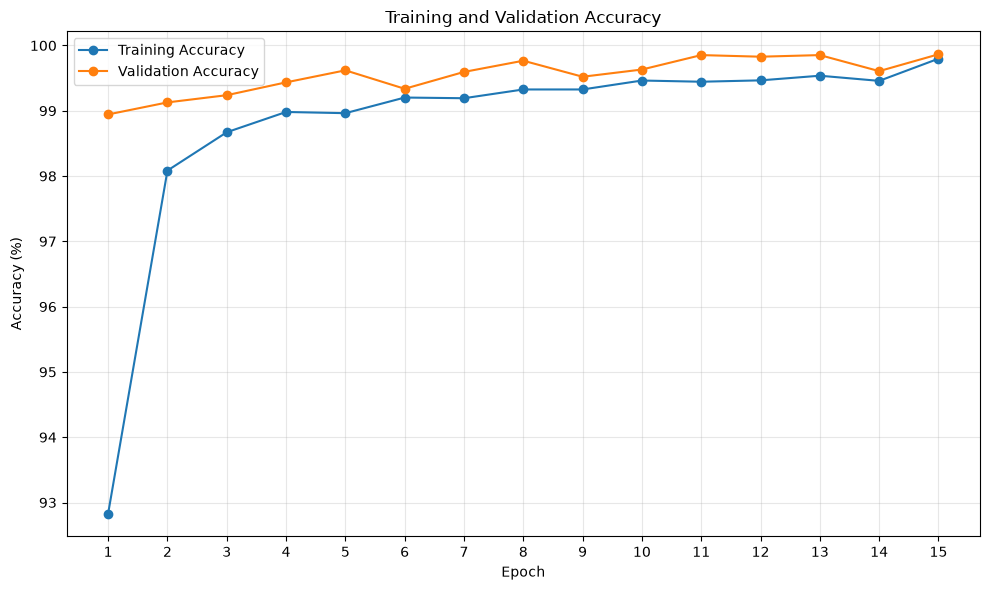

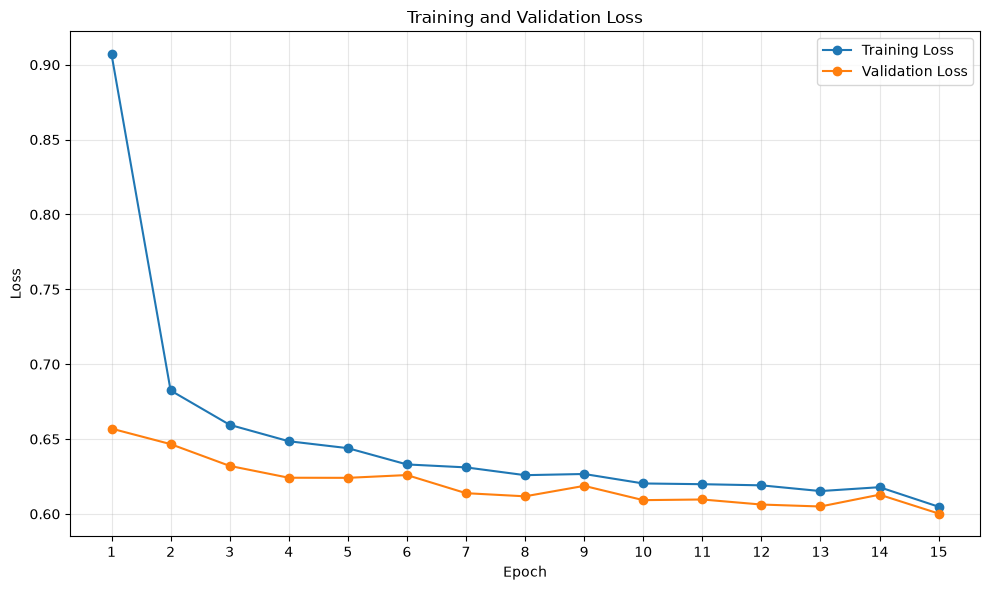


✓ Accuracy curve saved:
  training_validation_accuracy.png
✓ Loss curve saved:
  training_validation_loss.png
CELL 20 COMPLETE


In [23]:
# ============================================================
# CELL 20 — TRAINING CURVES
# ============================================================

import matplotlib.pyplot as plt

print("=" * 70)
print("GENERATING TRAINING CURVES")
print("=" * 70)

epochs = range(1, len(TRAIN_HISTORY["train_loss"]) + 1)

# ------------------------------------------------------------
# ACCURACY
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

plt.plot(
    epochs,
    [x * 100 for x in TRAIN_HISTORY["train_acc"]],
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    epochs,
    [x * 100 for x in TRAIN_HISTORY["val_acc"]],
    marker="o",
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Training and Validation Accuracy")
plt.xticks(list(epochs))
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig(
    "training_validation_accuracy.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ------------------------------------------------------------
# LOSS
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

plt.plot(
    epochs,
    TRAIN_HISTORY["train_loss"],
    marker="o",
    label="Training Loss"
)

plt.plot(
    epochs,
    TRAIN_HISTORY["val_loss"],
    marker="o",
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.xticks(list(epochs))
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig(
    "training_validation_loss.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print()
print("✓ Accuracy curve saved:")
print("  training_validation_accuracy.png")

print("✓ Loss curve saved:")
print("  training_validation_loss.png")

print("=" * 70)
print("CELL 20 COMPLETE")
print("=" * 70)

In [25]:
# ============================================================
# CHECK TEST_RESULTS STRUCTURE
# ============================================================

print("=" * 70)
print("TEST_RESULTS CONTENT")
print("=" * 70)

print("Type:", type(TEST_RESULTS))

if isinstance(TEST_RESULTS, dict):
    print("\nKeys:")
    for key in TEST_RESULTS.keys():
        value = TEST_RESULTS[key]

        try:
            length = len(value)
        except:
            length = "N/A"

        print(
            f"  {key!r:<30} "
            f"type={type(value).__name__:<15} "
            f"length={length}"
        )
else:
    print(TEST_RESULTS)

print("=" * 70)

TEST_RESULTS CONTENT
Type: <class 'dict'>

Keys:
  'y_true'                       type=ndarray         length=8143
  'y_pred'                       type=ndarray         length=8143
  'accuracy'                     type=float           length=N/A
  'classification_report'        type=str             length=3866
  'confusion_matrix'             type=ndarray         length=38
  'macro_precision'              type=float           length=N/A
  'macro_recall'                 type=float           length=N/A
  'macro_f1'                     type=float           length=N/A
  'weighted_precision'           type=float           length=N/A
  'weighted_recall'              type=float           length=N/A
  'weighted_f1'                  type=float           length=N/A
  'class_summary'                type=list            length=38


GENERATING FINAL CONFUSION MATRIX

Number of test samples : 8143
Number of predictions  : 8143
Confusion matrix shape : (38, 38)
Correct predictions    : 8132
Incorrect predictions  : 11
Test accuracy          : 99.8649%


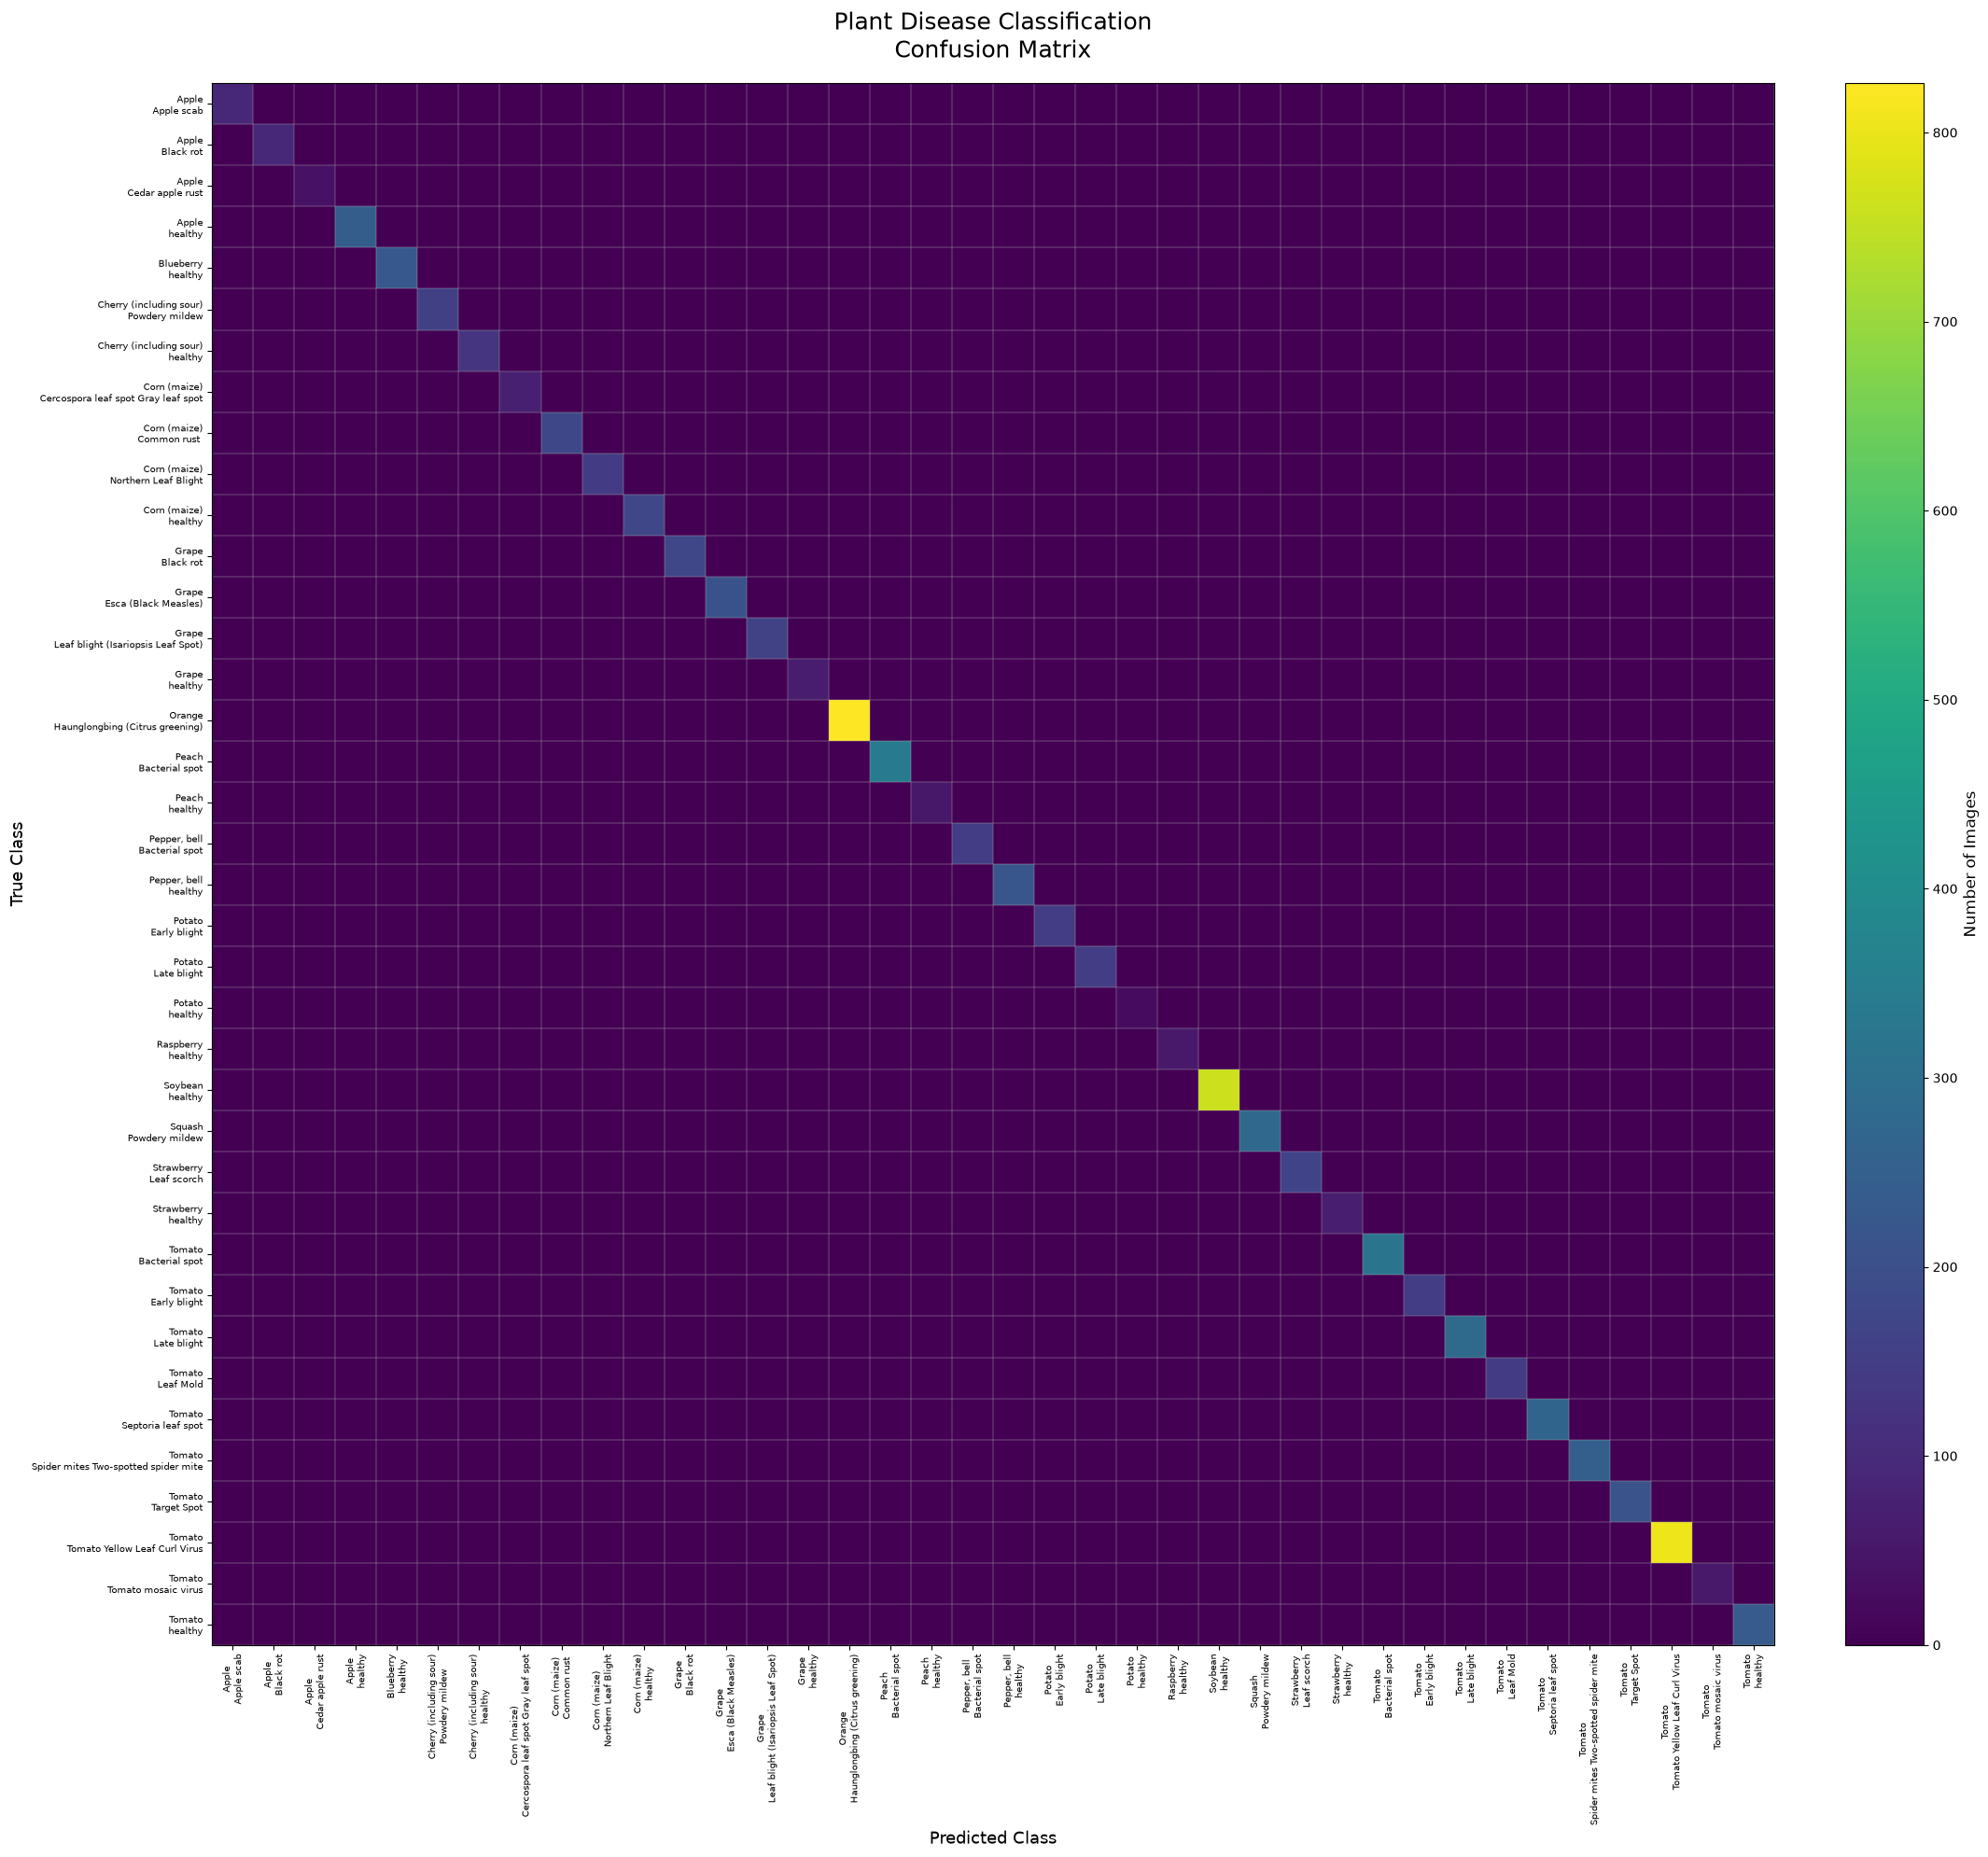


NON-ZERO CONFUSION MATRIX ERRORS
 7 | Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot      -> Corn_(maize)___Northern_Leaf_Blight                     | 3
 8 | Corn_(maize)___Common_rust_                             -> Corn_(maize)___Northern_Leaf_Blight                     | 1
 9 | Corn_(maize)___Northern_Leaf_Blight                     -> Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot      | 1
19 | Pepper,_bell___healthy                                  -> Strawberry___Leaf_scorch                                | 1
24 | Soybean___healthy                                       -> Corn_(maize)___healthy                                  | 1
24 | Soybean___healthy                                       -> Tomato___Late_blight                                    | 1
28 | Tomato___Bacterial_spot                                 -> Tomato___Target_Spot                                    | 1
29 | Tomato___Early_blight                                   -> Tomato___Septoria_leaf_spot       

In [26]:
# ============================================================
# CELL 21 — FINAL CONFUSION MATRIX VISUALIZATION
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

print("=" * 70)
print("GENERATING FINAL CONFUSION MATRIX")
print("=" * 70)

# ------------------------------------------------------------
# GET RESULTS FROM TEST_RESULTS
# ------------------------------------------------------------

y_true = np.asarray(TEST_RESULTS["y_true"])
y_pred = np.asarray(TEST_RESULTS["y_pred"])

cm = np.asarray(TEST_RESULTS["confusion_matrix"])

# ------------------------------------------------------------
# BASIC CHECKS
# ------------------------------------------------------------

print()
print("Number of test samples :", len(y_true))
print("Number of predictions  :", len(y_pred))
print("Confusion matrix shape :", cm.shape)

print(
    "Correct predictions    :",
    np.trace(cm)
)

print(
    "Incorrect predictions  :",
    cm.sum() - np.trace(cm)
)

print(
    "Test accuracy          :",
    f"{TEST_RESULTS['accuracy'] * 100:.4f}%"
)

# ------------------------------------------------------------
# CREATE READABLE CLASS NAMES
# ------------------------------------------------------------

short_names = []

for name in CLASS_NAMES:

    short_name = (
        name
        .replace("___", "\n")
        .replace("_", " ")
    )

    short_names.append(short_name)

# ------------------------------------------------------------
# PLOT CONFUSION MATRIX
# ------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(22, 20)
)

im = ax.imshow(cm)

ax.set_title(
    "Plant Disease Classification\nConfusion Matrix",
    fontsize=18,
    pad=20
)

ax.set_xlabel(
    "Predicted Class",
    fontsize=13
)

ax.set_ylabel(
    "True Class",
    fontsize=13
)

# ------------------------------------------------------------
# AXIS LABELS
# ------------------------------------------------------------

ax.set_xticks(
    np.arange(NUM_CLASSES)
)

ax.set_yticks(
    np.arange(NUM_CLASSES)
)

ax.set_xticklabels(
    short_names,
    rotation=90,
    fontsize=7
)

ax.set_yticklabels(
    short_names,
    fontsize=7
)

# ------------------------------------------------------------
# COLORBAR
# ------------------------------------------------------------

cbar = fig.colorbar(
    im,
    ax=ax,
    fraction=0.046,
    pad=0.04
)

cbar.set_label(
    "Number of Images",
    fontsize=12
)

# ------------------------------------------------------------
# GRID
# ------------------------------------------------------------

ax.set_xticks(
    np.arange(NUM_CLASSES + 1) - 0.5,
    minor=True
)

ax.set_yticks(
    np.arange(NUM_CLASSES + 1) - 0.5,
    minor=True
)

ax.grid(
    which="minor",
    linewidth=0.3
)

ax.tick_params(
    which="minor",
    bottom=False,
    left=False
)

plt.tight_layout()

# ------------------------------------------------------------
# SAVE
# ------------------------------------------------------------

plt.savefig(
    "final_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ------------------------------------------------------------
# PRINT ALL NON-ZERO ERRORS
# ------------------------------------------------------------

print()
print("=" * 70)
print("NON-ZERO CONFUSION MATRIX ERRORS")
print("=" * 70)

error_count = 0

for true_idx in range(NUM_CLASSES):

    for pred_idx in range(NUM_CLASSES):

        if true_idx != pred_idx:

            count = cm[true_idx, pred_idx]

            if count > 0:

                print(
                    f"{true_idx:2d} | "
                    f"{CLASS_NAMES[true_idx]:55s} -> "
                    f"{CLASS_NAMES[pred_idx]:55s} | "
                    f"{count}"
                )

                error_count += int(count)

print()
print("-" * 70)

print(
    f"Total off-diagonal errors: {error_count}"
)

print(
    f"Total correct predictions: {int(np.trace(cm))}"
)

print(
    f"Total test samples       : {int(cm.sum())}"
)

print()
print("✓ Confusion matrix saved:")
print("  final_confusion_matrix.png")

print("=" * 70)
print("CELL 21 COMPLETE")
print("=" * 70)

In [27]:
# ============================================================
# CELL 22A — CHECK INFERENCE PREPROCESSING
# ============================================================

print("=" * 70)
print("CHECKING DATASET PREPROCESSING")
print("=" * 70)

print("TEST_DATASET type:")
print(type(TEST_DATASET))

print()
print("TEST_DATASET attributes:")

for attr in [
    "transform",
    "transforms",
    "image_size",
]:
    if hasattr(TEST_DATASET, attr):
        print(f"\n{attr}:")
        print(getattr(TEST_DATASET, attr))

print()
print("=" * 70)
print("CELL 22A COMPLETE")
print("=" * 70)

CHECKING DATASET PREPROCESSING
TEST_DATASET type:
<class '__main__.PlantVillageDataset'>

TEST_DATASET attributes:

transform:
Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)

CELL 22A COMPLETE


In [28]:
# ============================================================
# CELL 22B — VERIFY MODEL INPUT / OUTPUT
# ============================================================

import torch

print("=" * 70)
print("VERIFYING MODEL INPUT / OUTPUT")
print("=" * 70)

# ------------------------------------------------------------
# MODEL DEVICE
# ------------------------------------------------------------

print("\nMODEL DEVICE:")
model_device = next(MODEL.parameters()).device
print(model_device)

print("\nEXPECTED DEVICE:")
print(DEVICE)

# ------------------------------------------------------------
# MODEL MODE
# ------------------------------------------------------------

print("\nMODEL MODE:")
print("Training mode:", MODEL.training)

MODEL.eval()

print("After MODEL.eval():", MODEL.training)

# ------------------------------------------------------------
# GET ONE TEST BATCH
# ------------------------------------------------------------

images, labels = next(iter(TEST_LOADER))

print("\nTEST BATCH:")
print("Images shape :", images.shape)
print("Images dtype :", images.dtype)
print("Labels shape :", labels.shape)
print("Labels dtype :", labels.dtype)

# ------------------------------------------------------------
# MOVE TO DEVICE
# ------------------------------------------------------------

images_device = images.to(
    DEVICE,
    non_blocking=True
)

labels_device = labels.to(
    DEVICE,
    non_blocking=True
)

# ------------------------------------------------------------
# FORWARD PASS
# ------------------------------------------------------------

with torch.inference_mode():

    if USE_AMP:

        with torch.autocast(
            device_type="cuda",
            dtype=torch.float16
        ):
            outputs = MODEL(images_device)

    else:

        outputs = MODEL(images_device)

# ------------------------------------------------------------
# OUTPUT CHECK
# ------------------------------------------------------------

print("\nMODEL OUTPUT:")
print("Output shape :", outputs.shape)
print("Output dtype :", outputs.dtype)

print("\nEXPECTED OUTPUT SHAPE:")
print(
    f"(batch_size, NUM_CLASSES) = "
    f"({images.shape[0]}, {NUM_CLASSES})"
)

# ------------------------------------------------------------
# PREDICTIONS
# ------------------------------------------------------------

predictions = outputs.argmax(dim=1)

print("\nPREDICTIONS:")
print("Prediction shape :", predictions.shape)
print("First 10 predictions:", predictions[:10].cpu().tolist())
print("First 10 true labels :", labels[:10].tolist())

# ------------------------------------------------------------
# SANITY CHECK
# ------------------------------------------------------------

assert images.ndim == 4
assert images.shape[1] == 3
assert images.shape[2] == 224
assert images.shape[3] == 224

assert outputs.ndim == 2
assert outputs.shape[1] == NUM_CLASSES

assert len(CLASS_NAMES) == NUM_CLASSES

print()
print("=" * 70)
print("✓ INPUT SHAPE VERIFIED")
print("✓ RGB CHANNELS VERIFIED")
print("✓ IMAGE SIZE VERIFIED: 224 × 224")
print("✓ MODEL OUTPUT DIMENSION VERIFIED")
print("✓ NUM_CLASSES VERIFIED")
print("✓ FORWARD PASS SUCCESSFUL")
print("=" * 70)

print("CELL 22B COMPLETE")
print("=" * 70)

VERIFYING MODEL INPUT / OUTPUT

MODEL DEVICE:
cuda:0

EXPECTED DEVICE:
cuda

MODEL MODE:
Training mode: False
After MODEL.eval(): False

TEST BATCH:
Images shape : torch.Size([32, 3, 224, 224])
Images dtype : torch.float32
Labels shape : torch.Size([32])
Labels dtype : torch.int64

MODEL OUTPUT:
Output shape : torch.Size([32, 38])
Output dtype : torch.float16

EXPECTED OUTPUT SHAPE:
(batch_size, NUM_CLASSES) = (32, 38)

PREDICTIONS:
Prediction shape : torch.Size([32])
First 10 predictions: [30, 30, 10, 7, 3, 5, 24, 33, 8, 28]
First 10 true labels : [30, 30, 10, 7, 3, 5, 24, 33, 8, 28]

✓ INPUT SHAPE VERIFIED
✓ RGB CHANNELS VERIFIED
✓ IMAGE SIZE VERIFIED: 224 × 224
✓ MODEL OUTPUT DIMENSION VERIFIED
✓ NUM_CLASSES VERIFIED
✓ FORWARD PASS SUCCESSFUL
CELL 22B COMPLETE


In [29]:
# ============================================================
# CELL 22C — VERIFY CLASS INDEX / CLASS NAME MAPPING
# ============================================================

print("=" * 70)
print("VERIFYING CLASS INDEX / CLASS NAME MAPPING")
print("=" * 70)

# ------------------------------------------------------------
# BASIC CHECKS
# ------------------------------------------------------------

print("\nCLASS INFORMATION:")
print("NUM_CLASSES :", NUM_CLASSES)
print("CLASS_NAMES :", len(CLASS_NAMES))

assert len(CLASS_NAMES) == NUM_CLASSES

# ------------------------------------------------------------
# PRINT COMPLETE MAPPING
# ------------------------------------------------------------

print("\nCLASS INDEX MAPPING:")
print("-" * 70)

for idx, class_name in enumerate(CLASS_NAMES):
    print(f"{idx:02d} -> {class_name}")

# ------------------------------------------------------------
# CHECK TRAINING DATA MAPPING
# ------------------------------------------------------------

print("\nDATASET CLASS INDICES:")

unique_train_indices = sorted(
    TRAIN_DF["class_index"].unique().tolist()
)

print(
    "Unique TRAIN_DF class indices:",
    unique_train_indices
)

assert unique_train_indices == list(range(NUM_CLASSES))

# ------------------------------------------------------------
# VERIFY EACH DATASET INDEX MATCHES CLASS_NAMES
# ------------------------------------------------------------

print("\nVERIFYING TRAIN_DF MAPPING:")

mapping_errors = []

for _, row in TRAIN_DF.iterrows():

    index = int(row["class_index"])
    class_name = row["class_name"]

    if CLASS_NAMES[index] != class_name:
        mapping_errors.append(
            {
                "class_index": index,
                "dataframe_class": class_name,
                "class_names_value": CLASS_NAMES[index]
            }
        )

print("Mapping errors:", len(mapping_errors))

assert len(mapping_errors) == 0

# ------------------------------------------------------------
# VERIFY VALIDATION DATA
# ------------------------------------------------------------

print("\nVERIFYING VAL_DF MAPPING:")

val_mapping_errors = []

for _, row in VAL_DF.iterrows():

    index = int(row["class_index"])
    class_name = row["class_name"]

    if CLASS_NAMES[index] != class_name:
        val_mapping_errors.append(
            {
                "class_index": index,
                "dataframe_class": class_name,
                "class_names_value": CLASS_NAMES[index]
            }
        )

print("Validation mapping errors:", len(val_mapping_errors))

assert len(val_mapping_errors) == 0

# ------------------------------------------------------------
# VERIFY TEST DATA
# ------------------------------------------------------------

print("\nVERIFYING TEST_DF MAPPING:")

test_mapping_errors = []

for _, row in TEST_DF.iterrows():

    index = int(row["class_index"])
    class_name = row["class_name"]

    if CLASS_NAMES[index] != class_name:
        test_mapping_errors.append(
            {
                "class_index": index,
                "dataframe_class": class_name,
                "class_names_value": CLASS_NAMES[index]
            }
        )

print("Test mapping errors:", len(test_mapping_errors))

assert len(test_mapping_errors) == 0

# ------------------------------------------------------------
# VERIFY TEST RESULTS MAPPING
# ------------------------------------------------------------

print("\nVERIFYING TEST RESULTS:")

y_true = np.asarray(TEST_RESULTS["y_true"])
y_pred = np.asarray(TEST_RESULTS["y_pred"])

print("y_true length:", len(y_true))
print("y_pred length:", len(y_pred))

assert len(y_true) == len(TEST_DF)
assert len(y_pred) == len(TEST_DF)

assert np.all(y_true >= 0)
assert np.all(y_true < NUM_CLASSES)

assert np.all(y_pred >= 0)
assert np.all(y_pred < NUM_CLASSES)

# ------------------------------------------------------------
# SAMPLE PREDICTION TRANSLATION
# ------------------------------------------------------------

print("\nSAMPLE PREDICTIONS:")
print("-" * 70)

for i in range(min(10, len(y_true))):

    true_index = int(y_true[i])
    pred_index = int(y_pred[i])

    true_name = CLASS_NAMES[true_index]
    pred_name = CLASS_NAMES[pred_index]

    status = "✓" if true_index == pred_index else "✗"

    print(
        f"{status} Sample {i:02d} | "
        f"True [{true_index:02d}] {true_name} | "
        f"Pred [{pred_index:02d}] {pred_name}"
    )

# ------------------------------------------------------------
# FINAL VERIFICATION
# ------------------------------------------------------------

print()
print("=" * 70)
print("✓ NUM_CLASSES MATCHES CLASS_NAMES")
print("✓ CLASS INDICES ARE CONTIGUOUS: 0 → 37")
print("✓ TRAIN CLASS MAPPING VERIFIED")
print("✓ VALIDATION CLASS MAPPING VERIFIED")
print("✓ TEST CLASS MAPPING VERIFIED")
print("✓ TEST RESULT INDICES VERIFIED")
print("✓ CLASS INDEX / NAME MAPPING IS CONSISTENT")
print("=" * 70)

print("CELL 22C COMPLETE")
print("=" * 70)

VERIFYING CLASS INDEX / CLASS NAME MAPPING

CLASS INFORMATION:
NUM_CLASSES : 38
CLASS_NAMES : 38

CLASS INDEX MAPPING:
----------------------------------------------------------------------
00 -> Apple___Apple_scab
01 -> Apple___Black_rot
02 -> Apple___Cedar_apple_rust
03 -> Apple___healthy
04 -> Blueberry___healthy
05 -> Cherry_(including_sour)___Powdery_mildew
06 -> Cherry_(including_sour)___healthy
07 -> Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot
08 -> Corn_(maize)___Common_rust_
09 -> Corn_(maize)___Northern_Leaf_Blight
10 -> Corn_(maize)___healthy
11 -> Grape___Black_rot
12 -> Grape___Esca_(Black_Measles)
13 -> Grape___Leaf_blight_(Isariopsis_Leaf_Spot)
14 -> Grape___healthy
15 -> Orange___Haunglongbing_(Citrus_greening)
16 -> Peach___Bacterial_spot
17 -> Peach___healthy
18 -> Pepper,_bell___Bacterial_spot
19 -> Pepper,_bell___healthy
20 -> Potato___Early_blight
21 -> Potato___Late_blight
22 -> Potato___healthy
23 -> Raspberry___healthy
24 -> Soybean___healthy
25 -> Squash

In [30]:
# ============================================================
# CELL 23 — FINAL MODEL PERFORMANCE SUMMARY
# ============================================================

import numpy as np

print("=" * 70)
print("FINAL MODEL PERFORMANCE SUMMARY")
print("=" * 70)

# ------------------------------------------------------------
# DATASET SUMMARY
# ------------------------------------------------------------

print("\nDATASET:")
print("-" * 70)

print(f"Training samples   : {len(TRAIN_DF):,}")
print(f"Validation samples : {len(VAL_DF):,}")
print(f"Test samples       : {len(TEST_DF):,}")
print(f"Total samples      : {len(TRAIN_DF) + len(VAL_DF) + len(TEST_DF):,}")
print(f"Number of classes  : {NUM_CLASSES}")

# ------------------------------------------------------------
# TRAINING SUMMARY
# ------------------------------------------------------------

print("\nTRAINING:")
print("-" * 70)

print(f"Epochs completed       : {len(TRAIN_HISTORY['train_loss'])}")
print(f"Best validation acc   : {BEST_VAL_ACC * 100:.4f}%")
print(f"Best validation loss   : {BEST_VAL_LOSS:.4f}")

# ------------------------------------------------------------
# TEST PERFORMANCE
# ------------------------------------------------------------

print("\nTEST PERFORMANCE:")
print("-" * 70)

test_accuracy = TEST_RESULTS["accuracy"]

print(f"Test accuracy         : {test_accuracy * 100:.4f}%")
print(f"Correct predictions   : {int(np.sum(y_true == y_pred)):,}")
print(f"Incorrect predictions : {int(np.sum(y_true != y_pred)):,}")
print(f"Total predictions     : {len(y_true):,}")

# ------------------------------------------------------------
# CLASSIFICATION METRICS
# ------------------------------------------------------------

print("\nCLASSIFICATION METRICS:")
print("-" * 70)

print(
    f"Macro Precision       : "
    f"{TEST_RESULTS['macro_precision']:.4f}"
)

print(
    f"Macro Recall          : "
    f"{TEST_RESULTS['macro_recall']:.4f}"
)

print(
    f"Macro F1              : "
    f"{TEST_RESULTS['macro_f1']:.4f}"
)

print(
    f"Weighted Precision    : "
    f"{TEST_RESULTS['weighted_precision']:.4f}"
)

print(
    f"Weighted Recall       : "
    f"{TEST_RESULTS['weighted_recall']:.4f}"
)

print(
    f"Weighted F1           : "
    f"{TEST_RESULTS['weighted_f1']:.4f}"
)

# ------------------------------------------------------------
# ERROR SUMMARY
# ------------------------------------------------------------

incorrect_mask = y_true != y_pred

print("\nERROR ANALYSIS:")
print("-" * 70)

print(
    f"Total errors          : "
    f"{int(incorrect_mask.sum())}"
)

print(
    f"Overall error rate    : "
    f"{incorrect_mask.mean() * 100:.4f}%"
)

# ------------------------------------------------------------
# PERFECT CLASSES
# ------------------------------------------------------------

print("\nCLASS PERFORMANCE:")
print("-" * 70)

perfect_classes = 0

for class_index in range(NUM_CLASSES):

    class_mask = y_true == class_index

    total = int(class_mask.sum())

    if total == 0:
        continue

    correct = int(
        np.sum(
            y_pred[class_mask] == class_index
        )
    )

    accuracy = correct / total

    if accuracy == 1.0:
        perfect_classes += 1

print(
    f"Classes with 100% test accuracy : "
    f"{perfect_classes}/{NUM_CLASSES}"
)

# ------------------------------------------------------------
# WORST PERFORMING CLASSES
# ------------------------------------------------------------

class_results = []

for class_index in range(NUM_CLASSES):

    class_mask = y_true == class_index

    total = int(class_mask.sum())

    if total == 0:
        continue

    correct = int(
        np.sum(
            y_pred[class_mask] == class_index
        )
    )

    wrong = total - correct
    accuracy = correct / total

    class_results.append(
        (
            class_index,
            CLASS_NAMES[class_index],
            total,
            correct,
            wrong,
            accuracy
        )
    )

class_results.sort(
    key=lambda x: x[5]
)

print("\nLOWEST-ACCURACY CLASSES:")
print("-" * 70)

for (
    class_index,
    class_name,
    total,
    correct,
    wrong,
    accuracy
) in class_results[:10]:

    print(
        f"{class_index:02d} | "
        f"{class_name:<55} | "
        f"{accuracy * 100:7.2f}% | "
        f"Wrong: {wrong}"
    )

# ------------------------------------------------------------
# CHECKPOINT
# ------------------------------------------------------------

import os

checkpoint_exists = os.path.exists(
    "best_plant_disease_model.pth"
)

print("\nMODEL CHECKPOINT:")
print("-" * 70)

print(
    "best_plant_disease_model.pth exists:",
    checkpoint_exists
)

assert checkpoint_exists

# ------------------------------------------------------------
# FINAL STATUS
# ------------------------------------------------------------

print()
print("=" * 70)
print("✓ DATASET SUMMARY VERIFIED")
print("✓ TRAINING RESULTS VERIFIED")
print("✓ TEST RESULTS VERIFIED")
print("✓ CLASSIFICATION METRICS VERIFIED")
print("✓ ERROR RATE CALCULATED")
print("✓ PER-CLASS PERFORMANCE VERIFIED")
print("✓ BEST MODEL CHECKPOINT VERIFIED")
print("=" * 70)

print("CELL 23 COMPLETE")
print("=" * 70)

FINAL MODEL PERFORMANCE SUMMARY

DATASET:
----------------------------------------------------------------------
Training samples   : 37,998
Validation samples : 8,143
Test samples       : 8,143
Total samples      : 54,284
Number of classes  : 38

TRAINING:
----------------------------------------------------------------------
Epochs completed       : 15
Best validation acc   : 99.8649%
Best validation loss   : 0.6003

TEST PERFORMANCE:
----------------------------------------------------------------------
Test accuracy         : 99.8649%
Correct predictions   : 8,132
Incorrect predictions : 11
Total predictions     : 8,143

CLASSIFICATION METRICS:
----------------------------------------------------------------------
Macro Precision       : 0.9981
Macro Recall          : 0.9981
Macro F1              : 0.9981
Weighted Precision    : 0.9987
Weighted Recall       : 0.9986
Weighted F1           : 0.9986

ERROR ANALYSIS:
---------------------------------------------------------------------

In [31]:
# ============================================================
# CELL 24 — XAI SETUP AND TARGET LAYER VERIFICATION
# ============================================================

import os
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

print("=" * 70)
print("XAI SETUP — TARGET LAYER VERIFICATION")
print("=" * 70)

# ------------------------------------------------------------
# VERIFY REQUIRED OBJECTS
# ------------------------------------------------------------

required_objects = [
    "MODEL",
    "TEST_DATASET",
    "TEST_LOADER",
    "TEST_RESULTS",
    "CLASS_NAMES",
    "NUM_CLASSES",
    "DEVICE"
]

print("\nChecking required objects:")

missing_objects = []

for name in required_objects:

    if name in globals():

        print(f"✓ {name}")

    else:

        print(f"✗ {name} NOT FOUND")
        missing_objects.append(name)

if len(missing_objects) > 0:

    raise RuntimeError(
        "Missing required objects: "
        + ", ".join(missing_objects)
    )

# ------------------------------------------------------------
# MODEL MODE
# ------------------------------------------------------------

MODEL.eval()

print("\nMODEL:")
print("Type :", type(MODEL).__name__)
print("Device :", next(MODEL.parameters()).device)
print("Training mode :", MODEL.training)

# ------------------------------------------------------------
# PRINT MODEL ARCHITECTURE
# ------------------------------------------------------------

print("\nMODEL ARCHITECTURE:")
print("-" * 70)

print(MODEL)

# ------------------------------------------------------------
# FIND CONVOLUTIONAL LAYERS
# ------------------------------------------------------------

print("\nCONVOLUTIONAL LAYERS:")
print("-" * 70)

conv_layers = []

for name, module in MODEL.named_modules():

    if isinstance(
        module,
        torch.nn.Conv2d
    ):

        conv_layers.append(
            (name, module)
        )

for idx, (name, module) in enumerate(conv_layers):

    print(
        f"{idx:03d} | "
        f"{name:50s} | "
        f"out_channels={module.out_channels}"
    )

print()
print(
    f"Total Conv2d layers found: "
    f"{len(conv_layers)}"
)

# ------------------------------------------------------------
# EFFICIENTNET TARGET LAYER
# ------------------------------------------------------------
#
# For torchvision EfficientNet models, the final convolutional
# feature representation is normally under:
#
# MODEL.features
#
# We select the final block of MODEL.features.
#
# This is preferable to selecting the classifier because
# Grad-CAM requires spatial feature maps.
# ------------------------------------------------------------

if hasattr(MODEL, "features"):

    print("\nMODEL.features detected.")

    print(
        "Number of feature blocks:",
        len(MODEL.features)
    )

    for idx, layer in enumerate(MODEL.features):

        print(
            f"Feature block {idx:02d}: "
            f"{type(layer).__name__}"
        )

    TARGET_LAYER = MODEL.features[-1]

    TARGET_LAYER_NAME = "MODEL.features[-1]"

else:

    raise RuntimeError(
        "MODEL does not contain a .features module. "
        "Target layer must be selected manually."
    )

print()
print("=" * 70)
print("SELECTED XAI TARGET LAYER")
print("=" * 70)

print("Target layer name :", TARGET_LAYER_NAME)
print("Target layer type :", type(TARGET_LAYER).__name__)
print("Target layer      :", TARGET_LAYER)

# ------------------------------------------------------------
# VERIFY TARGET LAYER OUTPUT SHAPE
# ------------------------------------------------------------

print()
print("=" * 70)
print("VERIFYING TARGET LAYER ACTIVATIONS")
print("=" * 70)

sample_images, sample_labels = next(
    iter(TEST_LOADER)
)

sample_images = sample_images[:2].to(
    DEVICE,
    non_blocking=True
)

activation_shape = None

def target_hook(module, inputs, output):

    global activation_shape

    activation_shape = tuple(
        output.shape
    )

hook_handle = TARGET_LAYER.register_forward_hook(
    target_hook
)

with torch.inference_mode():

    _ = MODEL(sample_images)

hook_handle.remove()

print(
    "Input shape :",
    tuple(sample_images.shape)
)

print(
    "Target activation shape :",
    activation_shape
)

# ------------------------------------------------------------
# FINAL VERIFICATION
# ------------------------------------------------------------

if activation_shape is None:

    raise RuntimeError(
        "Target layer did not produce activations."
    )

if len(activation_shape) != 4:

    raise RuntimeError(
        "Grad-CAM target must produce a 4D tensor "
        "(batch, channels, height, width). "
        f"Got: {activation_shape}"
    )

print()
print("=" * 70)
print("✓ XAI SETUP VERIFIED")
print("✓ MODEL AVAILABLE")
print("✓ TARGET CONVOLUTIONAL LAYER FOUND")
print("✓ SPATIAL FEATURE MAP VERIFIED")
print("✓ READY FOR GRAD-CAM")
print("=" * 70)
print("CELL 24 COMPLETE")
print("=" * 70)

XAI SETUP — TARGET LAYER VERIFICATION

Checking required objects:
✓ MODEL
✓ TEST_DATASET
✓ TEST_LOADER
✓ TEST_RESULTS
✓ CLASS_NAMES
✓ NUM_CLASSES
✓ DEVICE

MODEL:
Type : EfficientNet
Device : cuda:0
Training mode : False

MODEL ARCHITECTURE:
----------------------------------------------------------------------
EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): Squeeze

In [32]:
# ============================================================
# CELL 25 — GRAD-CAM IMPLEMENTATION
# ============================================================

import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import os

print("=" * 70)
print("GRAD-CAM IMPLEMENTATION")
print("=" * 70)

# ------------------------------------------------------------
# GRAD-CAM CLASS
# ------------------------------------------------------------

class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer

        self.activations = None
        self.gradients = None

        self.forward_handle = target_layer.register_forward_hook(
            self._forward_hook
        )

        self.backward_handle = target_layer.register_full_backward_hook(
            self._backward_hook
        )

    def _forward_hook(self, module, input, output):
        self.activations = output

    def _backward_hook(self, module, grad_input, grad_output):
        self.gradients = grad_output[0]

    def generate(self, input_tensor, target_class=None):

        self.model.eval()

        # Clear gradients
        self.model.zero_grad(set_to_none=True)

        # Forward pass
        output = self.model(input_tensor)

        if target_class is None:
            target_class = output.argmax(dim=1).item()

        # Target score
        score = output[:, target_class]

        # Backward
        score.backward()

        # Retrieve activations and gradients
        activations = self.activations
        gradients = self.gradients

        # Convert to float32 for stable XAI computation
        activations = activations.float()
        gradients = gradients.float()

        # Global average pooling over spatial dimensions
        weights = gradients.mean(dim=(2, 3), keepdim=True)

        # Weighted feature maps
        cam = (weights * activations).sum(dim=1)

        # ReLU
        cam = F.relu(cam)

        # Normalize each CAM
        cam_min = cam.amin(dim=(1, 2), keepdim=True)
        cam_max = cam.amax(dim=(1, 2), keepdim=True)

        cam = (cam - cam_min) / (
            cam_max - cam_min + 1e-8
        )

        return cam.detach(), output.detach(), target_class

    def remove_hooks(self):
        self.forward_handle.remove()
        self.backward_handle.remove()


# ------------------------------------------------------------
# INITIALIZE GRAD-CAM
# ------------------------------------------------------------

TARGET_LAYER = MODEL.features[-1]

gradcam = GradCAM(
    model=MODEL,
    target_layer=TARGET_LAYER
)

print("Model          :", type(MODEL).__name__)
print("Target layer   :", "MODEL.features[-1]")
print("Target type    :", type(TARGET_LAYER).__name__)

print("\n✓ Grad-CAM initialized")
print("✓ Forward hook registered")
print("✓ Backward hook registered")
print("✓ Ready for explanation generation")

print("=" * 70)
print("CELL 25 COMPLETE")
print("=" * 70)

GRAD-CAM IMPLEMENTATION
Model          : EfficientNet
Target layer   : MODEL.features[-1]
Target type    : Conv2dNormActivation

✓ Grad-CAM initialized
✓ Forward hook registered
✓ Backward hook registered
✓ Ready for explanation generation
CELL 25 COMPLETE


In [33]:
# ============================================================
# CELL 26 — GRAD-CAM SANITY CHECK
# ============================================================

print("=" * 70)
print("GRAD-CAM SANITY CHECK")
print("=" * 70)

# ------------------------------------------------------------
# GET ONE TEST SAMPLE
# ------------------------------------------------------------

sample_index = 0

image_tensor, true_label = TEST_DATASET[sample_index]

input_tensor = image_tensor.unsqueeze(0).to(DEVICE)

true_label = int(true_label)

# ------------------------------------------------------------
# GENERATE GRAD-CAM
# ------------------------------------------------------------

cam, output, predicted_class = gradcam.generate(
    input_tensor,
    target_class=None
)

predicted_class = int(predicted_class)

# ------------------------------------------------------------
# CALCULATE CONFIDENCE
# ------------------------------------------------------------

probabilities = torch.softmax(
    output.float(),
    dim=1
)

confidence = probabilities[0, predicted_class].item()

# ------------------------------------------------------------
# RESULTS
# ------------------------------------------------------------

print("Sample index     :", sample_index)

print(
    "True class index :",
    true_label
)

print(
    "True class       :",
    CLASS_NAMES[true_label]
)

print(
    "Predicted index  :",
    predicted_class
)

print(
    "Predicted class  :",
    CLASS_NAMES[predicted_class]
)

print(
    "Confidence       :",
    f"{confidence:.6f}"
)

# ------------------------------------------------------------
# VERIFY CAM
# ------------------------------------------------------------

cam_np = cam[0].cpu().numpy()

print("\nCAM shape        :", tuple(cam_np.shape))
print("CAM min          :", float(cam_np.min()))
print("CAM max          :", float(cam_np.max()))
print("CAM mean         :", float(cam_np.mean()))

# ------------------------------------------------------------
# ASSERTIONS
# ------------------------------------------------------------

assert cam_np.ndim == 2
assert cam_np.shape == (7, 7)
assert np.isfinite(cam_np).all()

print("\n✓ CAM generated successfully")
print("✓ CAM spatial resolution = 7 × 7")
print("✓ CAM contains finite values")
print("✓ Grad-CAM sanity check passed")

print("=" * 70)
print("CELL 26 COMPLETE")
print("=" * 70)

GRAD-CAM SANITY CHECK
Sample index     : 0
True class index : 30
True class       : Tomato___Late_blight
Predicted index  : 30
Predicted class  : Tomato___Late_blight
Confidence       : 0.894447

CAM shape        : (7, 7)
CAM min          : 0.0
CAM max          : 0.9999999403953552
CAM mean         : 0.31724685430526733

✓ CAM generated successfully
✓ CAM spatial resolution = 7 × 7
✓ CAM contains finite values
✓ Grad-CAM sanity check passed
CELL 26 COMPLETE


In [34]:
# ============================================================
# CELL 27 — IMAGE DE-NORMALIZATION FOR XAI VISUALIZATION
# ============================================================

print("=" * 70)
print("PREPARING IMAGE FOR XAI VISUALIZATION")
print("=" * 70)

IMAGENET_MEAN = np.array(
    [0.485, 0.456, 0.406],
    dtype=np.float32
)

IMAGENET_STD = np.array(
    [0.229, 0.224, 0.225],
    dtype=np.float32
)


def tensor_to_image(tensor):
    """
    Convert ImageNet-normalized CHW tensor
    back to displayable RGB image.
    """

    image = tensor.detach().cpu().numpy()

    # CHW -> HWC
    image = np.transpose(image, (1, 2, 0))

    # Reverse ImageNet normalization
    image = image * IMAGENET_STD + IMAGENET_MEAN

    # Valid RGB range
    image = np.clip(image, 0, 1)

    return image


# ------------------------------------------------------------
# CONVERT CURRENT SAMPLE
# ------------------------------------------------------------

original_image = tensor_to_image(image_tensor)

print("Image shape :", original_image.shape)
print("Image dtype :", original_image.dtype)
print(
    "Image range :",
    original_image.min(),
    "→",
    original_image.max()
)

# ------------------------------------------------------------
# VERIFICATION
# ------------------------------------------------------------

assert original_image.shape == (224, 224, 3)
assert np.isfinite(original_image).all()

print("\n✓ De-normalization successful")
print("✓ RGB visualization image prepared")
print("✓ Image dimensions verified: 224 × 224 × 3")

print("=" * 70)
print("CELL 27 COMPLETE")
print("=" * 70)

PREPARING IMAGE FOR XAI VISUALIZATION
Image shape : (224, 224, 3)
Image dtype : float32
Image range : 0.0 → 0.972549

✓ De-normalization successful
✓ RGB visualization image prepared
✓ Image dimensions verified: 224 × 224 × 3
CELL 27 COMPLETE


PUBLICATION-QUALITY GRAD-CAM VISUALIZATION

----------------------------------------------------------------------
GRAD-CAM RESULT
----------------------------------------------------------------------
Sample index       : 0
True class index   : 30
True class         : Tomato___Late_blight
Predicted index    : 30
Predicted class    : Tomato___Late_blight
Confidence         : 0.894447
Correct prediction : True

CAM shape          : (7, 7)
CAM min            : 0.0
CAM max            : 1.0
CAM mean           : 0.31724685430526733
Grad-CAM target    : 30


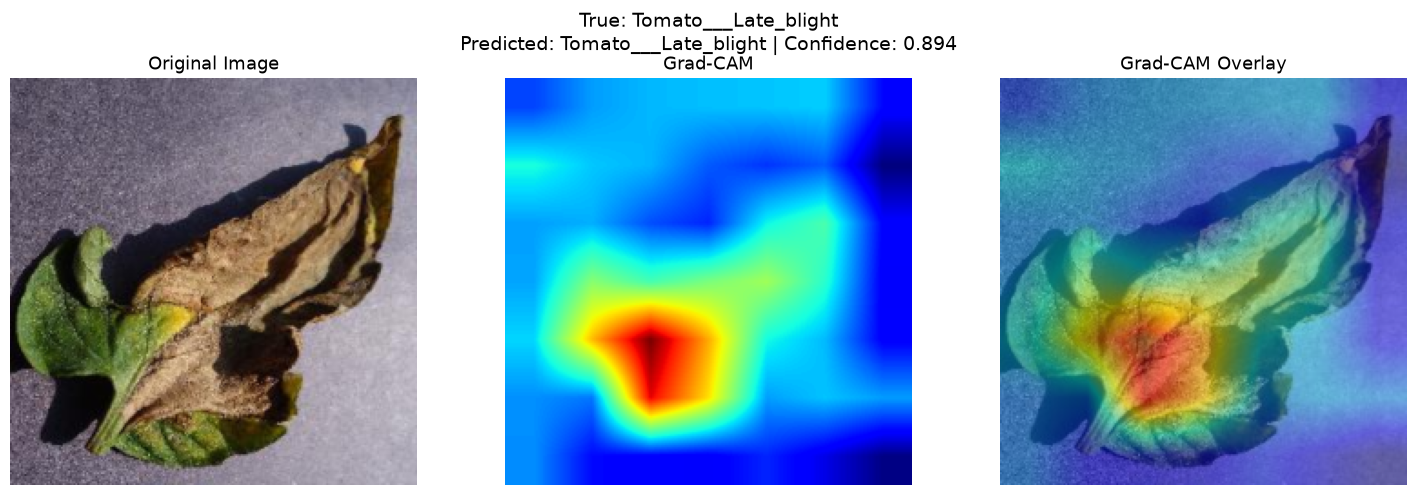


Saved to: c:\Users\cscpr\Downloads\random 1\XAI_Results\sample_0000_Tomato___Late_blight_pred_Tomato___Late_blight.png

✓ GRAD-CAM GENERATED SUCCESSFULLY
✓ TUPLE OUTPUT HANDLED
✓ CUDA CAM CONVERTED TO NUMPY
✓ CAM SHAPE PROCESSED
✓ HEATMAP GENERATED
✓ OVERLAY GENERATED
✓ 300 DPI FIGURE SAVED
CELL 28 COMPLETE


In [39]:
# ============================================================
# CELL 28 — PUBLICATION-QUALITY GRAD-CAM VISUALIZATION
# CORRECTED FOR TUPLE OUTPUT
# ============================================================

import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import torch

print("=" * 70)
print("PUBLICATION-QUALITY GRAD-CAM VISUALIZATION")
print("=" * 70)

# ------------------------------------------------------------
# OUTPUT DIRECTORY
# ------------------------------------------------------------

XAI_DIR = os.path.join(
    os.getcwd(),
    "XAI_Results"
)

os.makedirs(
    XAI_DIR,
    exist_ok=True
)

# ------------------------------------------------------------
# GRAD-CAM VISUALIZATION
# ------------------------------------------------------------

def generate_gradcam_visualization(
    sample_index,
    save_path=None,
    alpha=0.45,
    show_plot=True
):

    MODEL.eval()

    # --------------------------------------------------------
    # GET SAMPLE
    # --------------------------------------------------------

    image_tensor, true_label = TEST_DATASET[
        sample_index
    ]

    input_tensor = (
        image_tensor
        .unsqueeze(0)
        .to(DEVICE)
    )

    # --------------------------------------------------------
    # FORWARD PASS
    # --------------------------------------------------------

    MODEL.zero_grad(
        set_to_none=True
    )

    output = MODEL(
        input_tensor
    )

    probabilities = torch.softmax(
        output.float(),
        dim=1
    )

    predicted_index = int(
        torch.argmax(
            probabilities,
            dim=1
        ).item()
    )

    confidence = float(
        probabilities[
            0,
            predicted_index
        ].item()
    )

    true_index = int(
        true_label
    )

    # --------------------------------------------------------
    # GENERATE GRAD-CAM
    # --------------------------------------------------------

    gradcam_result = gradcam.generate(
        input_tensor=input_tensor,
        target_class=predicted_index
    )

    # --------------------------------------------------------
    # IMPORTANT:
    # gradcam.generate() RETURNS:
    #
    # (
    #     CAM,
    #     LOGITS,
    #     TARGET_CLASS
    # )
    # --------------------------------------------------------

    if isinstance(
        gradcam_result,
        tuple
    ):

        cam = gradcam_result[0]

        gradcam_logits = gradcam_result[1]

        gradcam_target = gradcam_result[2]

    else:

        cam = gradcam_result

        gradcam_logits = None

        gradcam_target = predicted_index

    # --------------------------------------------------------
    # CONVERT CAM CUDA TENSOR -> CPU NUMPY
    # --------------------------------------------------------

    if torch.is_tensor(cam):

        cam = (
            cam.detach()
               .float()
               .cpu()
               .numpy()
        )

    else:

        cam = np.asarray(
            cam,
            dtype=np.float32
        )

    # --------------------------------------------------------
    # REMOVE BATCH / CHANNEL DIMENSIONS
    # --------------------------------------------------------

    cam = np.squeeze(
        cam
    )

    # --------------------------------------------------------
    # CLEAN CAM
    # --------------------------------------------------------

    cam = np.nan_to_num(
        cam,
        nan=0.0,
        posinf=0.0,
        neginf=0.0
    )

    # --------------------------------------------------------
    # NORMALIZE CAM
    # --------------------------------------------------------

    if cam.max() > cam.min():

        cam = (
            cam - cam.min()
        ) / (
            cam.max() - cam.min()
        )

    else:

        cam = np.zeros_like(
            cam
        )

    # --------------------------------------------------------
    # PREPARE ORIGINAL IMAGE
    # --------------------------------------------------------

    img = (
        image_tensor
        .detach()
        .cpu()
        .numpy()
    )

    # CHW -> HWC

    img = np.transpose(
        img,
        (1, 2, 0)
    )

    # --------------------------------------------------------
    # DE-NORMALIZE
    # --------------------------------------------------------

    mean = np.array(
        [0.485, 0.456, 0.406],
        dtype=np.float32
    )

    std = np.array(
        [0.229, 0.224, 0.225],
        dtype=np.float32
    )

    img = (
        img * std
        + mean
    )

    img = np.clip(
        img,
        0,
        1
    )

    # --------------------------------------------------------
    # RESIZE CAM
    # --------------------------------------------------------

    cam_resized = cv2.resize(
        cam,
        (
            img.shape[1],
            img.shape[0]
        ),
        interpolation=cv2.INTER_LINEAR
    )

    # --------------------------------------------------------
    # CREATE HEATMAP
    # --------------------------------------------------------

    heatmap_uint8 = np.uint8(
        255 * cam_resized
    )

    heatmap = cv2.applyColorMap(
        heatmap_uint8,
        cv2.COLORMAP_JET
    )

    # BGR -> RGB

    heatmap = cv2.cvtColor(
        heatmap,
        cv2.COLOR_BGR2RGB
    )

    heatmap = (
        heatmap.astype(
            np.float32
        ) / 255.0
    )

    # --------------------------------------------------------
    # CREATE OVERLAY
    # --------------------------------------------------------

    overlay = (
        (1 - alpha) * img
        + alpha * heatmap
    )

    overlay = np.clip(
        overlay,
        0,
        1
    )

    # --------------------------------------------------------
    # CLASS INFORMATION
    # --------------------------------------------------------

    true_name = CLASS_NAMES[
        true_index
    ]

    pred_name = CLASS_NAMES[
        predicted_index
    ]

    correct = (
        true_index
        == predicted_index
    )

    # --------------------------------------------------------
    # PRINT INFORMATION
    # --------------------------------------------------------

    print()
    print("-" * 70)
    print("GRAD-CAM RESULT")
    print("-" * 70)

    print(
        "Sample index       :",
        sample_index
    )

    print(
        "True class index   :",
        true_index
    )

    print(
        "True class         :",
        true_name
    )

    print(
        "Predicted index    :",
        predicted_index
    )

    print(
        "Predicted class    :",
        pred_name
    )

    print(
        "Confidence         :",
        f"{confidence:.6f}"
    )

    print(
        "Correct prediction :",
        correct
    )

    print()

    print(
        "CAM shape          :",
        cam.shape
    )

    print(
        "CAM min            :",
        float(cam.min())
    )

    print(
        "CAM max            :",
        float(cam.max())
    )

    print(
        "CAM mean           :",
        float(cam.mean())
    )

    print(
        "Grad-CAM target    :",
        gradcam_target
    )

    # --------------------------------------------------------
    # FIGURE
    # --------------------------------------------------------

    fig, axes = plt.subplots(
        1,
        3,
        figsize=(15, 5)
    )

    # Original

    axes[0].imshow(
        img
    )

    axes[0].set_title(
        "Original Image",
        fontsize=13
    )

    axes[0].axis(
        "off"
    )

    # CAM

    axes[1].imshow(
        cam_resized,
        cmap="jet"
    )

    axes[1].set_title(
        "Grad-CAM",
        fontsize=13
    )

    axes[1].axis(
        "off"
    )

    # Overlay

    axes[2].imshow(
        overlay
    )

    axes[2].set_title(
        "Grad-CAM Overlay",
        fontsize=13
    )

    axes[2].axis(
        "off"
    )

    fig.suptitle(
        f"True: {true_name}\n"
        f"Predicted: {pred_name} | "
        f"Confidence: {confidence:.3f}",
        fontsize=14
    )

    plt.tight_layout()

    # --------------------------------------------------------
    # SAVE
    # --------------------------------------------------------

    if save_path is None:

        safe_true = (
            true_name
            .replace(
                "/",
                "_"
            )
            .replace(
                "\\",
                "_"
            )
        )

        safe_pred = (
            pred_name
            .replace(
                "/",
                "_"
            )
            .replace(
                "\\",
                "_"
            )
        )

        save_path = os.path.join(
            XAI_DIR,
            f"sample_{sample_index:04d}_"
            f"{safe_true}_"
            f"pred_{safe_pred}.png"
        )

    fig.savefig(
        save_path,
        dpi=300,
        bbox_inches="tight"
    )

    if show_plot:

        plt.show()

    else:

        plt.close(
            fig
        )

    print()
    print(
        "Saved to:",
        save_path
    )

    # --------------------------------------------------------
    # RETURN
    # --------------------------------------------------------

    return {
        "sample_index":
            sample_index,

        "true_index":
            true_index,

        "predicted_index":
            predicted_index,

        "true_class":
            true_name,

        "predicted_class":
            pred_name,

        "confidence":
            confidence,

        "cam":
            cam,

        "original":
            img,

        "heatmap":
            heatmap,

        "overlay":
            overlay,

        "save_path":
            save_path
    }


# ------------------------------------------------------------
# RUN SAMPLE 0
# ------------------------------------------------------------

xai_result_0 = generate_gradcam_visualization(
    sample_index=0,
    show_plot=True
)

# ------------------------------------------------------------
# COMPLETION
# ------------------------------------------------------------

print()
print("=" * 70)
print("✓ GRAD-CAM GENERATED SUCCESSFULLY")
print("✓ TUPLE OUTPUT HANDLED")
print("✓ CUDA CAM CONVERTED TO NUMPY")
print("✓ CAM SHAPE PROCESSED")
print("✓ HEATMAP GENERATED")
print("✓ OVERLAY GENERATED")
print("✓ 300 DPI FIGURE SAVED")
print("=" * 70)

print(
    "CELL 28 COMPLETE"
)

In [40]:
# ============================================================
# CELL 29 — GRAD-CAM FOR ALL MISCLASSIFIED TEST IMAGES
# ============================================================

import pandas as pd
import os

print("=" * 70)
print("GENERATING GRAD-CAM FOR MISCLASSIFIED TEST IMAGES")
print("=" * 70)

# ------------------------------------------------------------
# LOAD MISCLASSIFIED INDICES
# ------------------------------------------------------------

y_true = TEST_RESULTS["y_true"]
y_pred = TEST_RESULTS["y_pred"]

misclassified_indices = [
    i for i, (t, p) in enumerate(zip(y_true, y_pred))
    if t != p
]

print()
print("Number of misclassified samples:", len(misclassified_indices))
print("Indices:", misclassified_indices)

# ------------------------------------------------------------
# OUTPUT DIRECTORY
# ------------------------------------------------------------

MIS_XAI_DIR = os.path.join(
    XAI_DIR,
    "Misclassified"
)

os.makedirs(
    MIS_XAI_DIR,
    exist_ok=True
)

# ------------------------------------------------------------
# GENERATE EXPLANATIONS
# ------------------------------------------------------------

mis_xai_records = []

for count, idx in enumerate(misclassified_indices, start=1):

    print()
    print("=" * 70)
    print(
        f"Processing {count}/{len(misclassified_indices)} "
        f"(test index {idx})"
    )
    print("=" * 70)

    result = generate_gradcam_visualization(
        sample_index=idx,
        show_plot=False
    )

    mis_xai_records.append({
        "test_index": idx,
        "true_class": result["true_class"],
        "predicted_class": result["predicted_class"],
        "confidence": result["confidence"],
        "gradcam_path": result["save_path"]
    })

# ------------------------------------------------------------
# SAVE SUMMARY
# ------------------------------------------------------------

MIS_XAI_DF = pd.DataFrame(mis_xai_records)

summary_path = os.path.join(
    MIS_XAI_DIR,
    "misclassified_gradcam_summary.csv"
)

MIS_XAI_DF.to_csv(
    summary_path,
    index=False
)

print()
print("=" * 70)
print("MISCLASSIFIED GRAD-CAM GENERATION COMPLETE")
print("=" * 70)

print("Total explanations generated:", len(MIS_XAI_DF))
print("Images saved in:")
print(MIS_XAI_DIR)

print()
print("Summary CSV:")
print(summary_path)

print()
print(MIS_XAI_DF.to_string(index=False))

print("=" * 70)
print("CELL 29 COMPLETE")
print("=" * 70)

GENERATING GRAD-CAM FOR MISCLASSIFIED TEST IMAGES

Number of misclassified samples: 11
Indices: [153, 746, 867, 2349, 3522, 3571, 4748, 5092, 5708, 5779, 6416]

Processing 1/11 (test index 153)

----------------------------------------------------------------------
GRAD-CAM RESULT
----------------------------------------------------------------------
Sample index       : 153
True class index   : 29
True class         : Tomato___Early_blight
Predicted index    : 32
Predicted class    : Tomato___Septoria_leaf_spot
Confidence         : 0.371403
Correct prediction : False

CAM shape          : (7, 7)
CAM min            : 0.0
CAM max            : 1.0
CAM mean           : 0.5293512344360352
Grad-CAM target    : 32

Saved to: c:\Users\cscpr\Downloads\random 1\XAI_Results\sample_0153_Tomato___Early_blight_pred_Tomato___Septoria_leaf_spot.png

Processing 2/11 (test index 746)

----------------------------------------------------------------------
GRAD-CAM RESULT
--------------------------------

QUANTITATIVE XAI ERROR ANALYSIS

Loaded misclassified XAI records: 11

----------------------------------------------------------------------
ERROR CONFIDENCE ANALYSIS
----------------------------------------------------------------------
Total test samples          : 8143
Total misclassified        : 11
Overall error rate         : 0.1351%
Mean error confidence      : 0.7323
Median error confidence    : 0.8726
Minimum error confidence   : 0.3714
Maximum error confidence   : 0.9572

----------------------------------------------------------------------
CONFIDENCE DISTRIBUTION AMONG ERRORS
----------------------------------------------------------------------
Very high (>=90%)         :  3
High (75-90%)             :  4
Moderate (50-75%)         :  1
Low (<50%)                :  3

----------------------------------------------------------------------
MOST FREQUENT CONFUSION PAIRS
----------------------------------------------------------------------
 3 | Corn_(maize)___Cercospora_leaf_

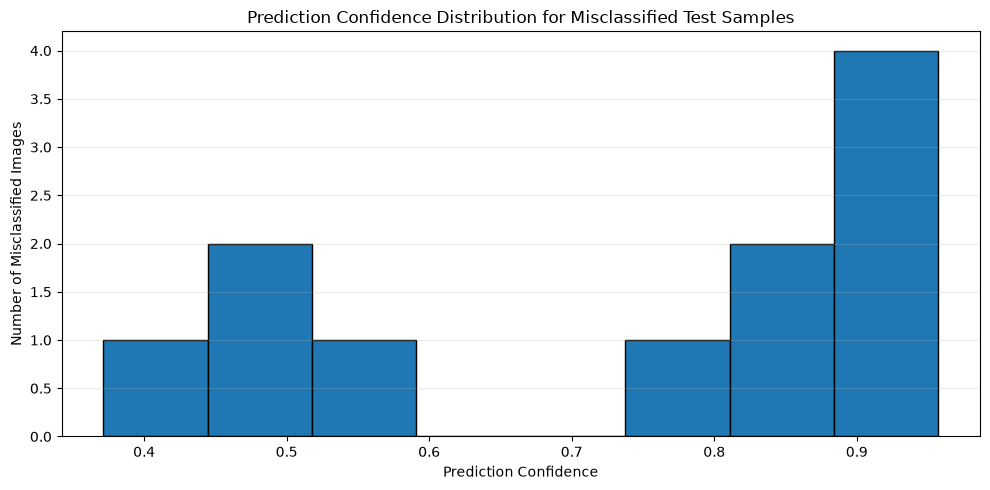


XAI ERROR ANALYSIS COMPLETE

Files generated:

1. Full XAI error table:
c:\Users\cscpr\Downloads\random 1\XAI_Results\Misclassified\quantitative_xai_error_analysis.csv

2. Confusion-pair analysis:
c:\Users\cscpr\Downloads\random 1\XAI_Results\Misclassified\xai_confusion_pairs.csv

3. Confidence distribution figure:
c:\Users\cscpr\Downloads\random 1\XAI_Results\Misclassified\misclassification_confidence_distribution.png

✓ Misclassification confidence analyzed
✓ Confusion pairs analyzed
✓ High-confidence errors identified
✓ Publication-ready CSV tables generated
✓ Confidence distribution figure generated

CELL 30 COMPLETE


In [41]:
# ============================================================
# CELL 30 — QUANTITATIVE XAI ERROR ANALYSIS
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("=" * 70)
print("QUANTITATIVE XAI ERROR ANALYSIS")
print("=" * 70)

# ------------------------------------------------------------
# LOAD MISCLASSIFICATION SUMMARY
# ------------------------------------------------------------

if "MIS_XAI_DF" not in globals():
    mis_summary_path = os.path.join(
        MIS_XAI_DIR,
        "misclassified_gradcam_summary.csv"
    )

    MIS_XAI_DF = pd.read_csv(mis_summary_path)

print()
print("Loaded misclassified XAI records:", len(MIS_XAI_DF))

# ------------------------------------------------------------
# BASIC ERROR STATISTICS
# ------------------------------------------------------------

total_test = len(TEST_RESULTS["y_true"])
total_errors = len(MIS_XAI_DF)

error_rate = (total_errors / total_test) * 100

mean_error_confidence = MIS_XAI_DF["confidence"].mean()
median_error_confidence = MIS_XAI_DF["confidence"].median()
max_error_confidence = MIS_XAI_DF["confidence"].max()
min_error_confidence = MIS_XAI_DF["confidence"].min()

print()
print("-" * 70)
print("ERROR CONFIDENCE ANALYSIS")
print("-" * 70)

print(f"Total test samples          : {total_test}")
print(f"Total misclassified        : {total_errors}")
print(f"Overall error rate         : {error_rate:.4f}%")
print(f"Mean error confidence      : {mean_error_confidence:.4f}")
print(f"Median error confidence    : {median_error_confidence:.4f}")
print(f"Minimum error confidence   : {min_error_confidence:.4f}")
print(f"Maximum error confidence   : {max_error_confidence:.4f}")

# ------------------------------------------------------------
# ADD CONFIDENCE CATEGORY
# ------------------------------------------------------------

def confidence_category(conf):
    if conf >= 0.90:
        return "Very high (>=90%)"
    elif conf >= 0.75:
        return "High (75-90%)"
    elif conf >= 0.50:
        return "Moderate (50-75%)"
    else:
        return "Low (<50%)"

MIS_XAI_DF["confidence_category"] = (
    MIS_XAI_DF["confidence"]
    .apply(confidence_category)
)

# ------------------------------------------------------------
# CONFIDENCE DISTRIBUTION
# ------------------------------------------------------------

confidence_counts = (
    MIS_XAI_DF["confidence_category"]
    .value_counts()
)

print()
print("-" * 70)
print("CONFIDENCE DISTRIBUTION AMONG ERRORS")
print("-" * 70)

for category in [
    "Very high (>=90%)",
    "High (75-90%)",
    "Moderate (50-75%)",
    "Low (<50%)"
]:
    count = confidence_counts.get(category, 0)

    print(
        f"{category:<25} : "
        f"{count:2d}"
    )

# ------------------------------------------------------------
# CONFUSION PAIRS
# ------------------------------------------------------------

pair_counts = (
    MIS_XAI_DF
    .groupby(
        ["true_class", "predicted_class"],
        as_index=False
    )
    .size()
    .rename(columns={"size": "error_count"})
    .sort_values(
        "error_count",
        ascending=False
    )
)

print()
print("-" * 70)
print("MOST FREQUENT CONFUSION PAIRS")
print("-" * 70)

for _, row in pair_counts.iterrows():

    print(
        f"{int(row['error_count']):2d} | "
        f"{row['true_class']} "
        f"-> "
        f"{row['predicted_class']}"
    )

# ------------------------------------------------------------
# HIGH-CONFIDENCE ERRORS
# ------------------------------------------------------------

high_conf_errors = (
    MIS_XAI_DF[
        MIS_XAI_DF["confidence"] >= 0.75
    ]
    .sort_values(
        "confidence",
        ascending=False
    )
)

print()
print("-" * 70)
print("HIGH-CONFIDENCE MISCLASSIFICATIONS (>=75%)")
print("-" * 70)

print(
    high_conf_errors[
        [
            "test_index",
            "true_class",
            "predicted_class",
            "confidence"
        ]
    ].to_string(index=False)
)

# ------------------------------------------------------------
# SAVE FULL ANALYSIS TABLE
# ------------------------------------------------------------

analysis_path = os.path.join(
    MIS_XAI_DIR,
    "quantitative_xai_error_analysis.csv"
)

MIS_XAI_DF.to_csv(
    analysis_path,
    index=False
)

# ------------------------------------------------------------
# SAVE CONFUSION-PAIR TABLE
# ------------------------------------------------------------

pair_path = os.path.join(
    MIS_XAI_DIR,
    "xai_confusion_pairs.csv"
)

pair_counts.to_csv(
    pair_path,
    index=False
)

# ------------------------------------------------------------
# CONFIDENCE PLOT
# ------------------------------------------------------------

plt.figure(figsize=(10, 5))

plt.hist(
    MIS_XAI_DF["confidence"],
    bins=8,
    edgecolor="black"
)

plt.xlabel("Prediction Confidence")
plt.ylabel("Number of Misclassified Images")
plt.title(
    "Prediction Confidence Distribution "
    "for Misclassified Test Samples"
)

plt.grid(
    axis="y",
    alpha=0.25
)

plt.tight_layout()

confidence_plot_path = os.path.join(
    MIS_XAI_DIR,
    "misclassification_confidence_distribution.png"
)

plt.savefig(
    confidence_plot_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

# ------------------------------------------------------------
# FINAL REPORT
# ------------------------------------------------------------

print()
print("=" * 70)
print("XAI ERROR ANALYSIS COMPLETE")
print("=" * 70)

print()
print("Files generated:")
print()
print("1. Full XAI error table:")
print(analysis_path)

print()
print("2. Confusion-pair analysis:")
print(pair_path)

print()
print("3. Confidence distribution figure:")
print(confidence_plot_path)

print()
print("✓ Misclassification confidence analyzed")
print("✓ Confusion pairs analyzed")
print("✓ High-confidence errors identified")
print("✓ Publication-ready CSV tables generated")
print("✓ Confidence distribution figure generated")

print()
print("=" * 70)
print("CELL 30 COMPLETE")
print("=" * 70)

CREATING PUBLICATION-QUALITY XAI COMPARISON FIGURE

SELECTED HIGH-CONFIDENCE ERRORS:
----------------------------------------------------------------------
Sample 5092: Corn_(maize)___Northern_Leaf_Blight -> Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot (confidence=0.9572)
Sample 746: Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot -> Corn_(maize)___Northern_Leaf_Blight (confidence=0.9337)
Sample 2349: Corn_(maize)___Common_rust_ -> Corn_(maize)___Northern_Leaf_Blight (confidence=0.9186)

SELECTED CORRECT EXAMPLES:
----------------------------------------------------------------------
Sample 41: Corn_(maize)___Northern_Leaf_Blight
Sample 65: Tomato___Early_blight
Sample 0: Tomato___Late_blight

Generating Grad-CAM for correct sample 41...

----------------------------------------------------------------------
GRAD-CAM RESULT
----------------------------------------------------------------------
Sample index       : 41
True class index   : 9
True class         : Corn_(maize)___N

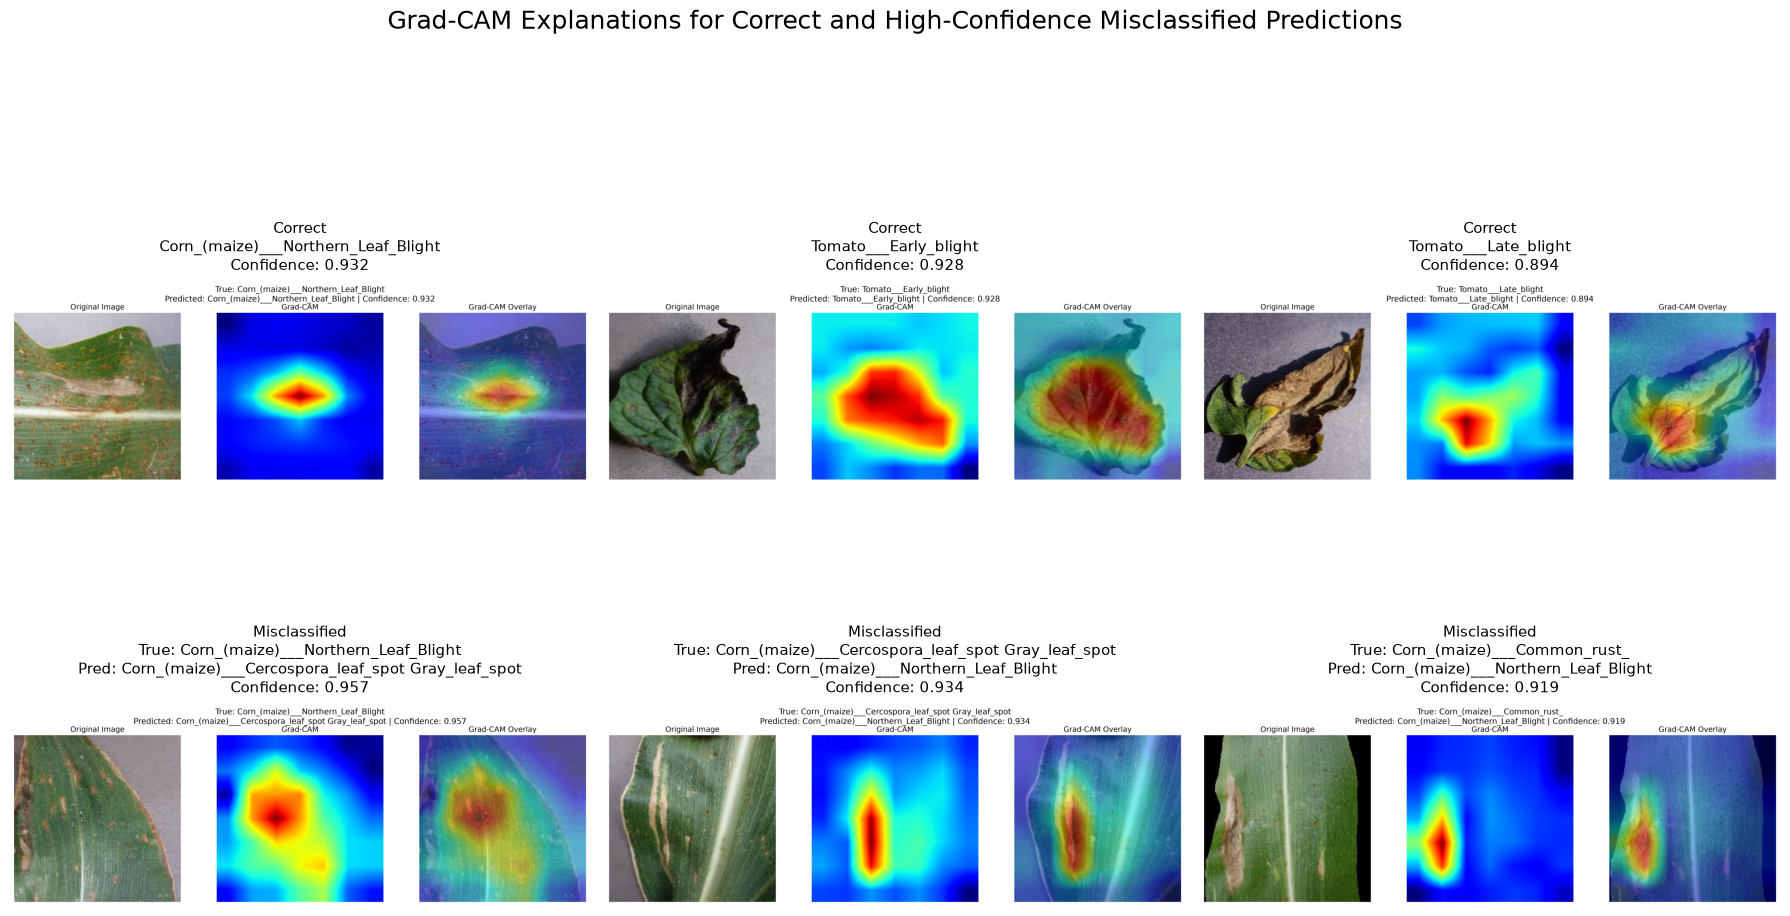


PUBLICATION XAI FIGURE COMPLETE

Figure:
c:\Users\cscpr\Downloads\random 1\XAI_Results\Publication_Figures\Figure_XAI_GradCAM_Comparison.png

Metadata:
c:\Users\cscpr\Downloads\random 1\XAI_Results\Publication_Figures\Figure_XAI_GradCAM_Comparison_metadata.csv

Number of panels: 6
Correct examples : 3
Error examples   : 3

✓ Correct predictions included
✓ High-confidence errors included
✓ Grad-CAM explanations included
✓ 300 DPI publication figure saved
✓ Figure metadata saved

CELL 31 COMPLETE


In [42]:
# ============================================================
# CELL 31 — PUBLICATION-QUALITY XAI COMPARISON FIGURE
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

print("=" * 70)
print("CREATING PUBLICATION-QUALITY XAI COMPARISON FIGURE")
print("=" * 70)

# ------------------------------------------------------------
# OUTPUT DIRECTORY
# ------------------------------------------------------------

PUBLICATION_XAI_DIR = os.path.join(
    XAI_DIR,
    "Publication_Figures"
)

os.makedirs(
    PUBLICATION_XAI_DIR,
    exist_ok=True
)

# ------------------------------------------------------------
# VERIFY MISCLASSIFICATION TABLE
# ------------------------------------------------------------

if "MIS_XAI_DF" not in globals():

    mis_summary_path = os.path.join(
        MIS_XAI_DIR,
        "misclassified_gradcam_summary.csv"
    )

    MIS_XAI_DF = pd.read_csv(
        mis_summary_path
    )

# ------------------------------------------------------------
# SELECT THREE HIGH-CONFIDENCE ERRORS
# ------------------------------------------------------------

selected_errors = (
    MIS_XAI_DF
    .sort_values(
        "confidence",
        ascending=False
    )
    .head(3)
    .copy()
)

print()
print("SELECTED HIGH-CONFIDENCE ERRORS:")
print("-" * 70)

for _, row in selected_errors.iterrows():

    print(
        f"Sample {int(row['test_index'])}: "
        f"{row['true_class']} -> "
        f"{row['predicted_class']} "
        f"(confidence={row['confidence']:.4f})"
    )

# ------------------------------------------------------------
# FIND CORRECT REPRESENTATIVE SAMPLES
# ------------------------------------------------------------

y_true = np.asarray(
    TEST_RESULTS["y_true"]
)

y_pred = np.asarray(
    TEST_RESULTS["y_pred"]
)

correct_indices = np.where(
    y_true == y_pred
)[0]

# Prefer biologically related classes represented in errors.
preferred_correct_classes = [
    9,   # Corn Northern Leaf Blight
    29,  # Tomato Early Blight
    30   # Tomato Late Blight
]

selected_correct_indices = []

for class_idx in preferred_correct_classes:

    matches = correct_indices[
        y_true[correct_indices] == class_idx
    ]

    if len(matches) > 0:
        selected_correct_indices.append(
            int(matches[0])
        )

# Fallback if any class was unavailable
if len(selected_correct_indices) < 3:

    for idx in correct_indices:

        idx = int(idx)

        if idx not in selected_correct_indices:
            selected_correct_indices.append(idx)

        if len(selected_correct_indices) == 3:
            break

selected_correct_indices = (
    selected_correct_indices[:3]
)

print()
print("SELECTED CORRECT EXAMPLES:")
print("-" * 70)

for idx in selected_correct_indices:

    print(
        f"Sample {idx}: "
        f"{CLASS_NAMES[int(y_true[idx])]}"
    )

# ------------------------------------------------------------
# GENERATE GRAD-CAM FOR CORRECT EXAMPLES
# ------------------------------------------------------------

correct_records = []

for idx in selected_correct_indices:

    print()
    print(
        f"Generating Grad-CAM for correct sample {idx}..."
    )

    result = generate_gradcam_visualization(
        sample_index=idx,
        show_plot=False
    )

    correct_records.append(result)

# ------------------------------------------------------------
# COMBINE ALL SELECTED FIGURES
# ------------------------------------------------------------

figure_records = []

# Correct examples first
for result in correct_records:

    figure_records.append({
        "type": "Correct",
        "sample_index": result["sample_index"],
        "true_class": result["true_class"],
        "predicted_class": result["predicted_class"],
        "confidence": result["confidence"],
        "path": result["save_path"]
    })

# Then high-confidence errors
for _, row in selected_errors.iterrows():

    figure_records.append({
        "type": "Misclassified",
        "sample_index": int(row["test_index"]),
        "true_class": row["true_class"],
        "predicted_class": row["predicted_class"],
        "confidence": float(row["confidence"]),
        "path": row["gradcam_path"]
    })

# ------------------------------------------------------------
# CREATE 2 × 3 FIGURE
# ------------------------------------------------------------

fig, axes = plt.subplots(
    2,
    3,
    figsize=(18, 11)
)

axes = axes.flatten()

for ax, record in zip(
    axes,
    figure_records
):

    # --------------------------------------------------------
    # LOAD EXISTING GRAD-CAM FIGURE
    # --------------------------------------------------------

    image = Image.open(
        record["path"]
    ).convert("RGB")

    image_array = np.asarray(
        image
    )

    ax.imshow(
        image_array
    )

    ax.axis("off")

    # --------------------------------------------------------
    # TITLE
    # --------------------------------------------------------

    if record["type"] == "Correct":

        title = (
            f"Correct\n"
            f"{record['true_class']}\n"
            f"Confidence: {record['confidence']:.3f}"
        )

    else:

        title = (
            f"Misclassified\n"
            f"True: {record['true_class']}\n"
            f"Pred: {record['predicted_class']}\n"
            f"Confidence: {record['confidence']:.3f}"
        )

    ax.set_title(
        title,
        fontsize=11,
        pad=8
    )

# ------------------------------------------------------------
# OVERALL TITLE
# ------------------------------------------------------------

fig.suptitle(
    "Grad-CAM Explanations for Correct and "
    "High-Confidence Misclassified Predictions",
    fontsize=18,
    y=0.995
)

plt.tight_layout(
    rect=[0, 0, 1, 0.965]
)

# ------------------------------------------------------------
# SAVE HIGH-RESOLUTION FIGURE
# ------------------------------------------------------------

publication_path = os.path.join(
    PUBLICATION_XAI_DIR,
    "Figure_XAI_GradCAM_Comparison.png"
)

fig.savefig(
    publication_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

# ------------------------------------------------------------
# SAVE RECORD TABLE
# ------------------------------------------------------------

publication_table = pd.DataFrame(
    figure_records
)

publication_table_path = os.path.join(
    PUBLICATION_XAI_DIR,
    "Figure_XAI_GradCAM_Comparison_metadata.csv"
)

publication_table.to_csv(
    publication_table_path,
    index=False
)

# ------------------------------------------------------------
# FINAL REPORT
# ------------------------------------------------------------

print()
print("=" * 70)
print("PUBLICATION XAI FIGURE COMPLETE")
print("=" * 70)

print()
print("Figure:")
print(publication_path)

print()
print("Metadata:")
print(publication_table_path)

print()
print("Number of panels:", len(figure_records))
print("Correct examples :", len(correct_records))
print("Error examples   :", len(selected_errors))

print()
print("✓ Correct predictions included")
print("✓ High-confidence errors included")
print("✓ Grad-CAM explanations included")
print("✓ 300 DPI publication figure saved")
print("✓ Figure metadata saved")

print()
print("=" * 70)
print("CELL 31 COMPLETE")
print("=" * 70)